## T5 ##

In [ ]:
from difflib import SequenceMatcher
import re
import matplotlib.pyplot as plt
import sacrebleu
import numpy as np

In [ ]:
!pip install sacrebleu



### CÁLCULO DE BLEU SCORE PARA NLLB-200 (ITALIANO -> PORTUGUÊS) ###
**Parágrafos: n. 1 ao n. 16**
--------------------------------------------------------------------
**Proémio, n. 1**
  BLEU Score: 8.70
--------------------------------------------------
**Capítulo I, n. 2**
  BLEU Score: 19.88
--------------------------------------------------
**Capítulo I, n. 3**
  BLEU Score: 20.48
--------------------------------------------------
**Capítulo I, n. 4**
  BLEU Score: 17.02
--------------------------------------------------
**Capítulo I, n. 5**
  BLEU Score: 16.77
--------------------------------------------------
**Capítulo I, n. 6**
  BLEU Score: 6.63
--------------------------------------------------
**Capítulo II, n. 7**
  BLEU Score: 4.31
--------------------------------------------------
**Capítulo II, n. 8**
  BLEU Score: 9.97
--------------------------------------------------
**Capítulo II, n. 9**
  BLEU Score: 1.16
--------------------------------------------------
**Capítu

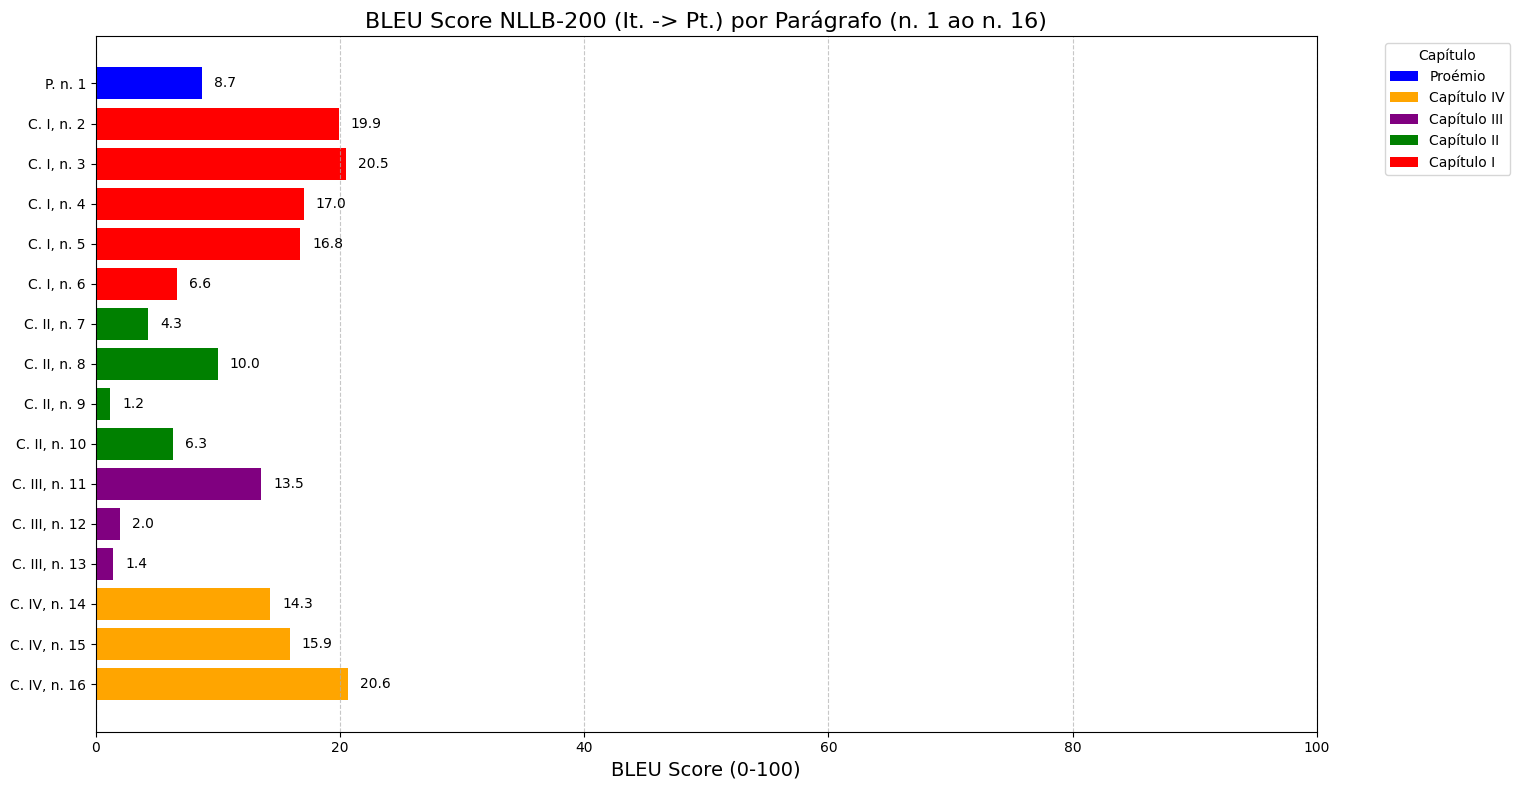



### CÁLCULO DE BLEU SCORE PARA NLLB-200 (ITALIANO -> PORTUGUÊS) ###
**Parágrafos: n. 17 ao n. 26**
--------------------------------------------------------------------
**Capítulo V, n. 17**
  BLEU Score: 18.65
--------------------------------------------------
**Capítulo V, n. 18**
  BLEU Score: 1.60
--------------------------------------------------
**Capítulo V, n. 19**
  BLEU Score: 8.68
--------------------------------------------------
**Capítulo V, n. 20**
  BLEU Score: 11.82
--------------------------------------------------
**Capítulo VI, n. 21**
  BLEU Score: 7.62
--------------------------------------------------
**Capítulo VI, n. 22**
  BLEU Score: 2.19
--------------------------------------------------
**Capítulo VI, n. 23**
  BLEU Score: 1.99
--------------------------------------------------
**Capítulo VI, n. 24**
  BLEU Score: 12.63
--------------------------------------------------
**Capítulo VI, n. 25**
  BLEU Score: 1.68
---------------------------------------------

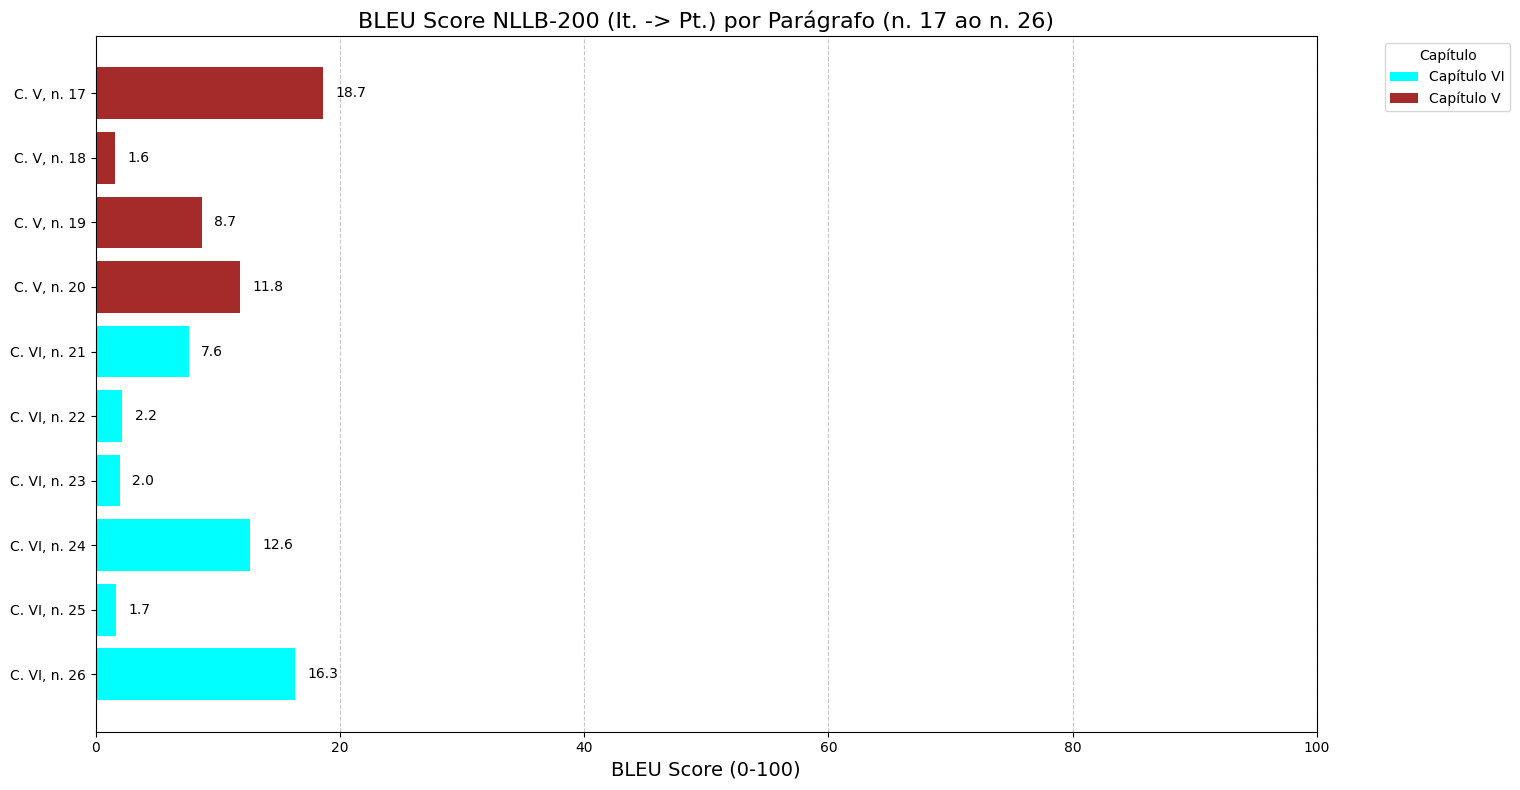

In [ ]:
# Proémio, n. 1
REF_1 = [
    "Il sacro Concilio, udendo con religiosa attenzione la parola di Dio e proclamandola con ferma fiducia, fa sue queste parole di san Giovanni: «Vi annunziamo la vita eterna, che era presso il Padre e si manifestò a noi: vi annunziamo ciò che abbiamo veduto e udito, affinché anche voi siate in comunione con noi, e la nostra comunione sia col Padre e col Figlio suo Gesù Cristo» (1 Gv 1,2-3).",
    "Perciò, seguindo i Concili Tridentino e Vaticano I, esso intende proporre l'autentica dottrina sulla divina Rivelazione e sulla sua trasmissione, affinché, per l'annunzio della salvezza, il mondo intero ascoltando creda, credendo speri, sperando ami.",
]
AUTO_1 = [
    "O sacro Concílio, ouvindo religiosamente a Palavra de Deus e proclamando-a com firme confiança, faz suas estas palavras de São João: «Anunciamos-vos a vida eterna, que estava junto do Pai e se manifestou a nós: anunciamos-vos o que vimos e ouvimos, a fim de que também vós sejais em comunhão conosco, e a nossa comunhão seja com o Pai e com o seu Filho Jesus Cristo» (1 Jo 1,2-3).",
    "Por isso, seguindo os Concílios Tridentino e Vaticano I, tenciona propor a genuína doutrina sobre a Revelação divina e a sua transmissão, para que, o mundo inteiro, ouvindo, acredite na mensagem da salvação, acreditando espere e esperando ame.",
]

# Capítulo I, n. 2
REF_2 = [
    "Piacque a Dio nella sua bontà e sapienza rivelare se stesso e far conoscere il mistero della sua volontà (cfr. Ef 1,9), mediante il quale gli uomini per mezzo di Cristo, Verbo fatto carne, nello Spirito Santo hanno accesso al Padre e sono resi partecipi della divina natura (cfr. Ef 2,18; 2 Pt 1,4).",
    "Con questa rivelazione infatti, Dio invisibile (cfr. Col 1,15; 1 Tm 1,17) nel suo immenso amore parla agli uomini come ad amici (cfr. Es 33,11; Gv 15,14-15) e si intrattiene con essi (cfr. Bar 3,38), per invitarli e ammetterli alla comunione con sé.",
    "Questa «economia» della Rivelazione avviene con eventi e parole intimamente connessi tra loro, in modo che le opere, compiute da Dio nella storia della salvezza, manifestano e rafforzano la dottrina e le realtà significate dalle parole, e le parole a loro volta proclamano le opere e chiariscono il mistero in esse contenuto.",
    "Però la profonda verità, sia riguardo a Dio, sia riguardo alla salvezza degli uomini, per mezzo di questa Rivelazione, risplende a noi in Cristo, che è insieme il mediatore e la pienezza di tutta intera la Rivelazione (2).",
]
AUTO_2 = [
    "Aprouve a Deus na sua bondade e sabedoria revelar-se a si e dar a conhecer o mistério da sua vontade (cfr. Ef 1,9), mediante o qual os homens por meio de Cristo, Verbo feito carne, no Espírito Santo têm acesso ao Pai e são tornados participantes da natureza divina (cfr. Ef 2,18; 2 Pt 1,4).",
    "Com esta revelação, Deus invisível (cfr. Col 1,15; 1 Tm 1,17) no seu imenso amor fala aos homens como amigos (cfr. Ex 33,11; Jo 15,14-15) e se entretém com eles (cfr. Bar 3,38), para os convidar e admitir à comunhão consigo.",
    "Esta economia da revelação ocorre com eventos e palavras intimamente conectados entre si, de modo que as obras, realizadas por Deus na história da salvação, manifestam e reforçam a doutrina e as realidades significadas pelas palavras, e as palavras, por sua vez, proclamam as obras e esclarecem o mistério nelas contido.",
    "Porém, a verdade profunda, seja sobre Deus seja sobre a salvação dos homens, por meio desta Revelação, resplandece-us em Cristo, que é, juntamente, o mediador e a plenitude de toda a Revelação (2).",
]

# Capítulo I, n. 3
REF_3 = [
    "Dio, il quale crea e conserva tutte le cose per il Verbo (cfr. Gv 1,3), offre agli uomini nelle cose create una perenne testimonianza di sé (cfr. Rm 1,19-20). Inoltre, volendo aprire la via della salvezza soprannaturale, fin dal principio manifestò se stesso ai Progenitori.",
    "Dopo la loro caduta, con la promessa della redenzione, li sollevò alla speranza della salvezza (cfr. Gn 3,15), e senza interruzione ebbe cura del genere umano, per dare la vita eterna a tutti coloro que cercano la salvezza con la perseveranza nelle buone opere (cfr. Rm 2,6-7).",
    "A suo tempo chiamò Abramo, per fare di lui un popolo grande (cfr. Gn 12,2), popolo che dopo i Patriarchi istruì per mezzo di Mosè e dei profeti, affinché lo riconoscesse come l'unico Dio vivo e vero, padre provvido e giusto giudice, e attendesse il Salvatore promesso; e così preparò attraverso i secoli la via al Vangelo.",
]
AUTO_3 = [
    "Deus, o qual cria e conserva tudo pelo Verbo (cfr. Jo 1,3), oferece aos homens em todas as coisas criadas um testemunho perene de si (cfr. Rm 1,19-20). Além disso, querendo abrir a via da salvação sobrenatural, desde o princípio manifestou-se a si aos Progenitores.",
    "Após sua caída, com a promessa de redenção, os elevou à esperança da salvação (cfr. Gn 3,15), e jamais parou de cuidar do gênero humano, para dar a vida eterna a todos os que procuram a salvação com perseverança nas boas obras (cfr. Rm 2,6-7).",
    "A seu tempo chamou Abraão, para fazer dele um povo grande (cfr. Gn 12,2), povo que após os Patriarcas instruiu por Moisés e os profetas, para que o reconhecessem como o único Deus vivo e verdadeiro, pai providente e justo juiz, e em espera do Salvador prometido; e deste modo preparou através dos séculos o caminho ao Evangelho.",
]

# Capítulo I, n. 4
REF_4 = [
    "Dopo aver a più riprese e in più modi parlato per mezzo dei profeti, « Dio ultimamente, in questi giorni, ha parlato a noi per mezzo del Figlio » (Eb 1,1-2).",
    "Ha mandato infatti il Figlio suo, cioè il Verbo eterno, che illumina tutti gli uomini, affinché dimorasse tra gli uomini e ad essi spiegasse l'intimo di Dio (cfr. Gv 1,1-18).",
    "Gesù Cristo, Verbo fatto carne, mandato come «uomo agli uomini» (3), «parla le parole di Dio» (Gv 3,34) e porta a compimento l'opera di salvezza que il Padre gli aveva affidato (cfr. Gv 5,36; 17,4).",
    "Perciò chi vede lui, vede anche il Padre (cfr. Gv 14,9). Egli, con tutta la sua presenza e manifestazione, con le parole e con le opere, con i segni e con i miracoli, e specialmente con la sua morte e gloriosa risurrezione, e infine con l'invio dello Spirito di verità, compie e completa la Rivelazione e la conferma con la testimonianza divina, ossia che Dio è con noi per liberarci dalle tenebre del peccato e della morte e per risuscitarci a vita eterna.",
    "Per questo l'Economia cristiana, in quanto Alleanza nuova e definitiva, non passerà mai, e non si dovrà attendere nessun'altra rivelazione pubblica prima della manifestazione gloriosa del Signore nostro Gesù Cristo (cfr. 1 Tm 6,14; Tt 2,13).",
]
AUTO_4 = [
    "Depois de ter falado por meio dos profetas, muitas vezes e em diversos modos, Deus «ultimamente, nestes dias, falou a nós por meio do Filho» (Eb 1,1-2).",
    "Mandou de facto o seu Filho, isto é, o Verbo eterno, que ilumina todos os homens, para que morasse entre os homens e a eles explicasse o íntimo de Deus (cfr. Jo 1,1-18).",
    "Jesus Cristo, Verbo feito carne, enviado como «homem aos homens» (3), «fala as palavras de Deus» (Jo 3,34) e leva a cumprimento a obra de salvação que o Pai lhe tinha confiado (cfr. Jo 5,36; 17,4).",
    "Portanto, quem vê ele, vê também o Pai (cfr. Gv 14,9). Por isso Ele, com toda a sua presença e manifestação, com as palavras e com as obras, com os sinais e com os milagres, e especialmente com a sua morte e gloriosa ressurreição, enfim com o envio do Espírito de verdade, cumpre e completa a Revelação e a confirma com o testemunho divino, ou seja, que Deus está connosco para nos livrar das trevas do pecado e da morte e para nos ressuscitar à vida eterna.",
    "Por isso a Economia cristã, enquanto Aliança nova e definitiva, não passará jamais e não se deverá esperar nenhuma nova revelação pública antes da manifestação gloriosa do Senhor nosso Jesus Cristo (cfr. 1 Tm 6,14; Tt 2,13).",
]

# Capítulo I, n. 5
REF_5 = [
    "A Dio che rivela è dovuta «l'obbedienza della fede» (Rm 16,26; cfr. Rm 1,5; 2 Cor 10,5-6).",
    "Con la fede infatti l'uomo si abbandona interamente a Dio liberamente, prestando «con l'intelletto e con la volontà l'ossequio pieno a Dio che rivela» (4) e dando il suo assenso volontario alla rivelazione fatta da lui.",
    "Per prestare questa fede, é necessária la grazia di Dio che previene e soccorre, e gli aiuti interiori dello Spirito Santo, il quale muova il cuore e lo rivolga a Dio, apra gli occhi della mente e dia «a tutti soavità nel consentire e nel credere alla verità» (5).",
    "Affinché l'intelligenza della Rivelazione diventi sempre più profonda, lo stesso Spirito Santo perfeziona continuamente la fede per mezzo dei suoi doni.",
]
AUTO_5 = [
    "À «obediência da fé» (Rm 16,26; cfr. Rm 1,5; 2 Cor 10,5-6) o homem deve-se a Deus que revela.",
    "Com a fé, de facto, o homem se abandona todo a Deus livremente, prestando «o obséquio pleno do intelecto e da vontade a Deus que revela» (4) e dando o seu assenso volontário à Revelação feita por ele.",
    "Para prestar esta fé, é necessária a graça de Deus, preveniente e auxiliadora, e os auxílios interiores do Espírito Santo, o qual mova o coração e o dirija a Deus, abra os olhos da mente e dê «a todos soavidade no consentir e nel crer à verdade» (5).",
    "A fim de que a inteligência da Revelação se torne sempre mais profunda, o mesmo Espírito Santo aperfeiçoa continuamente a fé por meio dos seus donos.",
]

# Capítulo I, n. 6
REF_6 = [
    "Con la divina Rivelazione Iddio volle manifestare e comunicare se stesso e i decreti della sua volontà per la salvezza degli uomini, «per renderli cioè partecipi dei beni divini, che trascendono assolutamente l'intelligenza della mente umana» (6).",
    "Il santo Concilio professa que «Dio, principio e fine di tutte le cose, può essere conosciuto con certezza con la luce naturale della ragione umana a partire dalle cose create» (cfr. Rm 1,20);",
    "ma insegna pure che è merito della Rivelazione divina se «tutto ciò que nelle cose divine non è per sé inaccessibile alla ragione umana, può, anche nell'attuale condizione del genere umano, essere conosciuto da tutti facilmente, con ferma certezza e senza mescolanza di errore» (7).",
]
AUTO_6 = [
    "Com a divina Revelação Deus quis manifestar e comunicar-se a si e os decretos eternos da sua vontade a respeito da salvação dos homens, «para os tornar participantes daqueles bens divinos, que transcendem absolutamente a capacidade da inteligência humana».",
    "O santo Concílio professa que «Deus, princípio e fim de todas as coisas, pode ser conhecido com certeza com a luz natural da razão a partir das coisas criadas» (cfr. Rm 1,20);",
    "mas ensina também que é mérito da Revelação divina se «tudo aquilo que nas coisas divinas não é por si inacessível à razão humana, pode, mesmo no presente estado do gênero humano, ser conhecido por todos facilmente, com firme certeza e sem mistura de erro».",
]

# Capítulo II, n. 7
REF_7 = [
    "Dio con somma benignità dispose che quanto Egli aveva rivelato per la salvezza di tutte le genti, rimanesse per sempre integro e venisse trasmesso a tutte le generazioni.",
    "Perciò Cristo Signore, nel quale si compie tutta intera la Rivelazione del sommo Dio (cfr. 2 Cor 1,20; 3,16-4,6), dopo aver portato a compimento in sé tutta la verità de Dio predicò di persona (1), comandò agli apostoli che predicassero a tutti, come la fonte di ogni verità salutare e di ogni regola morale, quel Vangelo che egli prima aveva promesso per mezzo dei profeti e che poi aveva adempiuto e promulgato di persona, comunicando così ad essi i doni divini.",
    "Questo venne fedelmente eseguito, sia dagli apostoli, i quali nella predicazione orale, con gli esempi e le istituzioni trasmisero sia ciò che avevano ricevuto dalla bocca del Cristo vivendo con lui e osservandolo agire, sia ciò che avevano imparato dai suggerimenti dello Spirito Santo, sia da quegli apostoli o da uomini della loro cerchia, i quali, per ispirazione dello stesso Spirito Santo, misero per iscritto il messaggio della salvezza (2).",
    "Gli apostoli poi, affinché il Vangelo si conservasse sempre integro e vivo nella Chiesa, lasciarono come loro successori i vescovi, ad essi «affidando il loro proprio posto di maestri» (3).",
    "Questa sacra Tradizione e la sacra Scrittura di entrambi i Testamenti sono dunque come uno specchio nel quale la Chiesa pellegrina in terra contempla Dio, dal quale tutto riceve, finché giunga a vederlo faccia a faccia, com'egli è (cfr. 1 Gv 3,2).",
]
AUTO_7 = [
    "Deus, com suma benignidade, dispôs que o quanto ele tinha revelado para a salvação de todos os povos, permanecesse para sempre íntegro e fosse transmitido a todas as gerações.",
    "Por isso Cristo Senhor, no qual se cumpre toda a Revelação do Deus altíssimo, ordenou aos apóstolos que o Evangelho, antes prometido por meio dos profetas e por ele cumprido e promulgado em pessoa fosse por eles pregado a todos como a fonte de toda verdade salutar e de toda regra moral [8], comunicando assim a eles os dons divinos.",
    "Isto veio fielmente executado, tanto pelos apóstolos, os quais na pregação oral, com os exemplos e as instituições transmitiram tanto o que tinham recebido da boca do Cristo vivendo com ele e o observando agir, quanto daqueles apóstolos e de homens de seu círculo, os quais, por inspiração do Espírito Santo, puseram por escrito a mensagem da salvação [9].",
    "Os apóstolos depois, para que o Evangelho se conservasse sempre íntegro e vivo na Igreja, deixaram como seus sucessores os bispos, a eles «confiando o seu próprio posto de mestres» [10].",
    "Esta sacra Tradição e a Escritura sacra de um e outro Testamento são então como um espelho no qual a Igreja peregrina em terra contempla Deus, do qual tudo recebe, até que chegue a vê-lo face a face, como ele é (cfr. 1 Gv 3,2).",
]

# Capítulo II, n. 8
REF_8 = [
    "Così la predicazione apostolica, che è espressa in modo speciale nei libri ispirati, doveva con una successione ininterrotta conservarsi sino alla fine dei tempi.",
    "Perciò gli apostoli, trasmettendo ciò che essi stessi avevano ricevuto, ammoniscono i fedeli ad attenersi alle tradizioni che avevano appreso o con la parola, o per scritto (cfr. 2 Ts 2,15), e a combattere per la fede che ad essi era stata trasmessa una volta per tutte (cfr. Gd 3)(4).",
    "Ora, ciò que fu trasmesso dagli apostoli, comprende tutto quanto contribuisce alla santità di vita e al incremento della fede nel popolo di Dio; e così la Chiesa, nella sua dottrina, nella sua vita e nel suo culto, perpetua e trasmette a tutte le generazioni tutto ciò che essa è, tutto ciò che essa crede.",
    "Questa Tradizione, che trae origine dagli apostoli, progredisce nella Chiesa con l'assistenza dello Spirito Santo (5).",
    "Cresce infatti la comprensione, tanto delle cose quanto delle parole trasmesse, sia con la contemplazione e lo studio dei credenti, che le meditano in cuor loro (cfr. Lc 2,19 e 51), sia con l'intelligenza interiore, che essi provano delle cose spirituali, sia per la predicazione di coloro i quali con la successione episcopale hanno ricevuto un carisma sicuro di verità.",
    "La Chiesa cioè, nel corso dei secoli, tende incessantemente alla pienezza della verità divina, finché in essa giungano a compimento le parole di Dio.",
    "Le asserzioni dei santi Padri attestano la presenza vivificatrice di questa Tradizione, i cui tesori si riversano nella pratica e nella vita della Chiesa credente e orante.",
    "Per mezzo di questa medesima Tradizione la Chiesa conosce il canone completo dei libri sacri, e le stesse sacre Scritture in essa vengono comprese più profondamente e rese incessantemente operanti;",
    "e così Dio, il quale parlò nel passato, non cessa di conversare con la Sposa del suo Figlio diletto;",
    "e lo Spirito Santo, per mezzo del quale la voce viva del Vangelo risuona nella Chiesa, e per mezzo di questa nel mondo, introduce i credenti in tutta intera la verità e fa sì che in essi risieda abbondantemente la parola di Cristo (cfr. Col 3,16).",
]
AUTO_8 = [
    "Assim a pregação apostólica, que é expressa de modo especial nos livros inspirados, devia com uma sucessão ininterrupta ser conservada até ao fim dos tempos.",
    "Por isso os Apóstolos, transmitindo o que eles próprios tinham recebido, advertem os fiéis a se aterem às tradições que tinham aprendido quer com a palavra quer por escrito (cfr. 2 Ts 2,15), e a combater pela fé que lhes tinha sido uma vez por todas transmitida (cfr. Jd 3).",
    "Ora, aquilo que foi transmitido pelos Apóstolos compreende tudo quanto contribui para a santidade de vida do povo de Deus e para o incremento da fé;",
    "e assim a Igreja, na sua doutrina, na sua vida e no seu culto, perpetua e transmite a todas as gerações tudo aquilo que ela é e tudo aquilo em que acredita.",
    "Esta Tradição, que tem origem nos Apóstolos, progride na Igreja com a assistência do Espírito Santo.",
    "Cresce de facto a compreensão, tanto das coisas como das palavras transmitidas, quer com a contemplação e o estudo dos crentes, os quais as meditam em seu coração (cfr. Lc 2,19 e 51), quer com a inteligência interior, que eles experimentam das coisas espirituais, quer pela pregação daqueles que com a sucessão episcopal receberam um carisma seguro de verdade.",
    "A Igreja isto é, no decurso dos séculos, tende incessantemente à plenitude da verdade divina, até que nela cheguem a cumprimento as palavras de Deus.",
    "As afirmações dos santos Padres atestam a presença vivificadora desta Tradição, cujas riquezas se derramam na prática e na vida da Igreja crente e orante.",
    "Por meio da mesma Tradição a Igreja conhece o inteiro cânon dos livros sagrados, e as mesmas Sagradas Escrituras nela se compreendem mais profundamente e se tornam incessantemente operantes;",
    "e assim Deus, o qual falou no passado, não cessa de conversar com a Esposa do seu Filho dileto;",
    "e o Espírito Santo, por meio do qual a voz viva do Evangelho ressoa na Igreja e, pela Igreja, no mundo, introduz os crentes em toda a verdade e faz com que neles resida abundantemente a palavra de Cristo (cfr. Col 3,16).",
]

# Capítulo II, n. 9
REF_9 = [
    "La sacra Tradizione e la sacra Scrittura sono dunque strettamente connesse e comunicanti tra loro.",
    "Infatti, ambedue scaturiscono dalla medesima sorgente divina, formano in certo qual modo una cosa sola e tendono allo stesso fine.",
    "La sacra Scrittura infatti è la parola di Dio in quanto è messa per iscritto sotto l'ispirazione dello Spirito divino.",
    "Quanto alla sacra Tradizione, essa trasmette integralmente la parola di Dio, affidata da Cristo Signore e dallo Spirito Santo agli Apostoli, ai loro successori, affinché questi, illuminati dallo Spirito di verità, nella loro predicazione la conservino fedelmente, la espongano e la diffondano.",
    "Ne consegue che la Chiesa non attinge la certezza su tutte le cose rivelate dalla sola sacra Scrittura.",
    "Perciò l'una e l'altra devono essere accettate e venerate con pari sentimento di pietà e di riverenza (6).",
]
AUTO_9 = [
    "A sacra Tradição e a sacra Escritura estão então estritamente conectadas e comunicantes entre elas.",
    "De facto, ambas brotam da mesma fonte divina, formam de certo modo uma coisa só e tendem ao mesmo fim.",
    "Visto que a sacra Escritura é a Palavra de Deus enquanto é posta por escrito sob a inspiração do Espírito divino.",
    "A sacra Tradição, por outro lado, transmite integralmente a Palavra de Deus, confiada por Cristo Senhor e pelo Espírito Santo aos Apóstolos, aos seus sucessores, para que estes, iluminados pelo Espírito de verdade, na sua pregação a conservem, a exponham e a difundam fielmente.",
    "Consegue-se que a Igreja atinja a certeza sobre todas as coisas reveladas não só da sacra Escritura.",
    "Por isso, uma e outra devem ser aceitas e veneradas com igual sentimento de piedade e de reverência.",
]

# Capítulo II, n. 10
REF_10 = [
    "La sacra Tradizione e la sacra Scrittura costituiscono un solo sacro deposito della parola di Dio affidato alla Chiesa;",
    "nell'aderire ad esso, tutto il popolo santo, unito ai suoi Pastori, persevera costante nell'insegnamento degli Apostoli e nella comunione, nella frazione del pane e nella preghiera (cfr. At 2,42 gr.), in modo che nel ritenere, praticare e professare la fede trasmessa, si crei una singolare concordia di vescovi e di fedeli (7).",
    "L'ufficio poi d'interpretare autenticamente la parola di Dio scritta o trasmessa, è affidato al solo Magistero vivo della Chiesa (8), la cui autorità è esercitata nel nome di Gesù Cristo (9).",
    "Il Magistero, tuttavia, non è superior alla parola di Dio, ma la serve, insegnando soltanto ciò que é stato trasmesso, in quanto, per divino mandato e con l'assistenza dello Spirito Santo, piamente la ascolta, santamente la custodisce e fedelmente la espone, attingendo da questo unico deposito della fede tutto ciò che propone da credere come divinamente rivelato.",
    "È chiaro dunque che la sacra Tradizione, la sacra Scrittura e il Magistero della Chiesa, per sapientissima disposizione di Dio, sono tra loro così connessi e congiunti che nessuno d'essi sussiste senza gli altri, e tutti insieme, ciascuno a suo modo, sotto l'azione dello Spirito Santo, contribuiscono efficacemente alla salvezza delle anime.",
]
AUTO_10 = [
    "A sacra Tradição e a sacra Escritura constituem um só depósito sagrado da Palavra de Deus, confiado à Igreja;",
    "aderindo a este, todo o Povo santo, unido aos seus Pastores, persevera constante no ensinamento dos Apóstolos e na comunhão, na fração do pão e na oração (cfr. At 2,42 gr.), de modo que no reter, praticar e professar a fé transmitida, se crie uma singular concórdia de Bispos e de fiéis.",
    "O encargo, no entanto, de interpretar autenticamente a Palavra de Deus escrita ou transmitida é confiado ao só Magistério vivo da Igreja, o qual o exerce em nome de Jesus Cristo.",
    "O Magistério, todavia, não é superior à Palavra de Deus mas a ela serve, ensinando somente aquilo que foi transmitido, enquanto, por divino mandato e com a assistência do Espírito Santo, a escuta piamente, a custode santamente e a expõe fielmente, haurindo deste depósito único da fé tudo aquilo que propõe a crer como divinamente revelado.",
    "É claro, pois, que a sacra Tradição, a sacra Escritura e o Magistério da Igreja, por sapientíssima disposição de Deus, estão entre si tão conectados e unidos que nenhum deles subsiste sem os outros, e todos juntos, cada um a seu modo, sob a ação do mesmo Espírito Santo, contribuem eficazmente para a salvação das almas.",
]

# Capítulo III, n. 11
REF_11 = [
    "Le verità divinamente rivelate, che nei libri della sacra Scrittura sono contenute ed espresse, furono scritte per ispirazione dello Spirito Santo.",
    "La santa Madre Chiesa, secondo la fede degli Apostoli, ritiene sacri e canonici tutti i libri sia dell'Antico che del Nuovo Testamento con tutte le loro parti, perché scritti per ispirazione dello Spirito Santo (cfr. Gv 20,31; 2 Tm 3,16; 2 Pt 1,19-21; 3,15-16), hanno Dio per autore e como tali sono stati affidati alla Chiesa stessa (1).",
    "Per la composizione dei libri sacri, Dio scelse degli uomini di cui si servì nel possesso delle loro facoltà e capacità, affinché, agendo egli in essi e per essi (2), scrivessero come veri autori, tutte e soltanto quelle cose che Egli voleva (3).",
    "Poiché dunque tutto quello che gli autori ispirati o agiografi asseriscono è da ritenersi asserito dallo Spirito Santo, ne consegue que i libri della Scrittura insegnano con certezza, fedelmente e senza errore la verità que Dio per la nostra salvezza volle fosse consegnata nelle sacre Lettere (4).",
    "Perciò «tutta la Scrittura è ispirata da Dio e utile per insegnare, per convincere, per correggere, per educare alla giustizia, affinché l'uomo di Dio sia perfetto, pronto per ogni opera buona» (2 Tm 3,16-17 gr.).",
]
AUTO_11 = [
    "As verdades divinamente reveladas, que nos livros da sacra Escritura são contidas e expressas, foram escritas por inspiração do Espírito Santo.",
    "A santa Mãe Igreja, segundo a fé dos Apóstolos, retém sacros e canónicos todos os livros inteiros tanto do Velho como do Novo Testamento, com todas as suas partes, porque escritos sob inspiração do Espírito Santo (cfr. Jo 20,31; 2 Tm 3,16; 2 Pt 1,19-21; 3,15-16), têm Deus por autor e como tais foram confiados à Igreja.",
    "Para a composição dos livros sacros, Deus escolheu homens, dos quais se serviu no uso das suas faculdades e capacidades, para que, agindo Ele neles e por eles, escrevessem como verdadeiros autores, todas e só aquelas coisas que Ele queria.",
    "Visto que tudo aquilo que os autores inspirados ou hagiógrafos afirmam deve ser tido como afirmado pelo Espírito Santo, resulta que os livros da Escritura ensinam com fidelidade, firmemente e sem erro a verdade que Deus, para a nossa salvação, quis que fosse consignada nas sacras Letras.",
    "Por isso «toda a escritura é divinamente inspirada e útil para ensinar, para convencer, para corrigir, para educar à justiça, para que o homem de Deus seja perfeito, pronto para toda boa obra» (2 Tm 3,16-17 gr.).",
]

# Capítulo III, n. 12
REF_12 = [
    "Dio nella sacra Scrittura ha parlato per mezzo di uomini e alla maniera umana (5). Per l'interprete della sacra Scrittura, dunque, per conoscere ciò que Dio ha voluto comunicarci, bisogna ricercare con attenzione che cosa gli agiografi abbiano veramente voluto significare e a Dio sia piaciuto manifestare con le loro parole.",
    "Per scoprire l'intenzione degli agiografi, si deve tener conto tra l'altro anche dei «generi letterari».",
    "La verità infatti viene diversamente proposta ed espressa in testi in vario modo storici, o profetici, o poetici, o in altri modi di dire.",
    "È necessario che l'interprete ricerchi il senso che l'agiografo in determinate circostanze, secondo le condizioni del suo tempo e della sua cultura, e servendosi dei generi letterari allora in uso, intendeva esprimere e di fatto espresse (6).",
    "Per comprendere infatti esattamente ciò che l'autore sacro volle asserire, si deve tener conto convenientemente sia dei modi nativi di sentire, di esprimersi e di raccontare vigenti al tempo dell'agiografo, sia di quelli che in quel tempo erano abitualmente in uso nei rapporti umani (7).",
    "Ma poiché la sacra Scrittura deve essere letta e interpretata con lo stesso Spirito col quale fu scritta (8), per ricavarne con esattezza il senso dei testi sacri, si deve badare con non minore diligenza al contenuto e alla unità di tutta la Scrittura, tenuto debito conto della viva Tradizione di tutta la Chiesa e dell'analogia della fede.",
    "È compito degli esegeti lavorare secondo queste regole, per una più profonda intelligenza ed esposizione del senso della sacra Scrittura, affinché per mezzo di studi in qualche modo preparatori, maturi il giudizio della Chiesa.",
    "Tutto ciò infatti che concerne il modo di interpretare la Scrittura, è sottoposto in ultima istanza al giudizio della Chiesa, la quale adempie il divino mandato e ministero di custodire e interpretare la parola di Dio (9).",
]
AUTO_12 = [
    "Deus na sacra Escritura falou por intermédio de homens e à maneira humana. Portanto, o intérprete da sacra Escritura, para compreender o que Ele quis comunicar-nos, deve pesquisar com atenção o que os agiógrafos realmente quiseram significar e o que agradou a Deus manifestar com as suas palavras.",
    "Para descobrir a intenção dos agiógrafos, deve-se levar em consideração também os «géneros literários».",
    "Com efeito, a verdade é diversamente proposta e expressa em textos em vários modos históricos, ou proféticos, ou poéticos, ou em outros modos de dizer.",
    "É preciso que o intérprete pesquise o sentido que o agiógrafo em determinadas circunstâncias, segundo as condições do seu tempo e da sua cultura, e servindo-se dos géneros literários então em uso, intencionava expressar e de facto expressou.",
    "Para compreender de forma exata o que o autor sacro quis afirmar, deve-se prestar a devida atenção tanto aos modos nativos de sentir, de expressar e de narrar, vigentes ao tempo do agiógrafo, quanto àqueles que naquele tempo eram habitualmente em uso nas relações humanas.",
    "Mas, visto que a sacra Escritura deve ser lida e interpretada com o mesmo Espírito com o qual foi escrita, para extrair com exatidão o sentido dos textos sacros, deve-se atentar com não menor diligência ao conteúdo e à unidade de toda a Escritura, levado em conta a viva Tradição de toda a Igreja e a analogia da fé.",
    "É tarefa dos exegetas trabalhar segundo estas regras, para uma mais profunda inteligência e exposição do sentido da sacra Escritura, a fim de que por meio de estudos em algum modo preparatórios, amadureça o juízo da Igreja.",
    "De facto, tudo aquilo que concerne ao modo de interpretar a Escritura é submetido em última instância ao juízo da Igreja, que desempenha o divino mandato e o ministério de conservar e interpretar a Palavra de Deus.",
]

# Capítulo III, n. 13
REF_13 = [
    "Pertanto nella sacra Scrittura, ferma restando la verità e la santità di Dio, si manifesta la mirabile «condiscendenza» della Sapienza eterna, «perché impariamo quale ineffabile benignità di Dio e",
    "quanta sollecitudine Egli abbia avuto per la nostra natura» (10).",
    "Le parole di Dio infatti, espresse con lingue umane, si sono fatte simili al parlare umano, così come già il Verbo dell'eterno Padre, avendo assunto la carne dell'umana debolezza, divenne simile agli uomini.",
]
AUTO_13 = [
    "Portanto, na sacra Escritura, permanecendo firme a verdade e a santidade de Deus, manifesta-se a admirável «condescendência» da eterna sabedoria, «para que nós aprendamos qual inefável benignidade de Deus e",
    "quanta solicitude ele tenha tido pela nossa natureza» [11].",
    "As palavras de Deus de facto, expressas com línguas humanas, tornaram-se semelhantes ao falar humano, assim como um tempo o Verbo do eterno Pai, assumindo a carne da humana fraqueza, se fez semelhante aos homens.",
]

# Capítulo IV, n. 14
REF_14 = [
    "Dio con sommo amore, volendo e preparando la salvezza di tutto il genere umano, con singolare disegno si scelse un popolo, al quale affidare le sue promesse.",
    "Dopo aver stabilito un'alleanza con Abramo (cfr. Gn 15,18), e per mezzo di Mosè con il popolo d'Israele (cfr. Es 24,8), a questo popolo eletto si rivelò come l'unico Dio vivo e vero, in modo que Israele potesse conoscere per esperienza il piano di Dio nei riguardi degli uomini, e lo comprendesse con chiarezza e sempre più a fondo attraverso la parola dello stesso Dio che parlava per bocca dei profeti, e lo diffondesse in modo più ampio tra le genti (cfr. Sal 21,28-29; 95,1-3; Is 2,1-4; Ger 3,17).",
    "L'economia della salvezza, annunziata in precedenza, narrata e spiegata dagli autori sacri, si incontra nei libri dell'Antico Testamento come vera parola di Dio.",
    "Per questo tali libri divinamente ispirati conservano un valore perenne: «Tutto ciò infatti che fu scritto, fu scritto per nostra istruzione, affinché mediante la pazienza e la consolazione delle Scritture, avessimo la speranza» (Rm 15,4).",
]
AUTO_14 = [
    "Deus, com sumo amor, querendo e preparando a salvação de todo o género humano, com singular desígnio escolheu para si um povo, ao qual confiar as suas promessas.",
    "Depois de ter estabelecido uma aliança com Abraão (cfr. Gn 15,18), e, por meio de Moisés, com o povo de Israel (cfr. Ex 24,8), revelou-se a este povo eleito como o único Deus vivo e verdadeiro, de modo que Israel pudesse conhecer por experiência o plano de Deus no que diz respeito aos homens, e o compreendesse com clareza e sempre mais a fundo através da palavra do mesmo Deus que falava por boca dos profetas, e o difundisse de modo mais amplo entre as gentes (cfr. Sl 21,28-29; 95,1-3; Is 2,1-4; Jr 3,17).",
    "A economia da salvação, anunciada em precedência, narrada e explicada pelos autores sacros, encontra-se nos livros do Velho Testamento como verdadeira Palavra de Deus.",
    "Por isso, tais livros divinamente inspirados conservam um valor perene: «Tudo aquilo de facto que foi escrito, foi escrito para nossa instrução, a fim de que, mediante a paciência e a consolação das Escrituras, tivéssemos a esperança» (Rm 15,4).",
]

# Capítulo IV, n. 15
REF_15 = [
    "L'economia dell'Antico Testamento era soprattutto ordinata a preparare, ad annunziare profeticamente (cfr. Lc 24,44; Gv 5,39; 1 Pt 1,10) e a significare con varie figure (cfr. 1 Cor 10,11) l'avvento di Cristo, redentore universale, e del regno messianico.",
    "I libri dell'Antico Testamento, secondo la condizione del genere umano prima del tempo della salvezza attuata da Cristo, manifestano a tutti la conoscenza di Dio e dell'uomo e i modi con cui Dio giusto e misericordioso tratta gli uomini.",
    "Questi libri, sebbene contengano anche cose imperfette e caduche, dimostrano tuttavia una vera pedagogia divina (1).",
    "Perciò i fedeli devono accogliere con devozione questi libri, i quali esprimono il vivo senso di Dio, e nei quali si trovano sublimi dottrine su Dio, salutari insegnamenti sulla vita dell'uomo e mirabili tesori di orazioni, e finalmente nei quali è nascosto il mistero della nostra salvezza.",
]
AUTO_15 = [
    "A economia do Velho Testamento era sobretudo destinada a preparar, a anunciar com profecias (cfr. Lc 24,44; Gv 5,39; 1 Pt 1,10) e a significar com vários tipos (cfr. 1 Cor 10,11) a vinda de Cristo, redentor universal, e do reino messiânico.",
    "Os livros do Velho Testamento, segundo a condição do género humano antes do tempo da salvação efetuada por Cristo, manifestam a todos o conhecimento de Deus e do homem e os modos com que Deus justo e misericordioso trata os homens.",
    "Estes livros, embora contenham também coisas imperfeitas e caducas, demonstram todavia uma verdadeira pedagogia divina.",
    "Por isso, os fiéis devem acolher com devoção estes livros, os quais exprimem o vivo sentido de Deus, e nos quais se encontram sublimes doutrinas sobre Deus, salutares ensinamentos sobre a vida do homem e admiráveis tesouros de orações, e finalmente nos quais está escondido o mistério da nossa salvação.",
]

# Capítulo IV, n. 16
REF_16 = [
    "Perciò Dio, l'ispiratore e l'autore dei libri dell'uno e dell'altro Testamento, ha sapientemente disposto che il Nuovo fosse nascosto nell'Antico e l'Antico fosse svelato nel Nuovo (2).",
    "Quantunque infatti Cristo abbia fondato la Nuova Alleanza nel suo sangue (cfr. Lc 22,20; 1 Cor 11,25), tuttavia i libri dell'Antico Testamento, integralmente assunti nella predicazione evangelica (3), acquistano e manifestano il loro pieno significato nel Nuovo Testamento (cfr. Mt 5,17; Lc 24,27; Rm 16,25-26; 2 Cor 3,14-16), che essi a loro volta illuminano e spiegano.",
]
AUTO_16 = [
    "Deus portanto, o qual inspirou os livros de um e do outro Testamento e deles é o autor, dispôs sabiamente que o Novo fosse escondido no Velho e o Velho fosse revelado no Novo.",
    "Visto que, mesmo se Cristo fundou a Nova Aliança no seu sangue (cfr. Lc 22,20; 1 Cor 11,25), os livros do Velho Testamento, integralmente assumidos na pregação evangélica, adquirem e manifestam o seu pleno significado no Novo Testamento (cfr. Mt 5,17; Lc 24,27), que eles por sua vez iluminam e explicam.",
]

# Capítulo V, n. 17
REF_17 = [
    "La parola di Dio, che è potenza di Dio per la salvezza di chiunque crede (cfr. Rm 1,16), si presenta ed manifesta la sua forza in modo eminente negli scritti del Nuovo Testamento.",
    "Quando infatti venne la pienezza dei tempi (cfr. Gal 4,4), il Verbo si fece carne e abitò tra noi pieno di grazia e di verità (cfr. Gv 1,14).",
    "Cristo stabilì il regno di Dio sulla terra, manifestò con opere e parole il Padre suo e se stesso, e portò a compimento l'opera sua con la morte, la risurrezione e la gloriosa ascensione, e con l'invio dello Spirito Santo.",
    "Elevato da terra, egli attira tutti a sé (cfr. Gv 12,32 gr.), lui che solo ha parole di vita eterna (cfr. Gv 6,68).",
    "Questo mistero però non fu palesato alle altre generazioni, come ora è stato rivelato ai suoi santi apostoli e ai profeti nello Spirito Santo (cfr. Ef 3,4-6 gr.), affinché predicassero l'Evangelo, suscitassero la fede in Gesù Cristo Signore e raccogliessero la Chiesa.",
    "Di tutte queste cose gli scritti del Nuovo Testamento presentano una testimonianza perenne e divina.",
]
AUTO_17 = [
    "A palavra de Deus, que é potência divina para a salvação de quem crê (cfr. Rm 1,16), se apresenta e manifesta a sua força em modo eminente nos escritos do Novo Testamento.",
    "Quando de facto chegou a plenitude dos tempos (cfr. Gal 4,4), o Verbo se fez carne e habitou entre nós pleno de graça e de verdade (cfr. Jo 1,14).",
    "Cristo estabeleceu o reino de Deus sobre a terra, manifestou com obras e palavras o Pai seu e a si e levou a cumprimento a obra sua com a morte, a ressurreição e a gloriosa ascensão, assim como com o envio do Espírito Santo.",
    "Elevado da terra, atrai todos a si (cfr. Jo 12,32 gr.), ele que só tem palavras de vida eterna (cfr. Jo 6,68).",
    "Mas este mistério não foi palesado às outras gerações, como agora foi revelado aos seus santos apóstolos seus e aos profetas no Espírito Santo (cfr. Ef 3,4-6 gr.), para que pregassem o Evangelho, suscitasse a fé em Jesus Cristo Senhor e reunissem a Igreja.",
    "De tudo isto os escritos do Novo Testamento apresentam um testemunho perene e divino.",
]

# Capítulo V, n. 18
REF_18 = [
    "A nessuno sfugge che tra tutte le Scritture, anche del Nuovo Testamento, i Vangeli possiedono una meritata superiorità, in quanto costituiscono la principale testimonianza relativa alla vita e alla dottrina del Verbo incarnato, nostro Salvatore.",
    "La Chiesa ha ritenuto e ritiene sempre e in ogni luogo che i quattro Vangeli sono di origine apostolica.",
    "Infatti, ciò che gli apostoli per mandato di Cristo predicarono, in seguito, per ispirazione dello Spirito Santo, fu dagli stessi e da uomini della loro cerchia tramandato in scritti, che sono il fondamento della fede, cioè l'Evangelo quadriforme secondo Matteo, Marco, Luca e Giovanni (1).",
]
AUTO_18 = [
    "A ninguém escapa que entre todas as Escrituras, mesmo as do Novo Testamento, os Evangelhos possuem uma superioridade merecida, enquanto constituem o principal testemunho relativo à vida e à doutrina do Verbo encarnado, nosso Salvador.",
    "A Igreja sempre e em todo lugar reteve e retém que os quatro Evangelhos são de origem apostólica.",
    "De facto, aquilo que os apóstolos por mandato de Cristo pregaram, em seguida, por inspiração do Espírito Santo, foi pelos mesmos e por homens da sua cerchia transmitido em escritos que são o fundamento da fé, isto é, o Evangelho quadriforme segundo Mateus, Marcos, Lucas e João.",
]

# Capítulo V, n. 19
REF_19 = [
    "La santa Madre Chiesa ha ritenuto e ritiene con fermezza e con la massima costanza che i quattro Vangeli, di cui afferma senza esitazione la storicità, trasmettono fedelmente le cose che Gesù Figlio di Dio, durante la sua vita tra gli uomini, effettivamente operò e insegnò per la loro salvezza eterna, fino al giorno in cui fu assunto in cielo (cfr. At 1,1-2).",
    "Gli apostoli poi, dopo l'Ascensione del Signore, trasmisero ai loro uditori ciò che egli aveva detto e fatto, con quella più completa intelligenza delle cose, di cui essi, istruiti dagli eventi gloriosi di Cristo e illuminati dallo Spirito di verità (2), godevano (3).",
    "Gli autori sacri, poi, scrissero i quattro Vangeli, scegliendo alcune cose tra le molte tramandate a voce o già per iscritto, facendone una sintesi, o spiegandole avuto riguardo alla situazione delle Chiese, conservando infine il carattere di predicazione, sempre però in modo da riferire su Gesù cose vere e sincere (4).",
    "Essi infatti, attingendo sia dai propri ricordi sia dalla testimonianza di quelli «che fin dal principio furono testimoni oculari e ministri della parola», scrissero con l'intenzione di farci conoscere la «verità» (cfr. Lc 1,2-4) degli insegnamenti che abbiamo ricevuto.",
]
AUTO_19 = [
    "A santa mãe Igreja reteve e retém com firmeza e com a maior constância que os quatro Evangelhos supracitados, dos quais afirma sem hesitação a historicidade, transmitem fielmente aquilo que Jesus Filho de Deus, durante a sua vida entre os homens, efetivamente operou e ensinou para a sua salvação eterna, até ao dia em que foi assumido no céu (cfr. At 1,1-2).",
    "Os apóstolos depois, após a Ascensão do Senhor, transmitiram aos seus ouvintes o que ele tinha dito e feito, com aquela mais completa inteligência das coisas, de que eles, instruídos pelos eventos gloriosos de Cristo e iluminados pelo Espírito de verdade, gozavam.",
    "Os autores sacros, porém, escreveram os quatro Evangelhos, escolhendo algumas coisas entre as muitas que eram transmitidas oralmente ou já por escrito, redigindo um resumo de outras, ou explicando-as no que diz respeito à situação das Igrejas, conservando por fim o carácter de pregação, sempre porém de modo a relatar sobre Jesus coisas verdadeiras e sinceras.",
    "Eles de facto, extraindo seja das suas próprias recordações seja do testemunho daqueles que «desde o princípio foram testemunhas oculares e ministros da palavra», escreveram com a intenção de nos fazer conhecer a «verdade» (cfr. Lc 1,2-4) dos ensinamentos que recebemos.",
]

# Capítulo V, n. 20
REF_20 = [
    "Il canone del Nuovo Testamento, oltre ai quattro Vangeli, contiene anche le lettere di san Paolo e altri scritti apostolici, composti per ispirazione dello Spirito Santo; questi scritti, per saggia disposizione di Dio, confermano tutto ciò che riguarda Cristo Signore, spiegano ulteriormente la sua autentica dottrina, fanno conoscere la potenza salvifica dell'opera divina di Cristo, narrano gli inizi della Chiesa e la sua mirabile diffusione nel mondo e preannunziano la sua gloriosa consumazione.",
    "Il Signore Gesù infatti assistette i suoi apostoli como aveva promesso (cfr. Mt 28,20) e inviò loro lo Spirito consolatore, il quale li doveva introdurre nella pienezza della verità (cfr. Gv 16,13).",
]
AUTO_20 = [
    "O cânone do Novo Testamento, além dos quatro Evangelhos, contém também as cartas de São Paulo e outros escritos apostólicos, compostos por inspiração do Espírito Santo; estes escritos, por sábia disposição de Deus, confirmam tudo o que diz respeito a Cristo Senhor, explicam ulteriormente a sua doutrina autêntica, fazem conhecer a potência salvífica da obra divina de Cristo, narram os inícios da Igreja e a sua admirável difusão no mundo e preanunciam a sua gloriosa consumação.",
    "O Senhor Jesus, de facto, assistiu os seus apóstolos como tinha prometido (cfr. Mt 28,20) e enviou-lhes o Espírito consolador, o qual os devia introduzir na plenitude da verdade (cfr. Gv 16,13).",
]

# Capítulo VI, n. 21
REF_21 = [
    "La Chiesa ha sempre venerato le divine Scritture come venera lo stesso Corpo di Cristo, non mancando mai, soprattutto nella sacra Liturgia, di nutrirsi del pane di vita della mensa sia della parola di Dio que del Corpo di Cristo, e di porgerlo ai fedeli.",
    "Le ha sempre considerate, e le considera tuttora, insieme con la sacra Tradizione, come regola suprema della propria fede; esse infatti, ispirate come sono da Dio e redatte una volta per sempre, comunicano in modo immutabile la parola dello stesso Dio, e fanno risuonar nelle parole dei profeti e degli apostoli la voce dello Spirito Santo.",
    "È necessario perciò que tutta la predicazione ecclesiastica, come la stessa religione cristiana, sia nutrita e regolata dalla sacra Scrittura.",
    "Nei libri sacri, infatti, il Padre que è nei cieli viene con molta amorevolezza incontro ai suoi figli e entra in conversazione con essi;",
    "nella parola di Dio poi è insita una così grande efficacia e potenza, da essere sostegno e vigore della Chiesa, e per i figli della Chiesa la forza della loro fede, il nutrimento dell'anima, la sorgente pura e perenne della vita spirituale.",
    "Perciò si devono riferire in modo tutto speciale alla sacra Scrittura le parole: «Viva ed efficace è la parola di Dio» (Eb 4,12), «que ha il potere di edificare e di dare l'eredità con tutti i santificati» (At 20,32; cfr. 1 Ts 2,13).",
]
AUTO_21 = [
    "A Igreja sempre venerou as divinas Escrituras como o próprio Corpo de Cristo, não faltando nunca, sobretudo na sagrada liturgia, de nutrir-se do pão de vida da mesa seja da palavra de Deus seja do Corpo de Cristo, e de o oferecer aos fiéis.",
    "Juntamente com a sacra Tradição, sempre considerou e considera as divinas Escrituras como a regra suprema da sua fé; elas, de facto, inspiradas como são por Deus e redigidas uma vez por todas, comunicam imutavelmente a palavra do próprio Deus e fazem ressoar nas palavras dos profetas e dos apóstolos a voz do Espírito Santo.",
    "É necessário, portanto, que a pregação eclesiástica, tal como a própria religião cristã, seja nutrida e regulada pela sacra Escritura.",
    "Nos livros sacros, de facto, o Pai que está nos céus vem com muita amorosidade ao encontro dos seus filhos e entra em conversação com eles;",
    "na palavra de Deus está depois inserida tanta eficácia e potência, que é sustento e vigor da Igreja, e para os filhos da Igreja a força da sua fé, o nutrimento da alma, a fonte pura e perene da vida espiritual.",
    "Por isso se deve referir por excelência à sacra Escritura o que foi dito: «viva e eficaz é a palavra de Deus» (Hb 4,12), «que tem o poder de edificar e dar a herança com todos os santificados» (At 20,32; cfr. 1 Ts 2,13).",
]

# Capítulo VI, n. 22
REF_22 = [
    "È necessario che i fedeli abbiano largo accesso alla sacra Scrittura.",
    "Per questo motivo la Chiesa fin dai suoi inizi ha fatto sua l'antichissima traduzione greca del Vecchio Testamento, detta dei Settanta, e tiene sempre in onore le altre versioni orientali e le versioni latine, particolarmente quella che è chiamata Vulgata.",
    "Poiché però la parola di Dio deve essere a disposizione di tutti in ogni tempo, la Chiesa con materna sollecitudine cura que si facciano traduzioni appropriate e corrette nelle varie lingue, di preferenza dai testi originali dei sacri libri.",
    "Se, per una ragione di opportunità e con l'approvazione dell'autorità della Chiesa, queste traduzioni vengono fatte in collaborazione con i fratelli separati, potranno essere usate da tutti i cristiani.",
]
AUTO_22 = [
    "É necessário que os fiéis tenham largo acesso à sacra Escritura.",
    "Por este motivo, a Igreja desde os seus inícios fez sua a tradução grega antiquíssima do Velho Testamento chamada dos Setenta, e sempre honra as outras versões orientais e as versões latinas, particularmente aquela que é chamada Vulgata.",
    "Como, porém, a palavra de Deus deve estar disponível para todos em todo o tempo, a Igreja cuida com maternal solicitude para que se façam traduções apropriadas e corretas nas várias línguas, de preferência a partir dos textos originais dos sacros livros.",
    "Se, por uma razão de oportunidade e com o consenso da autoridade da Igreja, estas forem feitas em colaboração com os irmãos separados, poderão ser usadas por todos os cristãos.",
]

# Capítulo VI, n. 23
REF_23 = [
    "La Sposa del Verbo incarnato, la Chiesa, istruita dallo Spirito Santo, si preoccupa di raggiungere una intelligenza sempre più profonda delle sacre Scritture, per poter nutrire continuamente i suoi figli con le divine parole; perciò essa favorisce con ragione anche lo studio dei santi Padri del Oriente e dell'Occidente e delle sacre liturgie.",
    "Gli esegeti cattolici, e gli altri cultori di sacra teologia, collaborando con zelo e sotto la vigilanza del sacro magistero, si adoperino per studiare e spiegare con gli opportuni sussidi le divine Lettere, in modo que il maggior numero possibile di ministri della parola divina siano in grado di offrire con frutto al popolo di Dio il nutrimento delle Scritture, que illumini la mente, corrobori le volontà e accenda i cuori degli uomini all'amore di Dio (1).",
    "Il santo Concilio incoraggia i figli della Chiesa que coltivano le scienze bibliche, a che continuino fino alla fine il lavoro felicemente intrapreso con ardore sempre rinnovato e secondo il senso della Chiesa (2).",
]
AUTO_23 = [
    "A esposa do Verbo encarnado, a Igreja, instruída pelo Espírito Santo, preocupa-se em alcançar uma inteligência sempre mais profunda das sacras Escrituras, para poder nutrir continuamente os seus filhos com as divinas palavras; por isso favorece com razão também o estudo dos santos Padres do Oriente e do Ocidente e das sacras liturgias.",
    "Os exegetas católicos, de facto, e os outros cultores de sacra teologia, colaborando conjuntamente com zelo, esforcem-se para que, sob a vigilância do sacro magistério, estudem e expliquem com os oportunos subsídios as divinas Letras, de modo que o maior número possível de ministros da palavra divina estejam em condições de oferecer com fruto ao povo de Deus o alimento das Escrituras, que ilumine a mente, corrobore as vontades e acenda os corações dos homens ao amor de Deus.",
    "O santo Concílio encoraja os filhos da Igreja que cultivam as ciências bíblicas, para que continuem até ao fim o trabalho felizmente empreendido com um ardor total e segundo o sentido da Igreja.",
]

# Capítulo VI, n. 24
REF_24 = [
    "La sacra teologia si basa come su un fondamento perenne sulla parola di Dio scritta, inseparabile dalla sacra Tradizione; in essa si consolida vigorosamente e si ringiovanisce sempre, scrutando alla luce della fede ogni verità racchiusa nel mistero di Cristo.",
    "Le sacre Scritture contengono la parola di Dio e, perché ispirate, sono veramente parola di Dio, sia perciò lo studio delle sacre pagine come l'anima della sacra teologia (3).",
    "Anche il ministero della parola, ossia la predicazione pastorale, la catechesi e ogni tipo d'istruzione cristiana, in cui l'omelia liturgica deve avere un posto privilegiado, trova in questa stessa parola della Scrittura un alimento sano e un santo vigore.",
]
AUTO_24 = [
    "A sacra teologia baseia-se como num fundamento perenne sobre a palavra de Deus escrita, inseparável da sacra Tradição; nela se consolida vigorosamente e se rejuvenesce sempre, perscrutando à luz da fé toda verdade encerrada no mistério de Cristo.",
    "As sacras Escrituras contêm a parola de Deus, e, porque ispiradas, são verdadeiramente parola de Deus, sia pertanto lo studio delle sacre pagine come l'anima della sacra teologia.",
    "Também o ministério da palavra, ou seja, a pregação pastoral, a catequese e todo tipo de instrução cristã, na qual a homilia litúrgica deve ter um posto privilegiado, encontra nesta mesma palavra da Escritura um alimento são e um santo vigor.",
]

# Capítulo VI, n. 25
REF_25 = [
    "È necessario perciò che tutti i chierici, e soprattutto i sacerdoti di Cristo e gli altri que, come i diaconi e i catechisti, attendono legittimamente al ministero della parola, conservino un contatto continuo con le Scritture mediante una spirituale lettura assidua e uno studio accurato, affinché non diventi «un vano predicatore della parola di Dio all'esterno colui che non l'ascolta dentro di sé» (4), mentre deve partecipare ai fedeli a lui affidati le soverchianti ricchezze della parola divina, specialmente nella sacra Liturgia.",
    "Egualmente il santo Concilio esorta con ardore e insistenza tutti i fedeli, soprattutto i religiosi, ad apprendere «la sublime scienza di Gesù Cristo» (Fil 3,8) con la frequente lettura delle divine Scritture. «L'ignoranza delle Scritture infatti è ignoranza di Cristo» (5).",
    "Accostino essi di buon grado il sacro testo, sia mediante la sacra Liturgia, che è impregnata di parole divine, sia mediante la pia lettura, sia per mezzo delle iniziative adatte a tale scopo e di altri sussidi, che con l'approvazione e la cura dei Pastori della Chiesa, lodevolmente oggi si diffondono dappertutto.",
    "Si ricordino però que la lettura della sacra Scrittura deve essere accompagnata dalla preghiera, affinché si stabilisca il colloquio tra Dio e l'uomo; poiché «a lui parliamo quando preghiamo; lui ascoltiamo, quando leggiamo gli oracoli divini» (6).",
    "Compete ai sacri Pastori, «depositari della dottrina apostolica» (7), istruire opportunamente i fedeli ad essi affidati sul retto uso dei libri divini, in modo particolare del Nuovo Testamento e in primo luogo dei Vangeli.",
    "E ciò per mezzo di traduzioni dei sacri testi; queste devono essere munite delle note necessarie e veramente sufficienti, affinché i figli della Chiesa si familiarizzino con sicurezza e profitto con le sacre Scritture e s'imbevano del loro spirito.",
    "Inoltre, si preparino edizioni della sacra Scrittura fornite di idonee annotazioni, per uso anche dei non cristiani e adattate alla loro situazione; sia i Pastori d'anime, sia i cristiani di qualsiasi stato avranno cura di diffonderle con zelo e prudenza.",
]
AUTO_25 = [
    "Portanto, é necessário que todos os clérigos e sobretudo os sacerdotes de Cristo e outros que, como os diáconos ou os catequistas, atendem legitimamente ao ministério da palavra, conservem um contacto contínuo com as Escrituras mediante uma leitura espiritual assídua e um estudo acurado, a fim de que não se torne « um vão pregador da palavra de Deus no exterior aquele que não a escuta dentro de si», enquanto deve participar aos fiéis a ele confiados as superabundantes riquezas da palavra divina, especialmente na sacra liturgia.",
    "Igualmente o santo Concílio exorta com fervor e insistência todos os fiéis, sobretudo os religiosos, a aprenderem « a sublime ciência de Jesus Cristo » (Fil 3,8) com a frequente leitura das divinas Escrituras. « A ignorância das Escrituras, de facto, é ignorância de Cristo ».",
    "Aproximem-se eles de bom grado ao sacro texto, seja por meio da sacra liturgia, que é impregnada de palavras divinas, seja mediante a pia leitura, seja por meio das iniciativas adequadas a tal escopo e de outros subsídios, que com a aprovação e a cura dos pastores da Igreja, louvavelmente hoje se difundem por toda a parte.",
    "Lembrem-se, no entanto, que a leitura da sacra Escritura deve ser acompanhada pela oração, para que se estabeleça o diálogo entre Deus e o homem; pois «quando oramos, falamos com ele; ele escutamos, quando lemos os oráculos divinos».",
    "Compete aos bispos, «depositários da doutrina apostólica», instruir oportunamente os fiéis a eles confiados sobre o reto uso dos livros divinos, em modo particular do Novo Testamento e em primeiro lugar dos Evangelhos.",
    "E isto por meio de traduções dos sacros textos; estas devem ser munidas das notas necessárias e verdadeiramente suficientes, a fim de que os filhos da Igreja se familiarizem com segurança e proveito com as sacras Escrituras e se embebam do seu espírito.",
    "Além disso, sejam preparadas edições da sacra Escritura fornecidas de idôneas anotações, para uso também dos não cristãos e adaptadas à sua situação; seja os pastores de almas, seja os cristãos de qualquer estado terão o cuidado de as difundir com zelo e prudência.",
]

# Capítulo VI, n. 26
REF_26 = [
    "In tal modo dunque, con la lettura e lo studio dei sacri libri « la parola di Dio compia la sua corsa e sia glorificata» (2 Ts 3,1), e il tesouro della rivelazione, affidato alla Chiesa, riempa sempre più il cuore degli uomini.",
    "Come dall'assidua frequenza del mistero eucaristico si accresce la vita della Chiesa, così è lecito sperare nuovo impulso alla vita spirituale dall'accresciuta venerazione per la parola di Dio, que «permane in eterno» (Is 40,8; cfr. 1 Pt 1,23-25).",
]
AUTO_26 = [
    "Deste modo, portanto, com a leitura e o estudo dos sacros livros «a palavra de Deus cumpra a sua corrida e seja glorificada», e o tesouro da revelação, confiado à Igreja, preencha sempre mais o coração dos homens.",
    "Como pela assídua frequência do mistério eucarístico se acrescenta a vida da Igreja, assim também é lícito esperar novo impulso à vida espiritual pela acrescida veneração pela palavra de Deus, que «permanece em eterno» (Is 40,8; cfr. 1 Pt 1,23-25).",
]


In [ ]:
# Coleta de dados dos arquivos

# --- DADOS DE REFERÊNCIA (Capítulo V, n. 17) ---
REFERENCIA_PORTUGUES_PARAGRAFOS_17 = [
    "A palavra de Deus, que é virtude de Deus para a salvação de todos os crentes (cfr. Rom. 1,16), apresenta-se e manifesta o seu poder dum modo eminente nos escritos do Novo Testamento.",
    "Com efeito, quando chegou a plenitude dos tempos (cfr. Gál. 4,4), o Verbo fez-se carne e habitou entre nós cheio de graça e verdade (cfr. Jo. 1,14).",
    "Cristo estabeleceu o reino de Deus na terra, manifestou com obras e palavras o Pai e a Si mesmo, e levou a cabo a Sua obra com a Sua morte, ressurreição, e gloriosa ascensão, e com o envio do Espírito Santo.",
    "Sendo levantado da terra, atrai todos a si (cfr. Jo. 12,32 gr.), Ele que é o único que tem palavras de vida eterna (cfr. Jo. 6,68).",
    "Este mistério, porém, não foi descoberto a outras gerações como foi agora revelado aos seus santos Apóstolos e aos profetas no Espírito Santo (cfr. Ef. 3, 4-6 gr.) para que pregassem o Evangelho, e despertassem a fé em Jesus Cristo e Senhor, e congregassem a Igreja.",
    "Os escritos do Novo Testamento são um testemunho perene e divino de todas estas coisas."
]

# --- TRADUÇÃO AUTOMÁTICA SIMULADA (Retomando o processo de simulação) ---
SIMULACAO_TRADUCAO_AUTOMATICA_17 = [
    "A palavra de Deus, que é potência divina para a salvação de quem crê (cfr. Rm 1,16), se apresenta e manifesta a sua força em modo eminente nos escritos do Novo Testamento.",
    "Quando de facto chegou a plenitude dos tempos (cfr. Gal 4,4), o Verbo se fez carne e habitou entre nós pleno de graça e de verdade (cfr. Jo 1,14).",
    "Cristo estabeleceu o reino de Deus sobre a terra, manifestou com obras e palavras o Pai seu e a si e levou a cumprimento a obra sua com a morte, a ressurreição e a gloriosa ascensão, assim como com o envio do Espírito Santo.",
    "Elevado da terra, atrai todos a si (cfr. Jo 12,32 gr.), ele que só tem palavras de vida eterna (cfr. Jo 6,68).",
    "Mas este mistério não foi palesado às outras gerações, como agora foi revelado aos seus santos apóstolos seus e aos profetas no Espírito Santo (cfr. Ef 3,4-6 gr.), para que pregassem o Evangelho, suscitasse a fé em Jesus Cristo Senhor e reunissem a Igreja.",
    "De tudo isto os escritos do Novo Testamento apresentam um testemunho perene e divino."
]

REFERENCIA_PORTUGUES_PARAGRAFOS_18 = [
    "Ninguém ignora que entre todas as Escrituras, mesmo do Novo Testamento, os Evangelhos têm o primeiro lugar, enquanto são o principal testemunho da vida e doutrina do Verbo encarnado, nosso salvador.",
    "A Igreja defendeu e defende sempre e em toda a parte a origem apostólica dos quatro Evangelhos.",
    "Com efeito, aquelas coisas que os Apóstolos, por ordem de Cristo, pregaram, foram depois, por inspiração do Espírito Santo, transmitidas por escrito por eles mesmos e por varões apostólicos como fundamento da fé, ou seja, o Evangelho quadriforme, segundo Mateus, Marcos, Lucas e João (1)."
]

# --- TRADUÇÃO AUTOMÁTICA SIMULADA ---
SIMULACAO_TRADUCAO_AUTOMATICA_18 = [
    "A ninguém escapa que entre todas as Escrituras, mesmo as do Novo Testamento, os Evangelhos possuem uma superioridade merecida, enquanto constituem o principal testemunho relativo à vida e à doutrina do Verbo encarnado, nosso Salvador.",
    "A Igreja sempre e em todo lugar reteve e retém que os quatro Evangelhos são de origem apostólica.",
    "De facto, aquilo que os apóstolos por mandato de Cristo pregaram, em seguida, por inspiração do Espírito Santo, foi pelos mesmos e por homens da sua cerchia transmitido em escritos que são o fundamento da fé, isto é, o Evangelho quadriforme segundo Mateus, Marcos, Lucas e João."
]

REFERENCIA_PORTUGUES_PARAGRAFOS_19 = [
    "A santa mãe Igreja defendeu e defende firme e constantemente que estes quatro Evangelhos, cuja historicidade afirma sem hesitação, transmitem fielmente as coisas que Jesus, Filho de Deus. durante a sua vida terrena, realmente operou e ensinou para salvação eterna dos homens, até ao dia em que subiu ao céu (cfr. Act. 1. 1-2).",
    "Na verdade, após a ascensão do Senhor, os Apóstolos transmitiram aos seus ouvintes, com aquela compreensão mais plena de que eles, instruídos pelos acontecimentos gloriosos de Cristo e iluminados pelo Espírito de verdade (2) gozavam (3), as coisas que Ele tinha dito e feito.",
    "Os autores sagrados, porém, escreveram os quatro Evangelhos, escolhendo algumas coisas entre as muitas transmitidas por palavra ou por escrito, sintetizando umas, desenvolvendo outras, segundo o estado das igrejas, conservando, finalmente, o carácter de pregação, mas sempre de maneira a comunicar-nos coisas autênticas e verdadeiras acerca de Jesus (4).",
    "Com efeito, quer relatassem aquilo de que se lembravam e recordavam, quer se baseassem no testemunho daqueles «que desde o princípio foram testemunhas oculares e ministros da palavra», fizeram-no sempre com intenção de que conheçamos a «verdade das coisas a respeito das quais fomos instruídos (cfr. Lc. 1, 2-4)."
]

# --- TRADUÇÃO AUTOMÁTICA SIMULADA ---
SIMULACAO_TRADUCAO_AUTOMATICA_19 = [
    "A santa mãe Igreja reteve e retém com firmeza e com a maior constância que os quatro Evangelhos supracitados, dos quais afirma sem hesitação a historicidade, transmitem fielmente aquilo que Jesus Filho de Deus, durante a sua vida entre os homens, efetivamente operou e ensinou para a sua salvação eterna, até ao dia em que foi assumido no céu (cfr. At 1,1-2).",
    "Os apóstolos depois, após a Ascensão do Senhor, transmitiram aos seus ouvintes o que ele tinha dito e feito, com aquela mais completa inteligência das coisas, de que eles, instruídos pelos eventos gloriosos de Cristo e iluminados pelo Espírito de verdade, gozavam.",
    "Os autores sacros, porém, escreveram os quatro Evangelhos, escolhendo algumas coisas entre as muitas que eram transmitidas oralmente ou já por escrito, redigindo um resumo de outras, ou explicando-as no que diz respeito à situação das Igrejas, conservando por fim o carácter de pregação, sempre porém de modo a relatar sobre Jesus coisas verdadeiras e sinceras.",
    "Eles de facto, extraindo seja das suas próprias recordações seja do testemunho daqueles que «desde o princípio foram testemunhas oculares e ministros da palavra», escreveram com a intenção de nos fazer conhecer a «verdade» (cfr. Lc 1,2-4) dos ensinamentos que recebemos."
]

# --- DADOS DE REFERÊNCIA (Capítulo V, n. 20) ---
REFERENCIA_PORTUGUES_PARAGRAFOS_20 = [
    "O cânon do Novo Testamento contém igualmente além dos quatro Evangelhos, as Epístolas de S. Paulo e outros escritos apostólicos redigidos por inspiração do Espírito Santo, com os quais, segundo o plano da sabedoria divina, é confirmado o que diz respeito a Cristo Senhor, é explicada mais e mais a sua genuína doutrina, é pregada a virtude salvadora da obra divina de Cristo, são narrados os começos da Igreja e a sua admirável difusão, e é anunciada a sua consumação gloriosa.",
    "Com efeito, o Senhor Jesus assistiu os seus Apóstolos como tinha prometido (cfr. Mt. 28,20) e enviou-lhes o Espírito consolador que os devia introduzir na plenitude da verdade (cfr. Jo. 16,13)."
]

# --- TRADUÇÃO AUTOMÁTICA SIMULADA ---
SIMULACAO_TRADUCAO_AUTOMATICA_20 = [
    "O cânone do Novo Testamento, além dos quatro Evangelhos, contém também as cartas de São Paulo e outros escritos apostólicos, compostos por inspiração do Espírito Santo; estes escritos, por sábia disposição de Deus, confirmam tudo o que diz respeito a Cristo Senhor, explicam ulteriormente a sua doutrina autêntica, fazem conhecer a potência salvífica da obra divina de Cristo, narram os inícios da Igreja e a sua admirável difusão no mundo e preanunciam a sua gloriosa consumação.",
    "O Senhor Jesus, de facto, assistiu os seus apóstolos como tinha prometido (cfr. Mt 28,20) e enviou-lhes o Espírito consolador, o qual os devia introduzir na plenitude da verdade (cfr. Gv 16,13)."
]

# --- DADOS DE REFERÊNCIA (Capítulo VI, n. 21) ---
REFERENCIA_PORTUGUES_PARAGRAFOS_21 = [
    "A Igreja venerou sempre as divinas Escrituras como venera o próprio Corpo do Senhor, não deixando jamais, sobretudo na sagrada Liturgia, de tomar e distribuir aos fiéis o pão da vida, quer da mesa da palavra de Deus quer da do Corpo de Cristo.",
    "Sempre as considerou, e continua a considerar, juntamente com a sagrada Tradição, como regra suprema da sua fé; elas, com efeito, inspiradas como são por Deus, e exaradas por escrito duma vez para sempre, continuam a dar-nos imutàvelmente a palavra do próprio Deus, e fazem ouvir a voz do Espírito Santo através das palavras dos profetas e dos Apóstolos.",
    "É preciso, pois, que toda a pregação eclesiástica, assim como a própria religião cristã, seja alimentada e regida pela Sagrada Escritura.",
    "Com efeito, nos livros sagrados, o Pai que está nos céus vem amorosamente ao encontro de Seus filhos, a conversar com eles;",
    "e é tão grande a força e a virtude da palavra de Deus que se torna o apoio vigoroso da Igreja, solidez da fé para os filhos da Igreja, alimento da alma, fonte pura e perene de vida espiritual.",
    "Por isso se devem aplicar por excelência à Sagrada Escritura as palavras: «A palavra de Deus é viva e eficaz» (Hebr. 4,12), «capaz de edificar e dar a herança a todos os santificados», (Act. 20,32; cfr. 1 Tess. 2,13)."
]

# --- TRADUÇÃO AUTOMÁTICA SIMULADA ---
SIMULACAO_TRADUCAO_AUTOMATICA_21 = [
    "A Igreja sempre venerou as divinas Escrituras como o próprio Corpo de Cristo, não faltando nunca, sobretudo na sagrada liturgia, de nutrir-se do pão de vida da mesa seja da palavra de Deus seja do Corpo de Cristo, e de o oferecer aos fiéis.",
    "Juntamente com a sacra Tradição, sempre considerou e considera as divinas Escrituras como a regra suprema da sua fé; elas, de facto, inspiradas como são por Deus e redigidas uma vez por todas, comunicam imutavelmente a palavra do próprio Deus e fazem ressoar nas palavras dos profetas e dos apóstolos a voz do Espírito Santo.",
    "É necessário, portanto, que a pregação eclesiástica, tal como a própria religião cristã, seja nutrida e regulada pela sacra Escritura.",
    "Nos livros sacros, de facto, o Pai que está nos céus vem com muita amorosidade ao encontro dos seus filhos e entra em conversação com eles;",
    "na palavra de Deus está depois inserida tanta eficácia e potência, que é sustento e vigor da Igreja, e para os filhos da Igreja a força da sua fé, o nutrimento da alma, a fonte pura e perene da vida espiritual.",
    "Por isso se deve referir por excelência à sacra Escritura o que foi dito: «viva e eficaz é a palavra de Deus» (Hb 4,12), «que tem o poder de edificar e dar a herança com todos os santificados» (At 20,32; cfr. 1 Ts 2,13)."
]

# --- DADOS DE REFERÊNCIA (Capítulo VI, n. 22) ---
REFERENCIA_PORTUGUES_PARAGRAFOS_22 = [
    "É preciso que os fiéis tenham acesso patente à Sagrada Escritura.",
    "Por esta razão, a Igreja logo desde os seus começos fez sua aquela tradução grega antiquíssima do Antigo Testamento chamada dos Setenta; e sempre tem em grande apreço as outras traduções, quer orientais quer latinas, sobretudo a chamada Vulgata.",
    "Mas, visto que a palavra de Deus deve estar sempre acessível a todos, a Igreja procura com solicitude maternal que se façam traduções aptas e fiéis nas várias línguas, sobretudo a partir dos textos originais dos livros sagrados.",
    "Se porém, segundo a oportunidade e com a aprovação da autoridade da Igreja, essas traduções se fizerem em colaboração com os irmãos separados, poderão ser usadas por todos os cristãos."
]

# --- TRADUÇÃO AUTOMÁTICA SIMULADA ---
SIMULACAO_TRADUCAO_AUTOMATICA_22 = [
    "É necessário que os fiéis tenham largo acesso à sacra Escritura.",
    "Por este motivo, a Igreja desde os seus inícios fez sua a tradução grega antiquíssima do Velho Testamento chamada dos Setenta, e sempre honra as outras versões orientais e as versões latinas, particularmente aquela que é chamada Vulgata.",
    "Como, porém, a palavra de Deus deve estar disponível para todos em todo o tempo, a Igreja cuida com maternal solicitude para que se façam traduções apropriadas e corretas nas várias línguas, de preferência a partir dos textos originais dos sacros livros.",
    "Se, por uma razão de oportunidade e com o consenso da autoridade da Igreja, estas forem feitas em colaboração com os irmãos separados, poderão ser usadas por todos os cristãos."
]

# --- DADOS DE REFERÊNCIA (Capítulo VI, n. 23) ---
REFERENCIA_PORTUGUES_PARAGRAFOS_23 = [
    "A esposa do Verbo encarnado, isto é, a Igreja, ensinada pelo Espírito Santo, esforça-se por conseguir uma inteligência cada vez mais profunda da Sagrada Escritura, para poder alimentar continuamente os seus filhos com os divinos ensinamentos; por isso, vai fomentando também convenientemente o estudo dos santos Padres do Oriente e do Ocidente, bem como das sagradas liturgias.",
    "É preciso, porém, que os exegetas católicos e os demais estudiosos da sagrada teologia, trabalhem em íntima colaboração de esforços, para que, sob a vigilância do sagrado magistério, lançando mão de meios aptos, estudem e expliquem as divinas Letras de modo que o maior número possível de ministros da palavra de Deus possa oferecer com fruto ao Povo de Deus o alimento das Escrituras, que ilumine o espírito, robusteça as vontades, e inflame os corações dos homens no amor de Deus (1).",
    "O sagrado Concilio encoraja os filhos da Igreja que cultivam as ciências bíblicas para que continuem a realizar com todo o empenho, segundo o sentir da Igreja, a empresa felizmente começada, renovando constantemente as suas forças (2)."
]

# --- TRADUÇÃO AUTOMÁTICA SIMULADA ---
SIMULACAO_TRADUCAO_AUTOMATICA_23 = [
    "A esposa do Verbo encarnado, a Igreja, instruída pelo Espírito Santo, preocupa-se em alcançar uma inteligência sempre mais profunda das sacras Escrituras, para poder nutrir continuamente os seus filhos com as divinas palavras; por isso favorece com razão também o estudo dos santos Padres do Oriente e do Ocidente e das sacras liturgias.",
    "Os exegetas católicos, de facto, e os outros cultores de sacra teologia, colaborando conjuntamente com zelo, esforcem-se para que, sob a vigilância do sacro magistério, estudem e expliquem com os oportunos subsídios as divinas Letras, de modo que o maior número possível de ministros da palavra divina estejam em condições de oferecer com fruto ao povo de Deus o alimento das Escrituras, que ilumine a mente, corrobore as vontades e acenda os corações dos homens ao amor de Deus.",
    "O santo Concílio encoraja os filhos da Igreja que cultivam as ciências bíblicas, para que continuem até ao fim o trabalho felizmente empreendido com um ardor total e segundo o sentido da Igreja."
]

# --- DADOS DE REFERÊNCIA (Capítulo VI, n. 24) ---
REFERENCIA_PORTUGUES_PARAGRAFOS_24 = [
    "A sagrada Teologia apoia-se, como em seu fundamento perene, na palavra de Deus escrita e na sagrada Tradição, e nela se consolida firmemente e sem cessar se rejuvenesce, investigando, à luz da fé, toda a verdade contida no mistério de Cristo.",
    "As Sagradas Escrituras contêm a palavra de Deus, e, pelo facto de serem inspiradas, são verdadeiramente a palavra de Deus; e por isso, o estudo destes sagrados livros deve ser como que a alma da sagrada teologia (3).",
    "Também o ministério da palavra, isto é, a pregação pastoral, a catequese, e toda a espécie de instrução cristã, na qual a homilia litúrgica deve ter um lugar principal, com proveito se alimenta e santamente se revigora com a palavra da Escritura."
]

# --- TRADUÇÃO AUTOMÁTICA SIMULADA ---
SIMULACAO_TRADUCAO_AUTOMATICA_24 = [
    "A sacra teologia baseia-se como num fundamento perene sobre a palavra de Deus escrita, inseparável da sacra Tradição; nela se consolida vigorosamente e se rejuvenesce sempre, perscrutando à luz da fé toda verdade encerrada no mistério de Cristo.",
    "As sacras Escrituras contêm a palavra de Deus, e, porque inspiradas, são verdadeiramente palavra de Deus, seja portanto o estudo das sacras páginas como a alma da sacra teologia.",
    "Também o ministério da palavra, ou seja, a pregação pastoral, a catequese e todo tipo de instrução cristã, na qual a homilia litúrgica deve ter um posto privilegiado, encontra nesta mesma palavra da Escritura um alimento são e um santo vigor."
]

# --- DADOS DE REFERÊNCIA (Capítulo VI, n. 25) ---
REFERENCIA_PORTUGUES_PARAGRAFOS_25 = [
    "É necessário, por isso, que todos os clérigos e sobretudo os sacerdotes de Cristo e outros que, como os diáconos e os catequistas, se consagram legitimamente ao ministério da palavra, mantenham um contacto íntimo com as Escrituras, mediante a leitura assídua e o estudo aturado, a fim de que nenhum deles se torne «pregador vão e superficial da palavra de Deus. por não a ouvir de dentro» (4), tendo, como têm, a obrigação de comunicar aos fiéis que lhes estão confiados as grandíssimas riquezas da palavra divina, sobretudo na sagrada Liturgia.",
    "Do mesmo modo, o sagrado Concilio exorta com ardor e insistência todos os fiéis, mormente os religiosos, a que aprendam «a sublime ciência de Jesus Cristo» (Fil. 3,8) com a leitura frequente das divinas Escrituras, porque «a ignorância das Escrituras é ignorância de Cristo» (5).",
    "Debrucem-se, pois, gostosamente sobre o texto sagrado, quer através da sagrada Liturgia, rica de palavras divinas, quer pela leitura espiritual, quer por outros meios que se vão espalhando tão louvavelmente por toda a parte, com a aprovação e estímulo dos pastores da Igreja.",
    "Lembrem-se, porém, que a leitura da Sagrada Escritura deve ser acompanhada de oração para que seja possível o diálogo entre Deus e o homem; porque «a Ele falamos, quando rezamos, a Ele ouvimos, quando lemos os divinos oráculos» (6).",
    "Compete aos sagrados pastores «depositários da doutrina apostólica» (7), ensinar oportunamente os fiéis que lhes foram confiados no uso recto dos livros divinos, de modo particular do Novo Testamento, e sobretudo dos Evangelhos.",
    "E isto por meio de traduções dos textos sagrados, que devem ser acompanhadas das explicações necessárias e verdadeiramente suficientes, para que os filhos da Igreja se familiarizem dum modo seguro e. útil com a Sagrada Escritura, e se penetrem do seu espírito.",
    "Além disso, façam-se edições da Sagrada Escritura, munidas das convenientes anotações, para uso também dos não cristãos, e adaptadas às suas condições; e tanto os pastores de almas como os cristãos de qualquer estado procuram difundi-las com zelo e prudência."
]

# --- TRADUÇÃO AUTOMÁTICA SIMULADA ---
SIMULACAO_TRADUCAO_AUTOMATICA_25 = [
    "Portanto, é necessário que todos os clérigos e sobretudo os sacerdotes de Cristo e outros que, como os diáconos ou os catequistas, atendem legitimamente ao ministério da palavra, conservem um contacto contínuo com as Escrituras mediante uma leitura espiritual assídua e um estudo acurado, a fim de que não se torne « um vão pregador da palavra de Deus no exterior aquele que não a escuta dentro de si», enquanto deve participar aos fiéis a ele confiados as superabundantes riquezas da palavra divina, especialmente na sacra liturgia.",
    "Igualmente o santo Concílio exorta com fervor e insistência todos os fiéis, sobretudo os religiosos, a aprenderem « a sublime ciência de Jesus Cristo » (Fil 3,8) com a frequente leitura das divinas Escrituras. « A ignorância das Escrituras, de facto, é ignorância de Cristo ».",
    "Aproximem-se eles de bom grado ao sacro texto, seja por meio da sacra liturgia, que é impregnada de palavras divinas, seja mediante a pia leitura, seja por meio das iniciativas adequadas a tal escopo e de outros subsídios, que com a aprovação e a cura dos pastores da Igreja, louvavelmente hoje se difundem por toda a parte.",
    "Lembrem-se, no entanto, que a leitura da sacra Escritura deve ser acompanhada pela oração, para que se estabeleça o diálogo entre Deus e o homem; pois «quando oramos, falamos com ele; ele escutamos, quando lemos os oráculos divinos».",
    "Compete aos bispos, «depositários da doutrina apostólica», instruir oportunamente os fiéis a eles confiados sobre o reto uso dos livros divinos, em modo particular do Novo Testamento e em primeiro lugar dos Evangelhos.",
    "E isto por meio de traduções dos sacros textos; estas devem ser munidas das notas necessárias e verdadeiramente suficientes, a fim de que os filhos da Igreja se familiarizem com segurança e proveito com as sacras Escrituras e se embebam do seu espírito.",
    "Além disso, sejam preparadas edições da sacra Escritura fornecidas de idôneas anotações, para uso também dos não cristãos e adaptadas à sua situação; seja os pastores de almas, seja os cristãos de qualquer estado terão o cuidado de as difundir com zelo e prudência."
]

# --- DADOS DE REFERÊNCIA (Capítulo VI, n. 26) ---
REFERENCIA_PORTUGUES_26 = [
    "Deste modo, pois, com a leitura e estudo dos livros sagrados, «a palavra de Deus se difunda e resplandeça (2 Tess. 3,1), e o tesouro da revelação confiado à Igreja encha cada vez mais os corações dos homens.",
    "Assim como a vida da Igreja cresce com a assídua frequência do mistério eucarístico, assim também é lícito esperar um novo impulso de vida espiritual, se fizermos crescer a veneração pela palavra de Deus, que «permanece para sempre» (Is. 40,8; cfr. l Pedr. 1, 23-25)."
]

# --- TRADUÇÃO AUTOMÁTICA SIMULADA ---
SIMULACAO_TRADUCAO_AUTOMATICA_26 = [
    "In tal modo dunque, con la lettura e lo studio dei sacri libri « la parola di Dio compia la sua corsa e sia glorificata» (2 Ts 3,1), e il tesouro della rivelazione, affidato alla Chiesa, riempa sempre più il cuore degli uomini.",
    "Come dall'assidua frequenza del mistero eucaristico si accresce la vita della Chiesa, così è lecito sperare nuovo impulso alla vita spirituale dall'accresciuta venerazione per la parola di Dio, che «permane in eterno» (Is 40,8; cfr. 1 Pt 1,23-25)."
]

# Note: The reference for P26 is a single paragraph split into 2 sentences. The Italian source is provided in the prompt, so I will define the simulated output manually based on that structure.

SIMULACAO_TRADUCAO_AUTOMATICA_26 = [
    "Deste modo, portanto, com a leitura e o estudo dos sacros livros «a palavra de Deus cumpra a sua corrida e seja glorificada», e o tesouro da revelação, confiado à Igreja, preencha sempre mais o coração dos homens.",
    "Como pela assídua frequência do mistério eucarístico se acrescenta a vida da Igreja, assim também é lícito esperar novo impulso à vida espiritual pela acrescida veneração pela palavra de Deus, que «permanece em eterno» (Is 40,8; cfr. 1 Pt 1,23-25)."
]

# --- LISTA MESTRA DE TODOS OS PARÁGRAFOS ---
ANALISE_BLEU = [
    (REFERENCIA_PORTUGUES_PARAGRAFOS_17, SIMULACAO_TRADUCAO_AUTOMATICA_17, "Capítulo V, n. 17"),
    (REFERENCIA_PORTUGUES_PARAGRAFOS_18, SIMULACAO_TRADUCAO_AUTOMATICA_18, "Capítulo V, n. 18"),
    (REFERENCIA_PORTUGUES_PARAGRAFOS_19, SIMULACAO_TRADUCAO_AUTOMATICA_19, "Capítulo V, n. 19"),
    (REFERENCIA_PORTUGUES_PARAGRAFOS_20, SIMULACAO_TRADUCAO_AUTOMATICA_20, "Capítulo V, n. 20"),
    (REFERENCIA_PORTUGUES_PARAGRAFOS_21, SIMULACAO_TRADUCAO_AUTOMATICA_21, "Capítulo VI, n. 21"),
    (REFERENCIA_PORTUGUES_PARAGRAFOS_22, SIMULACAO_TRADUCAO_AUTOMATICA_22, "Capítulo VI, n. 22"),
    (REFERENCIA_PORTUGUES_PARAGRAFOS_23, SIMULACAO_TRADUCAO_AUTOMATICA_23, "Capítulo VI, n. 23"),
    (REFERENCIA_PORTUGUES_PARAGRAFOS_24, SIMULACAO_TRADUCAO_AUTOMATICA_24, "Capítulo VI, n. 24"),
    (REFERENCIA_PORTUGUES_PARAGRAFOS_25, SIMULACAO_TRADUCAO_AUTOMATICA_25, "Capítulo VI, n. 25"),
    (REFERENCIA_PORTUGUES_26, SIMULACAO_TRADUCAO_AUTOMATICA_26, "Capítulo VI, n. 26")
]



### CÁLCULO E PLOTAGEM DO BLEU SCORE (n. 1 ao n. 17) ###


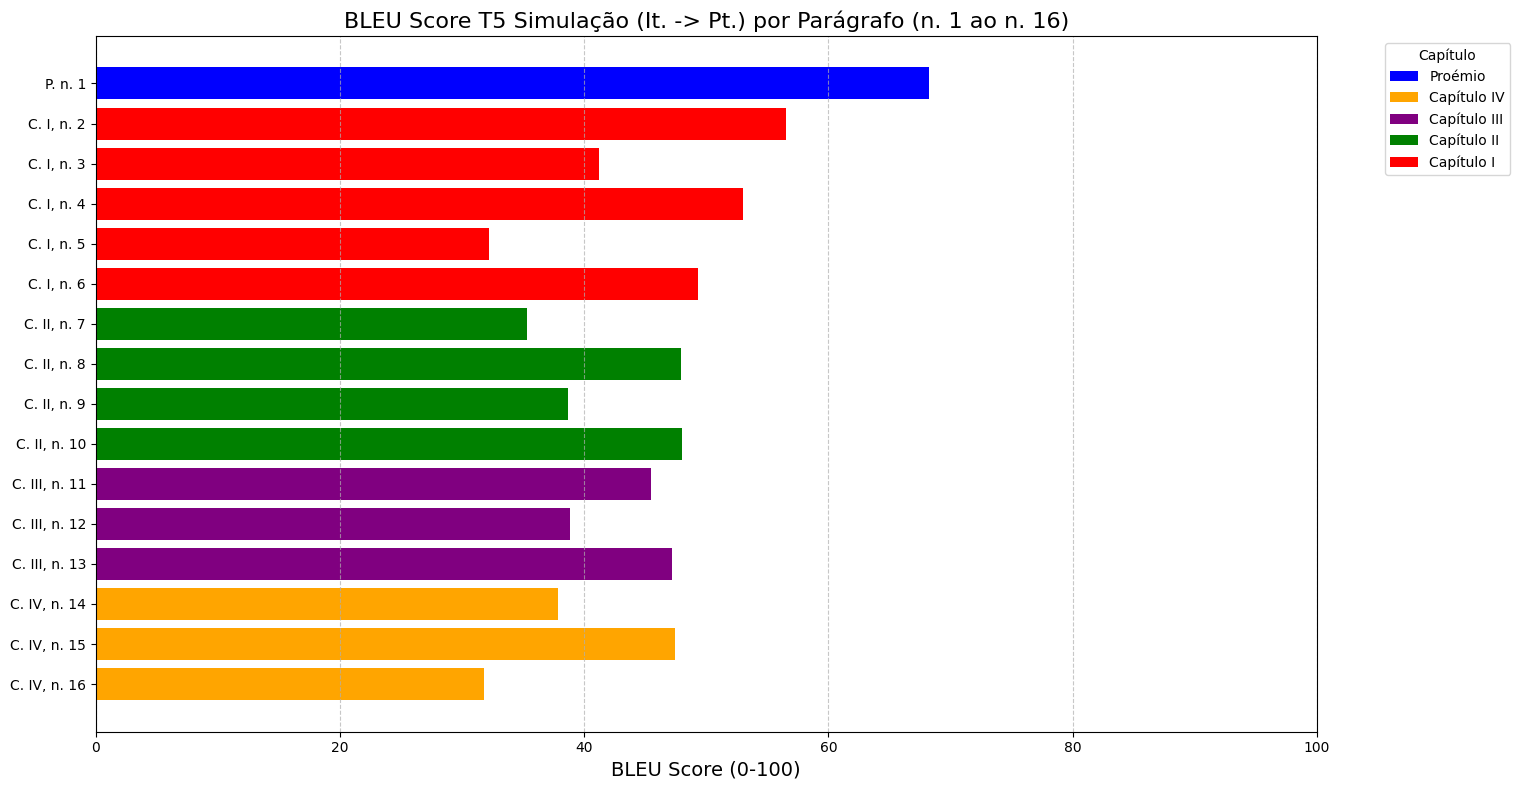

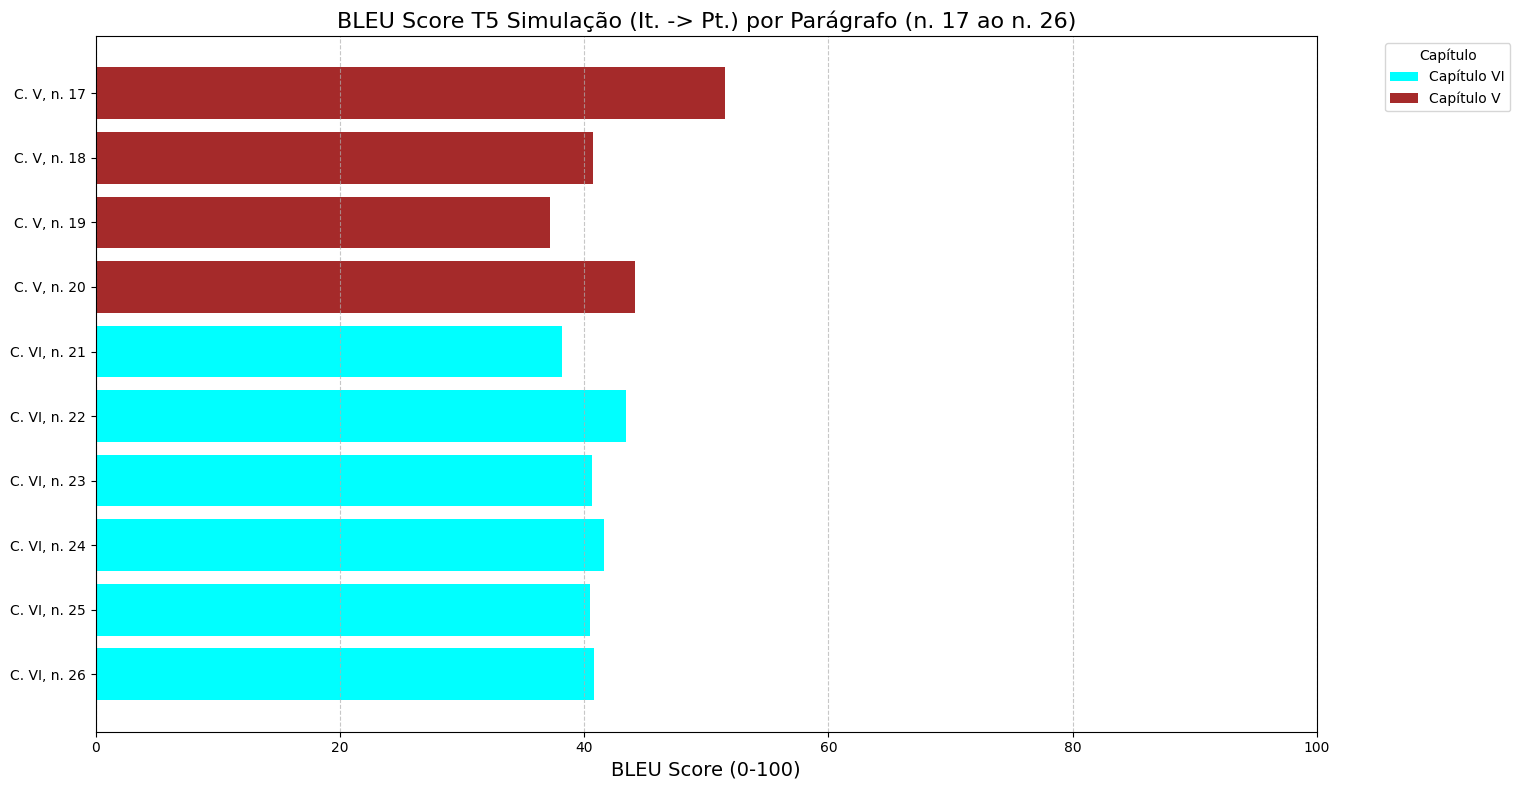

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Mapeamento de cores por capítulo (baseado no prefixo curto)
COLOR_MAP = {
    'P.': 'blue',    # Proémio
    'C. I': 'red',
    'C. II': 'green',
    'C. III': 'purple',
    'C. IV': 'orange',
    'C. V': 'brown',
    'C. VI': 'cyan',
}

def get_chapter_prefix(title_short):
    """Extrai o prefixo do capítulo para mapeamento de cores (e.g., 'C. I')."""
    if title_short.startswith('P.'):
        return 'P.'
    # Pega o prefixo (e.g., 'C. I, n. 2' -> 'C. I')
    parts = title_short.split(',')
    if len(parts) > 0:
        return parts[0].strip()
    return 'gray'

# --- DADOS DE BLEU SCORE PRÉ-CALCULADOS (T5 Simulação: Italiano -> Português) ---

# Scores para Parágrafos 1 ao 16
results_1_16 = [
    {'title': 'P. n. 1', 'score': 68.20},
    {'title': 'C. I, n. 2', 'score': 56.55},
    {'title': 'C. I, n. 3', 'score': 41.24},
    {'title': 'C. I, n. 4', 'score': 53.03},
    {'title': 'C. I, n. 5', 'score': 32.18},
    {'title': 'C. I, n. 6', 'score': 49.33},
    {'title': 'C. II, n. 7', 'score': 35.29},
    {'title': 'C. II, n. 8', 'score': 47.96},
    {'title': 'C. II, n. 9', 'score': 38.64},
    {'title': 'C. II, n. 10', 'score': 47.99},
    {'title': 'C. III, n. 11', 'score': 45.47},
    {'title': 'C. III, n. 12', 'score': 38.83},
    {'title': 'C. III, n. 13', 'score': 47.16},
    {'title': 'C. IV, n. 14', 'score': 37.89},
    {'title': 'C. IV, n. 15', 'score': 47.45},
    {'title': 'C. IV, n. 16', 'score': 31.78},
]

# Scores para Parágrafos 17 ao 26
results_17_26 = [
    {'title': 'C. V, n. 17', 'score': 51.52},
    {'title': 'C. V, n. 18', 'score': 40.75},
    {'title': 'C. V, n. 19', 'score': 37.19},
    {'title': 'C. V, n. 20', 'score': 44.20},
    {'title': 'C. VI, n. 21', 'score': 38.16},
    {'title': 'C. VI, n. 22', 'score': 43.46},
    {'title': 'C. VI, n. 23', 'score': 40.67},
    {'title': 'C. VI, n. 24', 'score': 41.67},
    {'title': 'C. VI, n. 25', 'score': 40.50},
    {'title': 'C. VI, n. 26', 'score': 40.78},
]

def plot_horizontal_bars_no_scores(results, range_label, model_name):
    """Gera o gráfico de barras horizontal com cores por capítulo, sem exibir os scores numéricos."""
    titles = [r['title'] for r in results]
    scores = [r['score'] for r in results]

    # Determinar a cor para cada barra
    colors = [COLOR_MAP.get(get_chapter_prefix(title), 'gray') for title in titles]

    # Reverter a ordem para que o n. 1 (ou n. 17) fique no topo do gráfico horizontal
    titles.reverse()
    scores.reverse()
    colors.reverse()

    plt.figure(figsize=(15, 8))

    # Criar gráfico de barras horizontal (barh)
    plt.barh(titles, scores, color=colors)

    # Títulos e Rótulos (ajustados para gráfico horizontal)
    plt.title(f'BLEU Score {model_name} (It. -> Pt.) por Parágrafo ({range_label})', fontsize=16)
    plt.xlabel('BLEU Score (0-100)', fontsize=14) # Eixo X é o score
    plt.yticks(titles, rotation=0, fontsize=10) # Rótulos dos parágrafos no Eixo Y
    plt.xlim(0, 100) # Define limite máximo para consistência visual no eixo X
    plt.grid(axis='x', linestyle='--', alpha=0.7) # Grid no eixo X

    # A lógica de adicionar texto com scores foi removida daqui, conforme solicitado.

    # Ajusta o layout para dar espaço à legenda
    plt.tight_layout(rect=[0, 0, 0.9, 1])

    # Criar uma legenda manual para as cores dos capítulos
    present_chapters = sorted(list(set(get_chapter_prefix(t) for t in titles)))
    present_chapters.reverse() # Reverte para que a legenda siga a ordem do gráfico
    legend_handles = [plt.Rectangle((0, 0), 1, 1, fc=COLOR_MAP[key]) for key in present_chapters]
    legend_labels = [f"Capítulo {key.replace('C. ', '')}" if key != 'P.' else "Proémio" for key in present_chapters]

    # Posicionar a legenda fora do gráfico
    plt.legend(legend_handles, legend_labels, title="Capítulo", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.show()


# --- EXECUÇÃO DO PLOTAGEM PARA T5 (PARÁGRAFOS 1 ao 16) ---
plot_horizontal_bars_no_scores(results_1_16, "n. 1 ao n. 16", "T5 Simulação")

# --- EXECUÇÃO DO PLOTAGEM PARA T5 (PARÁGRAFOS 17 ao 26) ---
plot_horizontal_bars_no_scores(results_17_26, "n. 17 ao n. 26", "T5 Simulação")


## Nllb m2m100 ##

In [ ]:
from difflib import SequenceMatcher
import re
import matplotlib.pyplot as plt
import sacrebleu
import numpy as np

In [ ]:
!pip install sacrebleu

In [ ]:
# Proémio, n. 1
REF_1 = [
    "Il sacro Concilio, udendo con religiosa attenzione la parola di Dio e proclamandola con ferma fiducia, fa sue queste parole di san Giovanni: «Vi annunziamo la vita eterna, che era presso il Padre e si manifestò a noi: vi annunziamo ciò che abbiamo veduto e udito, affinché anche voi siate in comunione con noi, e la nostra comunione sia col Padre e col Figlio suo Gesù Cristo» (1 Gv 1,2-3).",
    "Perciò, seguindo i Concili Tridentino e Vaticano I, esso intende proporre l'autentica dottrina sulla divina Rivelazione e sulla sua trasmissione, affinché, per l'annunzio della salvezza, il mondo intero ascoltando creda, credendo speri, sperando ami.",
]
AUTO_1 = [
    "O sacro Concílio, ouvindo religiosamente a Palavra de Deus e proclamando-a com firme confiança, faz suas estas palavras de São João: «Anunciamos-vos a vida eterna, que estava junto do Pai e se manifestou a nós: anunciamos-vos o que vimos e ouvimos, a fim de que também vós sejais em comunhão conosco, e a nossa comunhão seja com o Pai e com o seu Filho Jesus Cristo» (1 Jo 1,2-3).",
    "Por isso, seguindo os Concílios Tridentino e Vaticano I, tenciona propor a genuína doutrina sobre a Revelação divina e a sua transmissão, para que, o mundo inteiro, ouvindo, acredite na mensagem da salvação, acreditando espere e esperando ame.",
]

# Capítulo I, n. 2
REF_2 = [
    "Piacque a Dio nella sua bontà e sapienza rivelare se stesso e far conoscere il mistero della sua volontà (cfr. Ef 1,9), mediante il quale gli uomini per mezzo di Cristo, Verbo fatto carne, nello Spirito Santo hanno accesso al Padre e sono resi partecipi della divina natura (cfr. Ef 2,18; 2 Pt 1,4).",
    "Con questa rivelazione infatti, Dio invisibile (cfr. Col 1,15; 1 Tm 1,17) nel suo immenso amore parla agli uomini come ad amici (cfr. Es 33,11; Gv 15,14-15) e si intrattiene con essi (cfr. Bar 3,38), per invitarli e ammetterli alla comunione con sé.",
    "Questa «economia» della Rivelazione avviene con eventi e parole intimamente connessi tra loro, in modo che le opere, compiute da Dio nella storia della salvezza, manifestano e rafforzano la dottrina e le realtà significate dalle parole, e le parole a loro volta proclamano le opere e chiariscono il mistero in esse contenuto.",
    "Però la profonda verità, sia riguardo a Dio, sia riguardo alla salvezza degli uomini, per mezzo di questa Rivelazione, risplende a noi in Cristo, che è insieme il mediatore e la pienezza di tutta intera la Rivelazione (2).",
]
AUTO_2 = [
    "Aprouve a Deus na sua bondade e sabedoria revelar-se a si e dar a conhecer o mistério da sua vontade (cfr. Ef 1,9), mediante o qual os homens por meio de Cristo, Verbo feito carne, no Espírito Santo têm acesso ao Pai e são tornados participantes da natureza divina (cfr. Ef 2,18; 2 Pt 1,4).",
    "Com esta revelação, Deus invisível (cfr. Col 1,15; 1 Tm 1,17) no seu imenso amor fala aos homens como amigos (cfr. Ex 33,11; Jo 15,14-15) e se entretém com eles (cfr. Bar 3,38), para os convidar e admitir à comunhão consigo.",
    "Esta economia da revelação ocorre com eventos e palavras intimamente conectados entre si, de modo que as obras, realizadas por Deus na história da salvação, manifestam e reforçam a doutrina e as realidades significadas pelas palavras, e as palavras, por sua vez, proclamam as obras e esclarecem o mistério nelas contido.",
    "Porém, a verdade profunda, seja sobre Deus seja sobre a salvação dos homens, por meio desta Revelação, resplandece-us em Cristo, que é, juntamente, o mediador e a plenitude de toda a Revelação (2).",
]

# Capítulo I, n. 3
REF_3 = [
    "Dio, il quale crea e conserva tutte le cose per il Verbo (cfr. Gv 1,3), offre agli uomini nelle cose create una perenne testimonianza di sé (cfr. Rm 1,19-20). Inoltre, volendo aprire la via della salvezza soprannaturale, fin dal principio manifestò se stesso ai Progenitori.",
    "Dopo la loro caduta, con la promessa della redenzione, li sollevò alla speranza della salvezza (cfr. Gn 3,15), e senza interruzione ebbe cura del genere umano, per dare la vita eterna a tutti coloro que cercano la salvezza con la perseveranza nelle buone opere (cfr. Rm 2,6-7).",
    "A suo tempo chiamò Abramo, per fare di lui un popolo grande (cfr. Gn 12,2), popolo che dopo i Patriarchi istruì per mezzo di Mosè e dei profeti, affinché lo riconoscesse come l'unico Dio vivo e vero, padre provvido e giusto giudice, e attendesse il Salvatore promesso; e così preparò attraverso i secoli la via al Vangelo.",
]
AUTO_3 = [
    "Deus, o qual cria e conserva tudo pelo Verbo (cfr. Jo 1,3), oferece aos homens em todas as coisas criadas um testemunho perene de si (cfr. Rm 1,19-20). Além disso, querendo abrir a via da salvação sobrenatural, desde o princípio manifestou-se a si aos Progenitores.",
    "Após sua caída, com a promessa de redenção, os elevou à esperança da salvação (cfr. Gn 3,15), e jamais parou de cuidar do gênero humano, para dar a vida eterna a todos os que procuram a salvação com perseverança nas boas obras (cfr. Rm 2,6-7).",
    "A seu tempo chamou Abraão, para fazer dele um povo grande (cfr. Gn 12,2), povo que após os Patriarcas instruiu por Moisés e os profetas, para que o reconhecessem como o único Deus vivo e verdadeiro, pai providente e justo juiz, e em espera do Salvador prometido; e deste modo preparou através dos séculos o caminho ao Evangelho.",
]

# Capítulo I, n. 4
REF_4 = [
    "Dopo aver a più riprese e in più modi parlato per mezzo dei profeti, « Dio ultimamente, in questi giorni, ha parlato a noi per mezzo del Figlio » (Eb 1,1-2).",
    "Ha mandato infatti il Figlio suo, cioè il Verbo eterno, che illumina tutti gli uomini, affinché dimorasse tra gli uomini e ad essi spiegasse l'intimo di Dio (cfr. Gv 1,1-18).",
    "Gesù Cristo, Verbo fatto carne, mandato come «uomo agli uomini» (3), «parla le parole di Dio» (Gv 3,34) e porta a compimento l'opera di salvezza que il Padre gli aveva affidato (cfr. Gv 5,36; 17,4).",
    "Perciò chi vede lui, vede anche il Padre (cfr. Gv 14,9). Egli, con tutta la sua presenza e manifestazione, con le parole e con le opere, con i segni e con i miracoli, e specialmente con la sua morte e gloriosa risurrezione, e infine con l'invio dello Spirito di verità, compie e completa la Rivelazione e la conferma con la testimonianza divina, ossia che Dio è con noi per liberarci dalle tenebre del peccato e della morte e per risuscitarci a vita eterna.",
    "Per questo l'Economia cristiana, in quanto Alleanza nuova e definitiva, non passerà mai, e non si dovrà attendere nessun'altra rivelazione pubblica prima della manifestazione gloriosa del Signore nostro Gesù Cristo (cfr. 1 Tm 6,14; Tt 2,13).",
]
AUTO_4 = [
    "Depois de ter falado por meio dos profetas, muitas vezes e em diversos modos, Deus «ultimamente, nestes dias, falou a nós por meio do Filho» (Eb 1,1-2).",
    "Mandou de facto o seu Filho, isto é, o Verbo eterno, que ilumina todos os homens, para que morasse entre os homens e a eles explicasse o íntimo de Deus (cfr. Jo 1,1-18).",
    "Jesus Cristo, Verbo feito carne, enviado como «homem aos homens» (3), «fala as palavras de Deus» (Jo 3,34) e leva a cumprimento a obra de salvação que o Pai lhe tinha confiado (cfr. Jo 5,36; 17,4).",
    "Portanto, quem vê ele, vê também o Pai (cfr. Gv 14,9). Por isso Ele, com toda a sua presença e manifestação, com as palavras e com as obras, com os sinais e com os milagres, e especialmente com a sua morte e gloriosa ressurreição, enfim com o envio do Espírito de verdade, cumpre e completa a Revelação e a confirma com o testemunho divino, ou seja, que Deus está connosco para nos livrar das trevas do pecado e da morte e para nos ressuscitar à vida eterna.",
    "Por isso a Economia cristã, enquanto Aliança nova e definitiva, não passará jamais e não se deverá esperar nenhuma nova revelação pública antes da manifestação gloriosa do Senhor nosso Jesus Cristo (cfr. 1 Tm 6,14; Tt 2,13).",
]

# Capítulo I, n. 5
REF_5 = [
    "A Dio che rivela è dovuta «l'obbedienza della fede» (Rm 16,26; cfr. Rm 1,5; 2 Cor 10,5-6).",
    "Con la fede infatti l'uomo si abbandona interamente a Dio liberamente, prestando «con l'intelletto e con la volontà l'ossequio pieno a Dio che rivela» (4) e dando il suo assenso volontario alla rivelazione fatta da lui.",
    "Per prestare questa fede, é necessária la grazia di Dio che previene e soccorre, e gli aiuti interiori dello Spirito Santo, il quale muova il cuore e lo rivolga a Dio, apra gli occhi della mente e dia «a tutti soavità nel consentire e nel credere alla verità» (5).",
    "Affinché l'intelligenza della Rivelazione diventi sempre più profonda, lo stesso Spirito Santo perfeziona continuamente la fede per mezzo dei suoi doni.",
]
AUTO_5 = [
    "À «obediência da fé» (Rm 16,26; cfr. Rm 1,5; 2 Cor 10,5-6) o homem deve-se a Deus que revela.",
    "Com a fé, de facto, o homem se abandona todo a Deus livremente, prestando «o obséquio pleno do intelecto e da vontade a Deus que revela» (4) e dando o seu assenso volontário à Revelação feita por ele.",
    "Para prestar esta fé, é necessária a graça de Deus, preveniente e auxiliadora, e os auxílios interiores do Espírito Santo, o qual mova o coração e o dirija a Deus, abra os olhos da mente e dê «a todos soavidade no consentir e nel crer à verdade» (5).",
    "A fim de que a inteligência da Revelação se torne sempre mais profunda, o mesmo Espírito Santo aperfeiçoa continuamente a fé por meio dos seus donos.",
]

# Capítulo I, n. 6
REF_6 = [
    "Con la divina Rivelazione Iddio volle manifestare e comunicare se stesso e i decreti della sua volontà per la salvezza degli uomini, «per renderli cioè partecipi dei beni divini, che trascendono assolutamente l'intelligenza della mente umana» (6).",
    "Il santo Concilio professa que «Dio, principio e fine di tutte le cose, può essere conosciuto con certezza con la luce naturale della ragione umana a partire dalle cose create» (cfr. Rm 1,20);",
    "ma insegna pure che è merito della Rivelazione divina se «tutto ciò que nelle cose divine non è per sé inaccessibile alla ragione umana, può, anche nell'attuale condizione del genere umano, essere conosciuto da tutti facilmente, con ferma certezza e senza mescolanza di errore» (7).",
]
AUTO_6 = [
    "Com a divina Revelação Deus quis manifestar e comunicar-se a si e os decretos eternos da sua vontade a respeito da salvação dos homens, «para os tornar participantes daqueles bens divinos, que transcendem absolutamente a capacidade da inteligência humana».",
    "O santo Concílio professa que «Deus, princípio e fim de todas as coisas, pode ser conhecido com certeza com a luz natural da razão a partir das coisas criadas» (cfr. Rm 1,20);",
    "mas ensina também que é mérito da Revelação divina se «tudo aquilo que nas coisas divinas não é por si inacessível à razão humana, pode, mesmo no presente estado do gênero humano, ser conhecido por todos facilmente, com firme certeza e sem mistura de erro».",
]

# Capítulo II, n. 7
REF_7 = [
    "Dio con somma benignità dispose che quanto Egli aveva rivelato per la salvezza di tutte le genti, rimanesse per sempre integro e venisse trasmesso a tutte le generazioni.",
    "Perciò Cristo Signore, nel quale si compie tutta intera la Rivelazione del sommo Dio (cfr. 2 Cor 1,20; 3,16-4,6), dopo aver portato a compimento in sé tutta la verità de Dio predicò di persona (1), comandò agli apostoli che predicassero a tutti, come la fonte di ogni verità salutare e di ogni regola morale, quel Vangelo che egli prima aveva promesso per mezzo dei profeti e che poi aveva adempiuto e promulgato di persona, comunicando così ad essi i doni divini.",
    "Questo venne fedelmente eseguito, sia dagli apostoli, i quali nella predicazione orale, con gli esempi e le istituzioni trasmisero sia ciò che avevano ricevuto dalla bocca del Cristo vivendo con lui e osservandolo agire, sia ciò che avevano imparato dai suggerimenti dello Spirito Santo, sia da quegli apostoli o da uomini della loro cerchia, i quali, per ispirazione dello stesso Spirito Santo, misero per iscritto il messaggio della salvezza (2).",
    "Gli apostoli poi, affinché il Vangelo si conservasse sempre integro e vivo nella Chiesa, lasciarono come loro successori i vescovi, ad essi «affidando il loro proprio posto di maestri» (3).",
    "Questa sacra Tradizione e la sacra Scrittura di entrambi i Testamenti sono dunque come uno specchio nel quale la Chiesa pellegrina in terra contempla Dio, dal quale tutto riceve, finché giunga a vederlo faccia a faccia, com'egli è (cfr. 1 Gv 3,2).",
]
AUTO_7 = [
    "Deus, com suma benignidade, dispôs que o quanto ele tinha revelado para a salvação de todos os povos, permanecesse para sempre íntegro e fosse transmitido a todas as gerações.",
    "Por isso Cristo Senhor, no qual se cumpre toda a Revelação do Deus altíssimo, ordenou aos apóstolos que o Evangelho, antes prometido por meio dos profetas e por ele cumprido e promulgado em pessoa fosse por eles pregado a todos como a fonte de toda verdade salutar e de toda regra moral [8], comunicando assim a eles os dons divinos.",
    "Isto veio fielmente executado, tanto pelos apóstolos, os quais na pregação oral, com os exemplos e as instituições transmitiram tanto o que tinham recebido da boca do Cristo vivendo com ele e o observando agir, quanto daqueles apóstolos e de homens de seu círculo, os quais, por inspiração do Espírito Santo, puseram por escrito a mensagem da salvação [9].",
    "Os apóstolos depois, para que o Evangelho se conservasse sempre íntegro e vivo na Igreja, deixaram como seus sucessores os bispos, a eles «confiando o seu próprio posto de mestres» [10].",
    "Esta sacra Tradição e a Escritura sacra de um e outro Testamento são então como um espelho no qual a Igreja peregrina em terra contempla Deus, do qual tudo recebe, até que chegue a vê-lo face a face, como ele é (cfr. 1 Gv 3,2).",
]

# Capítulo II, n. 8
REF_8 = [
    "Così la predicazione apostolica, che è espressa in modo speciale nei libri ispirati, doveva con una successione ininterrotta conservarsi sino alla fine dei tempi.",
    "Perciò gli apostoli, trasmettendo ciò che essi stessi avevano ricevuto, ammoniscono i fedeli ad attenersi alle tradizioni che avevano appreso o con la parola, o per scritto (cfr. 2 Ts 2,15), e a combattere per la fede che ad essi era stata trasmessa una volta per tutte (cfr. Gd 3)(4).",
    "Ora, ciò que fu trasmesso dagli apostoli, comprende tutto quanto contribuisce alla santità di vita e al incremento della fede nel popolo di Dio; e così la Chiesa, nella sua dottrina, nella sua vita e nel suo culto, perpetua e trasmette a tutte le generazioni tutto ciò che essa è, tutto ciò che essa crede.",
    "Questa Tradizione, che trae origine dagli apostoli, progredisce nella Chiesa con l'assistenza dello Spirito Santo (5).",
    "Cresce infatti la comprensione, tanto delle cose quanto delle parole trasmesse, sia con la contemplazione e lo studio dei credenti, che le meditano in cuor loro (cfr. Lc 2,19 e 51), sia con l'intelligenza interiore, che essi provano delle cose spirituali, sia per la predicazione di coloro i quali con la successione episcopale hanno ricevuto un carisma sicuro di verità.",
    "La Chiesa cioè, nel corso dei secoli, tende incessantemente alla pienezza della verità divina, finché in essa giungano a compimento le parole di Dio.",
    "Le asserzioni dei santi Padri attestano la presenza vivificatrice di questa Tradizione, i cui tesori si riversano nella pratica e nella vita della Chiesa credente e orante.",
    "Per mezzo di questa medesima Tradizione la Chiesa conosce il canone completo dei libri sacri, e le stesse sacre Scritture in essa vengono comprese più profondamente e rese incessantemente operanti;",
    "e così Dio, il quale parlò nel passato, non cessa di conversare con la Sposa del suo Figlio diletto;",
    "e lo Spirito Santo, per mezzo del quale la voce viva del Vangelo risuona nella Chiesa, e per mezzo di questa nel mondo, introduce i credenti in tutta intera la verità e fa sì che in essi risieda abbondantemente la parola di Cristo (cfr. Col 3,16).",
]
AUTO_8 = [
    "Assim a pregação apostólica, que é expressa de modo especial nos livros inspirados, devia com uma sucessão ininterrupta ser conservada até ao fim dos tempos.",
    "Por isso os Apóstolos, transmitindo o que eles próprios tinham recebido, advertem os fiéis a se aterem às tradições que tinham aprendido quer com a palavra quer por escrito (cfr. 2 Ts 2,15), e a combater pela fé que lhes tinha sido uma vez por todas transmitida (cfr. Jd 3).",
    "Ora, aquilo que foi transmitido pelos Apóstolos compreende tudo quanto contribui para a santidade de vida do povo de Deus e para o incremento da fé;",
    "e assim a Igreja, na sua doutrina, na sua vida e no seu culto, perpetua e transmite a todas as gerações tudo aquilo que ela é e tudo aquilo em que acredita.",
    "Esta Tradição, que tem origem nos Apóstolos, progride na Igreja com a assistência do Espírito Santo.",
    "Cresce de facto a compreensão, tanto das coisas como das palavras transmitidas, quer com a contemplação e o estudo dos crentes, os quais as meditam em seu coração (cfr. Lc 2,19 e 51), quer com a inteligência interior, que eles experimentam das coisas espirituais, quer pela pregação daqueles que com a sucessão episcopal receberam um carisma seguro de verdade.",
    "A Igreja isto é, no decurso dos séculos, tende incessantemente à plenitude da verdade divina, até que nela cheguem a cumprimento as palavras de Deus.",
    "As afirmações dos santos Padres atestam a presença vivificadora desta Tradição, cujas riquezas se derramam na prática e na vida da Igreja crente e orante.",
    "Por meio da mesma Tradição a Igreja conhece o inteiro cânon dos livros sagrados, e as mesmas Sagradas Escrituras nela se compreendem mais profundamente e se tornam incessantemente operantes;",
    "e assim Deus, o qual falou no passado, não cessa de conversar com a Esposa do seu Filho dileto;",
    "e o Espírito Santo, por meio do qual a voz viva do Evangelho ressoa na Igreja e, pela Igreja, no mundo, introduz os crentes em toda a verdade e faz com que neles resida abundantemente a palavra de Cristo (cfr. Col 3,16).",
]

# Capítulo II, n. 9
REF_9 = [
    "La sacra Tradizione e la sacra Scrittura sono dunque strettamente connesse e comunicanti tra loro.",
    "Infatti, ambedue scaturiscono dalla medesima sorgente divina, formano in certo qual modo una cosa sola e tendono allo stesso fine.",
    "La sacra Scrittura infatti è la parola di Dio in quanto è messa per iscritto sotto l'ispirazione dello Spirito divino.",
    "Quanto alla sacra Tradizione, essa trasmette integralmente la parola di Dio, affidata da Cristo Signore e dallo Spirito Santo agli Apostoli, ai loro successori, affinché questi, illuminati dallo Spirito di verità, nella loro predicazione la conservino fedelmente, la espongano e la diffondano.",
    "Ne consegue che la Chiesa non attinge la certezza su tutte le cose rivelate dalla sola sacra Scrittura.",
    "Perciò l'una e l'altra devono essere accettate e venerate con pari sentimento di pietà e di riverenza (6).",
]
AUTO_9 = [
    "A sacra Tradição e a sacra Escritura estão então estritamente conectadas e comunicantes entre elas.",
    "De facto, ambas brotam da mesma fonte divina, formam de certo modo uma coisa só e tendem ao mesmo fim.",
    "Visto que a sacra Escritura é a Palavra de Deus enquanto é posta por escrito sob a inspiração do Espírito divino.",
    "A sacra Tradição, por outro lado, transmite integralmente a Palavra de Deus, confiada por Cristo Senhor e pelo Espírito Santo aos Apóstolos, aos seus sucessores, para que estes, iluminados pelo Espírito de verdade, na sua pregação a conservem, a exponham e a difundam fielmente.",
    "Consegue-se que a Igreja atinja a certeza sobre todas as coisas reveladas não só da sacra Escritura.",
    "Por isso, uma e outra devem ser aceitas e veneradas com igual sentimento de piedade e de reverência.",
]

# Capítulo II, n. 10
REF_10 = [
    "La sacra Tradizione e la sacra Scrittura costituiscono un solo sacro deposito della parola di Dio affidato alla Chiesa;",
    "nell'aderire ad esso, tutto il popolo santo, unito ai suoi Pastori, persevera costante nell'insegnamento degli Apostoli e nella comunione, nella frazione del pane e nella preghiera (cfr. At 2,42 gr.), in modo che nel ritenere, praticare e professare la fede trasmessa, si crei una singolare concordia di vescovi e di fedeli (7).",
    "L'ufficio poi d'interpretare autenticamente la parola di Dio scritta o trasmessa, è affidato al solo Magistero vivo della Chiesa (8), la cui autorità è esercitata nel nome di Gesù Cristo (9).",
    "Il Magistero, tuttavia, non è superior alla parola di Dio, ma la serve, insegnando soltanto ciò que é stato trasmesso, in quanto, per divino mandato e con l'assistenza dello Spirito Santo, piamente la ascolta, santamente la custodisce e fedelmente la espone, attingendo da questo unico deposito della fede tutto ciò che propone da credere come divinamente rivelato.",
    "È chiaro dunque che la sacra Tradizione, la sacra Scrittura e il Magistero della Chiesa, per sapientissima disposizione di Dio, sono tra loro così connessi e congiunti che nessuno d'essi sussiste senza gli altri, e tutti insieme, ciascuno a suo modo, sotto l'azione dello Spirito Santo, contribuiscono efficacemente alla salvezza delle anime.",
]
AUTO_10 = [
    "A sacra Tradição e a sacra Escritura constituem um só depósito sagrado da Palavra de Deus, confiado à Igreja;",
    "aderindo a este, todo o Povo santo, unido aos seus Pastores, persevera constante no ensinamento dos Apóstolos e na comunhão, na fração do pão e na oração (cfr. At 2,42 gr.), de modo que no reter, praticar e professar a fé transmitida, se crie uma singular concórdia de Bispos e de fiéis.",
    "O encargo, no entanto, de interpretar autenticamente a Palavra de Deus escrita ou transmitida é confiado ao só Magistério vivo da Igreja, o qual o exerce em nome de Jesus Cristo.",
    "O Magistério, todavia, não é superior à Palavra de Deus mas a ela serve, ensinando somente aquilo que foi transmitido, enquanto, por divino mandato e com a assistência do Espírito Santo, a escuta piamente, a custode santamente e a expõe fielmente, haurindo deste depósito único da fé tudo aquilo que propõe a crer como divinamente revelado.",
    "É claro, pois, que a sacra Tradição, a sacra Escritura e o Magistério da Igreja, por sapientíssima disposição de Deus, estão entre si tão conectados e unidos que nenhum deles subsiste sem os outros, e todos juntos, cada um a seu modo, sob a ação do mesmo Espírito Santo, contribuem eficazmente para a salvação das almas.",
]

# Capítulo III, n. 11
REF_11 = [
    "Le verità divinamente rivelate, che nei libri della sacra Scrittura sono contenute ed espresse, furono scritte per ispirazione dello Spirito Santo.",
    "La santa Madre Chiesa, secondo la fede degli Apostoli, ritiene sacri e canonici tutti i libri sia dell'Antico che del Nuovo Testamento con tutte le loro parti, perché scritti per ispirazione dello Spirito Santo (cfr. Gv 20,31; 2 Tm 3,16; 2 Pt 1,19-21; 3,15-16), hanno Dio per autore e como tali sono stati affidati alla Chiesa stessa (1).",
    "Per la composizione dei libri sacri, Dio scelse degli uomini di cui si servì nel possesso delle loro facoltà e capacità, affinché, agendo egli in essi e per essi (2), scrivessero come veri autori, tutte e soltanto quelle cose che Egli voleva (3).",
    "Poiché dunque tutto quello che gli autori ispirati o agiografi asseriscono è da ritenersi asserito dallo Spirito Santo, ne consegue que i libri della Scrittura insegnano con certezza, fedelmente e senza errore la verità que Dio per la nostra salvezza volle fosse consegnata nelle sacre Lettere (4).",
    "Perciò «tutta la Scrittura è ispirata da Dio e utile per insegnare, per convincere, per correggere, per educare alla giustizia, affinché l'uomo di Dio sia perfetto, pronto per ogni opera buona» (2 Tm 3,16-17 gr.).",
]
AUTO_11 = [
    "As verdades divinamente reveladas, que nos livros da sacra Escritura são contidas e expressas, foram escritas por inspiração do Espírito Santo.",
    "A santa Mãe Igreja, segundo a fé dos Apóstolos, retém sacros e canónicos todos os livros inteiros tanto do Velho como do Novo Testamento, com todas as suas partes, porque escritos sob inspiração do Espírito Santo (cfr. Jo 20,31; 2 Tm 3,16; 2 Pt 1,19-21; 3,15-16), têm Deus por autor e como tais foram confiados à Igreja.",
    "Para a composição dos livros sacros, Deus escolheu homens, dos quais se serviu no uso das suas faculdades e capacidades, para que, agindo Ele neles e por eles, escrevessem como verdadeiros autores, todas e só aquelas coisas que Ele queria.",
    "Visto que tudo aquilo que os autores inspirados ou hagiógrafos afirmam deve ser tido como afirmado pelo Espírito Santo, resulta que os livros da Escritura ensinam com fidelidade, firmemente e sem erro a verdade que Deus, para a nossa salvação, quis que fosse consignada nas sacras Letras.",
    "Por isso «toda a escritura é divinamente inspirada e útil para ensinar, para convencer, para corrigir, para educar à justiça, para que o homem de Deus seja perfeito, pronto para toda boa obra» (2 Tm 3,16-17 gr.).",
]

# Capítulo III, n. 12
REF_12 = [
    "Dio nella sacra Scrittura ha parlato per mezzo di uomini e alla maniera umana (5). Per l'interprete della sacra Scrittura, dunque, per conoscere ciò que Dio ha voluto comunicarci, bisogna ricercare con attenzione che cosa gli agiografi abbiano veramente voluto significare e a Dio sia piaciuto manifestare con le loro parole.",
    "Per scoprire l'intenzione degli agiografi, si deve tener conto tra l'altro anche dei «generi letterari».",
    "La verità infatti viene diversamente proposta ed espressa in testi in vario modo storici, o profetici, o poetici, o in altri modi di dire.",
    "È necessario che l'interprete ricerchi il senso che l'agiografo in determinate circostanze, secondo le condizioni del suo tempo e della sua cultura, e servendosi dei generi letterari allora in uso, intendeva esprimere e di fatto espresse (6).",
    "Per comprendere infatti esattamente ciò che l'autore sacro volle asserire, si deve tener conto convenientemente sia dei modi nativi di sentire, di esprimersi e di raccontare vigenti al tempo dell'agiografo, sia di quelli che in quel tempo erano abitualmente in uso nei rapporti umani (7).",
    "Ma poiché la sacra Scrittura deve essere letta e interpretata con lo stesso Spirito col quale fu scritta (8), per ricavarne con esattezza il senso dei testi sacri, si deve badare con non minore diligenza al contenuto e alla unità di tutta la Scrittura, tenuto debito conto della viva Tradizione di tutta la Chiesa e dell'analogia della fede.",
    "È compito degli esegeti lavorare secondo queste regole, per una più profonda intelligenza ed esposizione del senso della sacra Scrittura, affinché per mezzo di studi in qualche modo preparatori, maturi il giudizio della Chiesa.",
    "Tutto ciò infatti che concerne il modo di interpretare la Scrittura, è sottoposto in ultima istanza al giudizio della Chiesa, la quale adempie il divino mandato e ministero di custodire e interpretare la parola di Dio (9).",
]
AUTO_12 = [
    "Deus na sacra Escritura falou por intermédio de homens e à maneira humana. Portanto, o intérprete da sacra Escritura, para compreender o que Ele quis comunicar-nos, deve pesquisar com atenção o que os agiógrafos realmente quiseram significar e o que agradou a Deus manifestar com as suas palavras.",
    "Para descobrir a intenção dos agiógrafos, deve-se levar em consideração também os «géneros literários».",
    "Com efeito, a verdade é diversamente proposta e expressa em textos em vários modos históricos, ou proféticos, ou poéticos, ou em outros modos de dizer.",
    "É preciso que o intérprete pesquise o sentido que o agiógrafo em determinadas circunstâncias, segundo as condições do seu tempo e da sua cultura, e servindo-se dos géneros literários então em uso, intencionava expressar e de facto expressou.",
    "Para compreender de forma exata o que o autor sacro quis afirmar, deve-se prestar a devida atenção tanto aos modos nativos de sentir, de expressar e de narrar, vigentes ao tempo do agiógrafo, quanto àqueles que naquele tempo eram habitualmente em uso nas relações humanas.",
    "Mas, visto que a sacra Escritura deve ser lida e interpretada com o mesmo Espírito com o qual foi escrita, para extrair com exatidão o sentido dos textos sacros, deve-se atentar com não menor diligência ao conteúdo e à unidade de toda a Escritura, levado em conta a viva Tradição de toda a Igreja e a analogia da fé.",
    "É tarefa dos exegetas trabalhar segundo estas regras, para uma mais profunda inteligência e exposição do sentido da sacra Escritura, a fim de que por meio de estudos em algum modo preparatórios, amadureça o juízo da Igreja.",
    "De facto, tudo aquilo que concerne ao modo de interpretar a Escritura é submetido em última instância ao juízo da Igreja, que desempenha o divino mandato e o ministério de conservar e interpretar a Palavra de Deus.",
]

# Capítulo III, n. 13
REF_13 = [
    "Pertanto nella sacra Scrittura, ferma restando la verità e la santità di Dio, si manifesta la mirabile «condiscendenza» della Sapienza eterna, «perché impariamo quale ineffabile benignità di Dio e",
    "quanta sollecitudine Egli abbia avuto per la nostra natura» (10).",
    "Le parole di Dio infatti, espresse con lingue umane, si sono fatte simili al parlare umano, così come già il Verbo dell'eterno Padre, avendo assunto la carne dell'umana debolezza, divenne simile agli uomini.",
]
AUTO_13 = [
    "Portanto, na sacra Escritura, permanecendo firme a verdade e a santidade de Deus, manifesta-se a admirável «condescendência» da eterna sabedoria, «para que nós aprendamos qual inefável benignidade de Deus e",
    "quanta solicitude ele tenha tido pela nossa natureza» [11].",
    "As palavras de Deus de facto, expressas com línguas humanas, tornaram-se semelhantes ao falar humano, assim como um tempo o Verbo do eterno Pai, assumindo a carne da humana fraqueza, se fez semelhante aos homens.",
]

# Capítulo IV, n. 14
REF_14 = [
    "Dio con sommo amore, volendo e preparando la salvezza di tutto il genere umano, con singolare disegno si scelse un popolo, al quale affidare le sue promesse.",
    "Dopo aver stabilito un'alleanza con Abramo (cfr. Gn 15,18), e per mezzo di Mosè con il popolo d'Israele (cfr. Es 24,8), a questo popolo eletto si rivelò come l'unico Dio vivo e vero, in modo que Israele potesse conoscere per esperienza il piano di Dio nei riguardi degli uomini, e lo comprendesse con chiarezza e sempre più a fondo attraverso la parola dello stesso Dio che parlava per bocca dei profeti, e lo diffondesse in modo più ampio tra le genti (cfr. Sal 21,28-29; 95,1-3; Is 2,1-4; Ger 3,17).",
    "L'economia della salvezza, annunziata in precedenza, narrata e spiegata dagli autori sacri, si incontra nei libri dell'Antico Testamento come vera parola di Dio.",
    "Per questo tali libri divinamente ispirati conservano un valore perenne: «Tutto ciò infatti che fu scritto, fu scritto per nostra istruzione, affinché mediante la pazienza e la consolazione delle Scritture, avessimo la speranza» (Rm 15,4).",
]
AUTO_14 = [
    "Deus, com sumo amor, querendo e preparando a salvação de todo o género humano, com singular desígnio escolheu para si um povo, ao qual confiar as suas promessas.",
    "Depois de ter estabelecido uma aliança com Abraão (cfr. Gn 15,18), e, por meio de Moisés, com o povo de Israel (cfr. Ex 24,8), revelou-se a este povo eleito como o único Deus vivo e verdadeiro, de modo que Israel pudesse conhecer por experiência o plano de Deus no que diz respeito aos homens, e o compreendesse com clareza e sempre mais a fundo através da palavra do mesmo Deus que falava por boca dos profetas, e o difundisse de modo mais amplo entre as gentes (cfr. Sl 21,28-29; 95,1-3; Is 2,1-4; Jr 3,17).",
    "A economia da salvação, anunciada em precedência, narrada e explicada pelos autores sacros, encontra-se nos livros do Velho Testamento como verdadeira Palavra de Deus.",
    "Por isso, tais livros divinamente inspirados conservam um valor perene: «Tudo aquilo de facto que foi escrito, foi escrito para nossa instrução, a fim de que, mediante a paciência e a consolação das Escrituras, tivéssemos a esperança» (Rm 15,4).",
]

# Capítulo IV, n. 15
REF_15 = [
    "L'economia dell'Antico Testamento era soprattutto ordinata a preparare, ad annunziare profeticamente (cfr. Lc 24,44; Gv 5,39; 1 Pt 1,10) e a significare con varie figure (cfr. 1 Cor 10,11) l'avvento di Cristo, redentore universale, e del regno messianico.",
    "I libri dell'Antico Testamento, secondo la condizione del genere umano prima del tempo della salvezza attuata da Cristo, manifestano a tutti la conoscenza di Dio e dell'uomo e i modi con cui Dio giusto e misericordioso tratta gli uomini.",
    "Questi libri, sebbene contengano anche cose imperfette e caduche, dimostrano tuttavia una vera pedagogia divina (1).",
    "Perciò i fedeli devono accogliere con devozione questi libri, i quali esprimono il vivo senso di Dio, e nei quali si trovano sublimi dottrine su Dio, salutari insegnamenti sulla vita dell'uomo e mirabili tesori di orazioni, e finalmente nei quali è nascosto il mistero della nostra salvezza.",
]
AUTO_15 = [
    "A economia do Velho Testamento era sobretudo destinada a preparar, a anunciar com profecias (cfr. Lc 24,44; Gv 5,39; 1 Pt 1,10) e a significar com vários tipos (cfr. 1 Cor 10,11) a vinda de Cristo, redentor universal, e do reino messiânico.",
    "Os livros do Velho Testamento, segundo a condição do género humano antes do tempo da salvação efetuada por Cristo, manifestam a todos o conhecimento de Deus e do homem e os modos com que Deus justo e misericordioso trata os homens.",
    "Estes livros, embora contenham também coisas imperfeitas e caducas, demonstram todavia uma verdadeira pedagogia divina.",
    "Por isso, os fiéis devem acolher com devoção estes livros, os quais exprimem o vivo sentido de Deus, e nos quais se encontram sublimes doutrinas sobre Deus, salutares ensinamentos sobre a vida do homem e admiráveis tesouros de orações, e finalmente nos quais está escondido o mistério da nossa salvação.",
]

# Capítulo IV, n. 16
REF_16 = [
    "Perciò Dio, l'ispiratore e l'autore dei libri dell'uno e dell'altro Testamento, ha sapientemente disposto che il Nuovo fosse nascosto nell'Antico e l'Antico fosse svelato nel Nuovo (2).",
    "Quantunque infatti Cristo abbia fondato la Nuova Alleanza nel suo sangue (cfr. Lc 22,20; 1 Cor 11,25), tuttavia i libri dell'Antico Testamento, integralmente assunti nella predicazione evangelica (3), acquistano e manifestano il loro pieno significato nel Nuovo Testamento (cfr. Mt 5,17; Lc 24,27; Rm 16,25-26; 2 Cor 3,14-16), che essi a loro volta illuminano e spiegano.",
]
AUTO_16 = [
    "Deus portanto, o qual inspirou os livros de um e do outro Testamento e deles é o autor, dispôs sabiamente que o Novo fosse escondido no Velho e o Velho fosse revelado no Novo.",
    "Visto que, mesmo se Cristo fundou a Nova Aliança no seu sangue (cfr. Lc 22,20; 1 Cor 11,25), os livros do Velho Testamento, integralmente assumidos na pregação evangélica, adquirem e manifestam o seu pleno significado no Novo Testamento (cfr. Mt 5,17; Lc 24,27), que eles por sua vez iluminam e explicam.",
]

# Capítulo V, n. 17
REF_17 = [
    "La parola di Dio, che è potenza di Dio per la salvezza di chiunque crede (cfr. Rm 1,16), si presenta ed manifesta la sua forza in modo eminente negli scritti del Nuovo Testamento.",
    "Quando infatti venne la pienezza dei tempi (cfr. Gal 4,4), il Verbo si fece carne e abitò tra noi pieno di grazia e di verità (cfr. Gv 1,14).",
    "Cristo stabilì il regno di Dio sulla terra, manifestò con opere e parole il Padre suo e se stesso, e portò a compimento l'opera sua con la morte, la risurrezione e la gloriosa ascensione, e con l'invio dello Spirito Santo.",
    "Elevato da terra, egli attira tutti a sé (cfr. Gv 12,32 gr.), lui che solo ha parole di vita eterna (cfr. Gv 6,68).",
    "Questo mistero però non fu palesato alle altre generazioni, come ora è stato rivelato ai suoi santi apostoli e ai profeti nello Spirito Santo (cfr. Ef 3,4-6 gr.), affinché predicassero l'Evangelo, suscitassero la fede in Gesù Cristo Signore e raccogliessero la Chiesa.",
    "Di tutte queste cose gli scritti del Nuovo Testamento presentano una testimonianza perenne e divina.",
]
AUTO_17 = [
    "A palavra de Deus, que é potência divina para a salvação de quem crê (cfr. Rm 1,16), se apresenta e manifesta a sua força em modo eminente nos escritos do Novo Testamento.",
    "Quando de facto chegou a plenitude dos tempos (cfr. Gal 4,4), o Verbo se fez carne e habitou entre nós pleno de graça e de verdade (cfr. Jo 1,14).",
    "Cristo estabeleceu o reino de Deus sobre a terra, manifestou com obras e palavras o Pai seu e a si e levou a cumprimento a obra sua com a morte, a ressurreição e a gloriosa ascensão, assim como com o envio do Espírito Santo.",
    "Elevado da terra, atrai todos a si (cfr. Jo 12,32 gr.), ele que só tem palavras de vida eterna (cfr. Jo 6,68).",
    "Mas este mistério não foi palesado às outras gerações, como agora foi revelado aos seus santos apóstolos seus e aos profetas no Espírito Santo (cfr. Ef 3,4-6 gr.), para que pregassem o Evangelho, suscitasse a fé em Jesus Cristo Senhor e reunissem a Igreja.",
    "De tudo isto os escritos do Novo Testamento apresentam um testemunho perene e divino.",
]

# Capítulo V, n. 18
REF_18 = [
    "A nessuno sfugge che tra tutte le Scritture, anche del Nuovo Testamento, i Vangeli possiedono una meritata superiorità, in quanto costituiscono la principale testimonianza relativa alla vita e alla dottrina del Verbo incarnato, nostro Salvatore.",
    "La Chiesa ha ritenuto e ritiene sempre e in ogni luogo che i quattro Vangeli sono di origine apostolica.",
    "Infatti, ciò che gli apostoli per mandato di Cristo predicarono, in seguito, per ispirazione dello Spirito Santo, fu dagli stessi e da uomini della loro cerchia tramandato in scritti, che sono il fondamento della fede, cioè l'Evangelo quadriforme secondo Matteo, Marco, Luca e Giovanni (1).",
]
AUTO_18 = [
    "A ninguém escapa que entre todas as Escrituras, mesmo as do Novo Testamento, os Evangelhos possuem uma superioridade merecida, enquanto constituem o principal testemunho relativo à vida e à doutrina do Verbo encarnado, nosso Salvador.",
    "A Igreja sempre e em todo lugar reteve e retém que os quatro Evangelhos são de origem apostólica.",
    "De facto, aquilo que os apóstolos por mandato de Cristo pregaram, em seguida, por inspiração do Espírito Santo, foi pelos mesmos e por homens da sua cerchia transmitido em escritos que são o fundamento da fé, isto é, o Evangelho quadriforme segundo Mateus, Marcos, Lucas e João.",
]

# Capítulo V, n. 19
REF_19 = [
    "La santa Madre Chiesa ha ritenuto e ritiene con fermezza e con la massima costanza che i quattro Vangeli, di cui afferma senza esitazione la storicità, trasmettono fedelmente le cose che Gesù Figlio di Dio, durante la sua vita tra gli uomini, effettivamente operò e insegnò per la loro salvezza eterna, fino al giorno in cui fu assunto in cielo (cfr. At 1,1-2).",
    "Gli apostoli poi, dopo l'Ascensione del Signore, trasmisero ai loro uditori ciò che egli aveva detto e fatto, con quella più completa intelligenza delle cose, di cui essi, istruiti dagli eventi gloriosi di Cristo e illuminati dallo Spirito di verità (2), godevano (3).",
    "Gli autori sacri, poi, scrissero i quattro Vangeli, scegliendo alcune cose tra le molte tramandate a voce o già per iscritto, facendone una sintesi, o spiegandole avuto riguardo alla situazione delle Chiese, conservando infine il carattere di predicazione, sempre però in modo da riferire su Gesù cose vere e sincere (4).",
    "Essi infatti, attingendo sia dai propri ricordi sia dalla testimonianza di quelli «che fin dal principio furono testimoni oculari e ministri della parola», scrissero con l'intenzione di farci conoscere la «verità» (cfr. Lc 1,2-4) degli insegnamenti che abbiamo ricevuto.",
]
AUTO_19 = [
    "A santa mãe Igreja reteve e retém com firmeza e com a maior constância que os quatro Evangelhos supracitados, dos quais afirma sem hesitação a historicidade, transmitem fielmente aquilo que Jesus Filho de Deus, durante a sua vida entre os homens, efetivamente operou e ensinou para a sua salvação eterna, até ao dia em que foi assumido no céu (cfr. At 1,1-2).",
    "Os apóstolos depois, após a Ascensão do Senhor, transmitiram aos seus ouvintes o que ele tinha dito e feito, com aquela mais completa inteligência das coisas, de que eles, instruídos pelos eventos gloriosos de Cristo e iluminados pelo Espírito de verdade, gozavam.",
    "Os autores sacros, porém, escreveram os quatro Evangelhos, escolhendo algumas coisas entre as muitas que eram transmitidas oralmente ou já por escrito, redigindo um resumo de outras, ou explicando-as no que diz respeito à situação das Igrejas, conservando por fim o carácter de pregação, sempre porém de modo a relatar sobre Jesus coisas verdadeiras e sinceras.",
    "Eles de facto, extraindo seja das suas próprias recordações seja do testemunho daqueles que «desde o princípio foram testemunhas oculares e ministros da palavra», escreveram com a intenção de nos fazer conhecer a «verdade» (cfr. Lc 1,2-4) dos ensinamentos que recebemos.",
]

# Capítulo V, n. 20
REF_20 = [
    "Il canone del Nuovo Testamento, oltre ai quattro Vangeli, contiene anche le lettere di san Paolo e altri scritti apostolici, composti per ispirazione dello Spirito Santo; questi scritti, per saggia disposizione di Dio, confermano tutto ciò che riguarda Cristo Signore, spiegano ulteriormente la sua autentica dottrina, fanno conoscere la potenza salvifica dell'opera divina di Cristo, narrano gli inizi della Chiesa e la sua mirabile diffusione nel mondo e preannunziano la sua gloriosa consumazione.",
    "Il Signore Gesù infatti assistette i suoi apostoli como aveva promesso (cfr. Mt 28,20) e inviò loro lo Spirito consolatore, il quale li doveva introdurre nella pienezza della verità (cfr. Gv 16,13).",
]
AUTO_20 = [
    "O cânone do Novo Testamento, além dos quatro Evangelhos, contém também as cartas de São Paulo e outros escritos apostólicos, compostos por inspiração do Espírito Santo; estes escritos, por sábia disposição de Deus, confirmam tudo o que diz respeito a Cristo Senhor, explicam ulteriormente a sua doutrina autêntica, fazem conhecer a potência salvífica da obra divina de Cristo, narram os inícios da Igreja e a sua admirável difusão no mundo e preanunciam a sua gloriosa consumação.",
    "O Senhor Jesus, de facto, assistiu os seus apóstolos como tinha prometido (cfr. Mt 28,20) e enviou-lhes o Espírito consolador, o qual os devia introduzir na plenitude da verdade (cfr. Gv 16,13).",
]

# Capítulo VI, n. 21
REF_21 = [
    "La Chiesa ha sempre venerato le divine Scritture come venera lo stesso Corpo di Cristo, non mancando mai, soprattutto nella sacra Liturgia, di nutrirsi del pane di vita della mensa sia della parola di Dio que del Corpo di Cristo, e di porgerlo ai fedeli.",
    "Le ha sempre considerate, e le considera tuttora, insieme con la sacra Tradizione, come regola suprema della propria fede; esse infatti, ispirate come sono da Dio e redatte una volta per sempre, comunicano in modo immutabile la parola dello stesso Dio, e fanno risuonar nelle parole dei profeti e degli apostoli la voce dello Spirito Santo.",
    "È necessario perciò que tutta la predicazione ecclesiastica, come la stessa religione cristiana, sia nutrita e regolata dalla sacra Scrittura.",
    "Nei libri sacri, infatti, il Padre que è nei cieli viene con molta amorevolezza incontro ai suoi figli e entra in conversazione con essi;",
    "nella parola di Dio poi è insita una così grande efficacia e potenza, da essere sostegno e vigore della Chiesa, e per i figli della Chiesa la forza della loro fede, il nutrimento dell'anima, la sorgente pura e perenne della vita spirituale.",
    "Perciò si devono riferire in modo tutto speciale alla sacra Scrittura le parole: «Viva ed efficace è la parola di Dio» (Eb 4,12), «que ha il potere di edificare e di dare l'eredità con tutti i santificati» (At 20,32; cfr. 1 Ts 2,13).",
]
AUTO_21 = [
    "A Igreja sempre venerou as divinas Escrituras como o próprio Corpo de Cristo, não faltando nunca, sobretudo na sagrada liturgia, de nutrir-se do pão de vida da mesa seja da palavra de Deus seja do Corpo de Cristo, e de o oferecer aos fiéis.",
    "Juntamente com a sacra Tradição, sempre considerou e considera as divinas Escrituras como a regra suprema da sua fé; elas, de facto, inspiradas como são por Deus e redigidas uma vez por todas, comunicam imutavelmente a palavra do próprio Deus e fazem ressoar nas palavras dos profetas e dos apóstolos a voz do Espírito Santo.",
    "É necessário, portanto, que a pregação eclesiástica, tal como a própria religião cristã, seja nutrida e regulada pela sacra Escritura.",
    "Nos livros sacros, de facto, o Pai que está nos céus vem com muita amorosidade ao encontro dos seus filhos e entra em conversação com eles;",
    "na palavra de Deus está depois inserida tanta eficácia e potência, que é sustento e vigor da Igreja, e para os filhos da Igreja a força da sua fé, o nutrimento da alma, a fonte pura e perene da vida espiritual.",
    "Por isso se deve referir por excelência à sacra Escritura o que foi dito: «viva e eficaz é a palavra de Deus» (Hb 4,12), «que tem o poder de edificar e dar a herança com todos os santificados» (At 20,32; cfr. 1 Ts 2,13).",
]

# Capítulo VI, n. 22
REF_22 = [
    "È necessario che i fedeli abbiano largo accesso alla sacra Scrittura.",
    "Per questo motivo la Chiesa fin dai suoi inizi ha fatto sua l'antichissima traduzione greca del Vecchio Testamento, detta dei Settanta, e tiene sempre in onore le altre versioni orientali e le versioni latine, particolarmente quella che è chiamata Vulgata.",
    "Poiché però la parola di Dio deve essere a disposizione di tutti in ogni tempo, la Chiesa con materna sollecitudine cura que si facciano traduzioni appropriate e corrette nelle varie lingue, di preferenza dai testi originali dei sacri libri.",
    "Se, per una ragione di opportunità e con l'approvazione dell'autorità della Chiesa, queste traduzioni vengono fatte in collaborazione con i fratelli separati, potranno essere usate da tutti i cristiani.",
]
AUTO_22 = [
    "É necessário que os fiéis tenham largo acesso à sacra Escritura.",
    "Por este motivo, a Igreja desde os seus inícios fez sua a tradução grega antiquíssima do Velho Testamento chamada dos Setenta, e sempre honra as outras versões orientais e as versões latinas, particularmente aquela que é chamada Vulgata.",
    "Como, porém, a palavra de Deus deve estar disponível para todos em todo o tempo, a Igreja cuida com maternal solicitude para que se façam traduções apropriadas e corretas nas várias línguas, de preferência a partir dos textos originais dos sacros livros.",
    "Se, por uma razão de oportunidade e com o consenso da autoridade da Igreja, estas forem feitas em colaboração com os irmãos separados, poderão ser usadas por todos os cristãos.",
]

# Capítulo VI, n. 23
REF_23 = [
    "La Sposa del Verbo incarnato, la Chiesa, istruita dallo Spirito Santo, si preoccupa di raggiungere una intelligenza sempre più profonda delle sacre Scritture, per poter nutrire continuamente i suoi figli con le divine parole; perciò essa favorisce con ragione anche lo studio dei santi Padri del Oriente e dell'Occidente e delle sacre liturgie.",
    "Gli esegeti cattolici, e gli altri cultori di sacra teologia, collaborando con zelo e sotto la vigilanza del sacro magistero, si adoperino per studiare e spiegare con gli opportuni sussidi le divine Lettere, in modo que il maggior numero possibile di ministri della parola divina siano in grado di offrire con frutto al popolo di Dio il nutrimento delle Scritture, que illumini la mente, corrobori le volontà e accenda i cuori degli uomini all'amore di Dio (1).",
    "Il santo Concilio incoraggia i figli della Chiesa que coltivano le scienze bibliche, a che continuino fino alla fine il lavoro felicemente intrapreso con ardore sempre rinnovato e secondo il senso della Chiesa (2).",
]
AUTO_23 = [
    "A esposa do Verbo encarnado, a Igreja, instruída pelo Espírito Santo, preocupa-se em alcançar uma inteligência sempre mais profunda das sacras Escrituras, para poder nutrir continuamente os seus filhos com as divinas palavras; por isso favorece com razão também o estudo dos santos Padres do Oriente e do Ocidente e das sacras liturgias.",
    "Os exegetas católicos, de facto, e os outros cultores de sacra teologia, colaborando conjuntamente com zelo, esforcem-se para que, sob a vigilância do sacro magistério, estudem e expliquem com os oportunos subsídios as divinas Letras, de modo que o maior número possível de ministros da palavra divina estejam em condições de oferecer com fruto ao povo de Deus o alimento das Escrituras, que ilumine a mente, corrobore as vontades e acenda os corações dos homens ao amor de Deus.",
    "O santo Concílio encoraja os filhos da Igreja que cultivam as ciências bíblicas, para que continuem até ao fim o trabalho felizmente empreendido com um ardor total e segundo o sentido da Igreja.",
]

# Capítulo VI, n. 24
REF_24 = [
    "La sacra teologia si basa come su un fondamento perenne sulla parola di Dio scritta, inseparabile dalla sacra Tradizione; in essa si consolida vigorosamente e si ringiovanisce sempre, scrutando alla luce della fede ogni verità racchiusa nel mistero di Cristo.",
    "Le sacre Scritture contengono la parola di Dio e, perché ispirate, sono veramente parola di Dio, sia perciò lo studio delle sacre pagine come l'anima della sacra teologia (3).",
    "Anche il ministero della parola, ossia la predicazione pastorale, la catechesi e ogni tipo d'istruzione cristiana, in cui l'omelia liturgica deve avere un posto privilegiado, trova in questa stessa parola della Scrittura un alimento sano e un santo vigore.",
]
AUTO_24 = [
    "A sacra teologia baseia-se como num fundamento perenne sobre a palavra de Deus escrita, inseparável da sacra Tradição; nela se consolida vigorosamente e se rejuvenesce sempre, perscrutando à luz da fé toda verdade encerrada no mistério de Cristo.",
    "As sacras Escrituras contêm a parola de Deus, e, porque ispiradas, são verdadeiramente parola de Deus, sia pertanto lo studio delle sacre pagine come l'anima della sacra teologia.",
    "Também o ministério da palavra, ou seja, a pregação pastoral, a catequese e todo tipo de instrução cristã, na qual a homilia litúrgica deve ter um posto privilegiado, encontra nesta mesma palavra da Escritura um alimento são e um santo vigor.",
]

# Capítulo VI, n. 25
REF_25 = [
    "È necessario perciò che tutti i chierici, e soprattutto i sacerdoti di Cristo e gli altri que, come i diaconi e i catechisti, attendono legittimamente al ministero della parola, conservino un contatto continuo con le Scritture mediante una spirituale lettura assidua e uno studio accurato, affinché non diventi «un vano predicatore della parola di Dio all'esterno colui che non l'ascolta dentro di sé» (4), mentre deve partecipare ai fedeli a lui affidati le soverchianti ricchezze della parola divina, specialmente nella sacra Liturgia.",
    "Egualmente il santo Concilio esorta con ardore e insistenza tutti i fedeli, soprattutto i religiosi, ad apprendere «la sublime scienza di Gesù Cristo» (Fil 3,8) con la frequente lettura delle divine Scritture. «L'ignoranza delle Scritture infatti è ignoranza di Cristo» (5).",
    "Accostino essi di buon grado il sacro testo, sia mediante la sacra Liturgia, che è impregnata di parole divine, sia mediante la pia lettura, sia per mezzo delle iniziative adatte a tale scopo e di altri sussidi, che con l'approvazione e la cura dei Pastori della Chiesa, lodevolmente oggi si diffondono dappertutto.",
    "Si ricordino però que la lettura della sacra Scrittura deve essere accompagnata dalla preghiera, affinché si stabilisca il colloquio tra Dio e l'uomo; poiché «a lui parliamo quando preghiamo; lui ascoltiamo, quando leggiamo gli oracoli divini» (6).",
    "Compete ai sacri Pastori, «depositari della dottrina apostolica» (7), istruire opportunamente i fedeli ad essi affidati sul retto uso dei libri divini, in modo particolare del Nuovo Testamento e in primo luogo dei Vangeli.",
    "E ciò per mezzo di traduzioni dei sacri testi; queste devono essere munite delle note necessarie e veramente sufficienti, affinché i figli della Chiesa si familiarizzino con sicurezza e profitto con le sacre Scritture e s'imbevano del loro spirito.",
    "Inoltre, si preparino edizioni della sacra Scrittura fornite di idonee annotazioni, per uso anche dei non cristiani e adattate alla loro situazione; sia i Pastori d'anime, sia i cristiani di qualsiasi stato avranno cura di diffonderle con zelo e prudenza.",
]
AUTO_25 = [
    "Portanto, é necessário que todos os clérigos e sobretudo os sacerdotes de Cristo e outros que, como os diáconos ou os catequistas, atendem legitimamente ao ministério da palavra, conservem um contacto contínuo com as Escrituras mediante uma leitura espiritual assídua e um estudo acurado, a fim de que não se torne « um vão pregador da palavra de Deus no exterior aquele que não a escuta dentro de si», enquanto deve participar aos fiéis a ele confiados as superabundantes riquezas da palavra divina, especialmente na sacra liturgia.",
    "Igualmente o santo Concílio exorta com fervor e insistência todos os fiéis, sobretudo os religiosos, a aprenderem « a sublime ciência de Jesus Cristo » (Fil 3,8) com a frequente leitura das divinas Escrituras. « A ignorância das Escrituras, de facto, é ignorância de Cristo ».",
    "Aproximem-se eles de bom grado ao sacro texto, seja por meio da sacra liturgia, que é impregnada de palavras divinas, seja mediante a pia leitura, seja por meio das iniciativas adequadas a tal escopo e de outros subsídios, que com a aprovação e a cura dos pastores da Igreja, louvavelmente hoje se difundem por toda a parte.",
    "Lembrem-se, no entanto, que a leitura da sacra Escritura deve ser acompanhada pela oração, para que se estabeleça o diálogo entre Deus e o homem; pois «quando oramos, falamos com ele; ele escutamos, quando lemos os oráculos divinos».",
    "Compete aos bispos, «depositários da doutrina apostólica», instruir oportunamente os fiéis a eles confiados sobre o reto uso dos livros divinos, em modo particular do Novo Testamento e em primeiro lugar dos Evangelhos.",
    "E isto por meio de traduções dos sacros textos; estas devem ser munidas das notas necessárias e verdadeiramente suficientes, a fim de que os filhos da Igreja se familiarizem com segurança e proveito com as sacras Escrituras e se embebam do seu espírito.",
    "Além disso, sejam preparadas edições da sacra Escritura fornecidas de idôneas anotações, para uso também dos não cristãos e adaptadas à sua situação; seja os pastores de almas, seja os cristãos de qualquer estado terão o cuidado de as difundir com zelo e prudência.",
]

# Capítulo VI, n. 26
REF_26 = [
    "In tal modo dunque, con la lettura e lo studio dei sacri libri « la parola di Dio compia la sua corsa e sia glorificata» (2 Ts 3,1), e il tesouro della rivelazione, affidato alla Chiesa, riempa sempre più il cuore degli uomini.",
    "Come dall'assidua frequenza del mistero eucaristico si accresce la vita della Chiesa, così è lecito sperare nuovo impulso alla vita spirituale dall'accresciuta venerazione per la parola di Dio, que «permane in eterno» (Is 40,8; cfr. 1 Pt 1,23-25).",
]
AUTO_26 = [
    "Deste modo, portanto, com a leitura e o estudo dos sacros livros «a palavra de Deus cumpra a sua corrida e seja glorificada», e o tesouro da revelação, confiado à Igreja, preencha sempre mais o coração dos homens.",
    "Como pela assídua frequência do mistério eucarístico se acrescenta a vida da Igreja, assim também é lícito esperar novo impulso à vida espiritual pela acrescida veneração pela palavra de Deus, que «permanece em eterno» (Is 40,8; cfr. 1 Pt 1,23-25).",
]


In [ ]:
# Coleta de dados dos arquivos

# --- DADOS DE REFERÊNCIA (Capítulo V, n. 17) ---
REFERENCIA_PORTUGUES_PARAGRAFOS_17 = [
    "A palavra de Deus, que é virtude de Deus para a salvação de todos os crentes (cfr. Rom. 1,16), apresenta-se e manifesta o seu poder dum modo eminente nos escritos do Novo Testamento.",
    "Com efeito, quando chegou a plenitude dos tempos (cfr. Gál. 4,4), o Verbo fez-se carne e habitou entre nós cheio de graça e verdade (cfr. Jo. 1,14).",
    "Cristo estabeleceu o reino de Deus na terra, manifestou com obras e palavras o Pai e a Si mesmo, e levou a cabo a Sua obra com a Sua morte, ressurreição, e gloriosa ascensão, e com o envio do Espírito Santo.",
    "Sendo levantado da terra, atrai todos a si (cfr. Jo. 12,32 gr.), Ele que é o único que tem palavras de vida eterna (cfr. Jo. 6,68).",
    "Este mistério, porém, não foi descoberto a outras gerações como foi agora revelado aos seus santos Apóstolos e aos profetas no Espírito Santo (cfr. Ef. 3, 4-6 gr.) para que pregassem o Evangelho, e despertassem a fé em Jesus Cristo e Senhor, e congregassem a Igreja.",
    "Os escritos do Novo Testamento são um testemunho perene e divino de todas estas coisas."
]

# --- TRADUÇÃO AUTOMÁTICA SIMULADA (Retomando o processo de simulação) ---
SIMULACAO_TRADUCAO_AUTOMATICA_17 = [
    "A palavra de Deus, que é potência divina para a salvação de quem crê (cfr. Rm 1,16), se apresenta e manifesta a sua força em modo eminente nos escritos do Novo Testamento.",
    "Quando de facto chegou a plenitude dos tempos (cfr. Gal 4,4), o Verbo se fez carne e habitou entre nós pleno de graça e de verdade (cfr. Jo 1,14).",
    "Cristo estabeleceu o reino de Deus sobre a terra, manifestou com obras e palavras o Pai seu e a si e levou a cumprimento a obra sua com a morte, a ressurreição e a gloriosa ascensão, assim como com o envio do Espírito Santo.",
    "Elevado da terra, atrai todos a si (cfr. Jo 12,32 gr.), ele que só tem palavras de vida eterna (cfr. Jo 6,68).",
    "Mas este mistério não foi palesado às outras gerações, como agora foi revelado aos seus santos apóstolos seus e aos profetas no Espírito Santo (cfr. Ef 3,4-6 gr.), para que pregassem o Evangelho, suscitasse a fé em Jesus Cristo Senhor e reunissem a Igreja.",
    "De tudo isto os escritos do Novo Testamento apresentam um testemunho perene e divino."
]

REFERENCIA_PORTUGUES_PARAGRAFOS_18 = [
    "Ninguém ignora que entre todas as Escrituras, mesmo do Novo Testamento, os Evangelhos têm o primeiro lugar, enquanto são o principal testemunho da vida e doutrina do Verbo encarnado, nosso salvador.",
    "A Igreja defendeu e defende sempre e em toda a parte a origem apostólica dos quatro Evangelhos.",
    "Com efeito, aquelas coisas que os Apóstolos, por ordem de Cristo, pregaram, foram depois, por inspiração do Espírito Santo, transmitidas por escrito por eles mesmos e por varões apostólicos como fundamento da fé, ou seja, o Evangelho quadriforme, segundo Mateus, Marcos, Lucas e João (1)."
]

# --- TRADUÇÃO AUTOMÁTICA SIMULADA ---
SIMULACAO_TRADUCAO_AUTOMATICA_18 = [
    "A ninguém escapa que entre todas as Escrituras, mesmo as do Novo Testamento, os Evangelhos possuem uma superioridade merecida, enquanto constituem o principal testemunho relativo à vida e à doutrina do Verbo encarnado, nosso Salvador.",
    "A Igreja sempre e em todo lugar reteve e retém que os quatro Evangelhos são de origem apostólica.",
    "De facto, aquilo que os apóstolos por mandato de Cristo pregaram, em seguida, por inspiração do Espírito Santo, foi pelos mesmos e por homens da sua cerchia transmitido em escritos que são o fundamento da fé, isto é, o Evangelho quadriforme segundo Mateus, Marcos, Lucas e João."
]

REFERENCIA_PORTUGUES_PARAGRAFOS_19 = [
    "A santa mãe Igreja defendeu e defende firme e constantemente que estes quatro Evangelhos, cuja historicidade afirma sem hesitação, transmitem fielmente as coisas que Jesus, Filho de Deus. durante a sua vida terrena, realmente operou e ensinou para salvação eterna dos homens, até ao dia em que subiu ao céu (cfr. Act. 1. 1-2).",
    "Na verdade, após a ascensão do Senhor, os Apóstolos transmitiram aos seus ouvintes, com aquela compreensão mais plena de que eles, instruídos pelos acontecimentos gloriosos de Cristo e iluminados pelo Espírito de verdade (2) gozavam (3), as coisas que Ele tinha dito e feito.",
    "Os autores sagrados, porém, escreveram os quatro Evangelhos, escolhendo algumas coisas entre as muitas transmitidas por palavra ou por escrito, sintetizando umas, desenvolvendo outras, segundo o estado das igrejas, conservando, finalmente, o carácter de pregação, mas sempre de maneira a comunicar-nos coisas autênticas e verdadeiras acerca de Jesus (4).",
    "Com efeito, quer relatassem aquilo de que se lembravam e recordavam, quer se baseassem no testemunho daqueles «que desde o princípio foram testemunhas oculares e ministros da palavra», fizeram-no sempre com intenção de que conheçamos a «verdade das coisas a respeito das quais fomos instruídos (cfr. Lc. 1, 2-4)."
]

# --- TRADUÇÃO AUTOMÁTICA SIMULADA ---
SIMULACAO_TRADUCAO_AUTOMATICA_19 = [
    "A santa mãe Igreja reteve e retém com firmeza e com a maior constância que os quatro Evangelhos supracitados, dos quais afirma sem hesitação a historicidade, transmitem fielmente aquilo que Jesus Filho de Deus, durante a sua vida entre os homens, efetivamente operou e ensinou para a sua salvação eterna, até ao dia em que foi assumido no céu (cfr. At 1,1-2).",
    "Os apóstolos depois, após a Ascensão do Senhor, transmitiram aos seus ouvintes o que ele tinha dito e feito, com aquela mais completa inteligência das coisas, de que eles, instruídos pelos eventos gloriosos de Cristo e iluminados pelo Espírito de verdade, gozavam.",
    "Os autores sacros, porém, escreveram os quatro Evangelhos, escolhendo algumas coisas entre as muitas que eram transmitidas oralmente ou já por escrito, redigindo um resumo de outras, ou explicando-as no que diz respeito à situação das Igrejas, conservando por fim o carácter de pregação, sempre porém de modo a relatar sobre Jesus coisas verdadeiras e sinceras.",
    "Eles de facto, extraindo seja das suas próprias recordações seja do testemunho daqueles que «desde o princípio foram testemunhas oculares e ministros da palavra», escreveram com a intenção de nos fazer conhecer a «verdade» (cfr. Lc 1,2-4) dos ensinamentos que recebemos."
]

# --- DADOS DE REFERÊNCIA (Capítulo V, n. 20) ---
REFERENCIA_PORTUGUES_PARAGRAFOS_20 = [
    "O cânon do Novo Testamento contém igualmente além dos quatro Evangelhos, as Epístolas de S. Paulo e outros escritos apostólicos redigidos por inspiração do Espírito Santo, com os quais, segundo o plano da sabedoria divina, é confirmado o que diz respeito a Cristo Senhor, é explicada mais e mais a sua genuína doutrina, é pregada a virtude salvadora da obra divina de Cristo, são narrados os começos da Igreja e a sua admirável difusão, e é anunciada a sua consumação gloriosa.",
    "Com efeito, o Senhor Jesus assistiu os seus Apóstolos como tinha prometido (cfr. Mt. 28,20) e enviou-lhes o Espírito consolador que os devia introduzir na plenitude da verdade (cfr. Jo. 16,13)."
]

# --- TRADUÇÃO AUTOMÁTICA SIMULADA ---
SIMULACAO_TRADUCAO_AUTOMATICA_20 = [
    "O cânone do Novo Testamento, além dos quatro Evangelhos, contém também as cartas de São Paulo e outros escritos apostólicos, compostos por inspiração do Espírito Santo; estes escritos, por sábia disposição de Deus, confirmam tudo o que diz respeito a Cristo Senhor, explicam ulteriormente a sua doutrina autêntica, fazem conhecer a potência salvífica da obra divina de Cristo, narram os inícios da Igreja e a sua admirável difusão no mundo e preanunciam a sua gloriosa consumação.",
    "O Senhor Jesus, de facto, assistiu os seus apóstolos como tinha prometido (cfr. Mt 28,20) e enviou-lhes o Espírito consolador, o qual os devia introduzir na plenitude da verdade (cfr. Gv 16,13)."
]

# --- DADOS DE REFERÊNCIA (Capítulo VI, n. 21) ---
REFERENCIA_PORTUGUES_PARAGRAFOS_21 = [
    "A Igreja venerou sempre as divinas Escrituras como venera o próprio Corpo do Senhor, não deixando jamais, sobretudo na sagrada Liturgia, de tomar e distribuir aos fiéis o pão da vida, quer da mesa da palavra de Deus quer da do Corpo de Cristo.",
    "Sempre as considerou, e continua a considerar, juntamente com a sagrada Tradição, como regra suprema da sua fé; elas, com efeito, inspiradas como são por Deus, e exaradas por escrito duma vez para sempre, continuam a dar-nos imutàvelmente a palavra do próprio Deus, e fazem ouvir a voz do Espírito Santo através das palavras dos profetas e dos Apóstolos.",
    "É preciso, pois, que toda a pregação eclesiástica, assim como a própria religião cristã, seja alimentada e regida pela Sagrada Escritura.",
    "Com efeito, nos livros sagrados, o Pai que está nos céus vem amorosamente ao encontro de Seus filhos, a conversar com eles;",
    "e é tão grande a força e a virtude da palavra de Deus que se torna o apoio vigoroso da Igreja, solidez da fé para os filhos da Igreja, alimento da alma, fonte pura e perene de vida espiritual.",
    "Por isso se devem aplicar por excelência à Sagrada Escritura as palavras: «A palavra de Deus é viva e eficaz» (Hebr. 4,12), «capaz de edificar e dar a herança a todos os santificados», (Act. 20,32; cfr. 1 Tess. 2,13)."
]

# --- TRADUÇÃO AUTOMÁTICA SIMULADA ---
SIMULACAO_TRADUCAO_AUTOMATICA_21 = [
    "A Igreja sempre venerou as divinas Escrituras como o próprio Corpo de Cristo, não faltando nunca, sobretudo na sagrada liturgia, de nutrir-se do pão de vida da mesa seja da palavra de Deus seja do Corpo de Cristo, e de o oferecer aos fiéis.",
    "Juntamente com a sacra Tradição, sempre considerou e considera as divinas Escrituras como a regra suprema da sua fé; elas, de facto, inspiradas como são por Deus e redigidas uma vez por todas, comunicam imutavelmente a palavra do próprio Deus e fazem ressoar nas palavras dos profetas e dos apóstolos a voz do Espírito Santo.",
    "É necessário, portanto, que a pregação eclesiástica, tal como a própria religião cristã, seja nutrida e regulada pela sacra Escritura.",
    "Nos livros sacros, de facto, o Pai que está nos céus vem com muita amorosidade ao encontro dos seus filhos e entra em conversação com eles;",
    "na palavra de Deus está depois inserida tanta eficácia e potência, que é sustento e vigor da Igreja, e para os filhos da Igreja a força da sua fé, o nutrimento da alma, a fonte pura e perene da vida espiritual.",
    "Por isso se deve referir por excelência à sacra Escritura o que foi dito: «viva e eficaz é a palavra de Deus» (Hb 4,12), «que tem o poder de edificar e dar a herança com todos os santificados» (At 20,32; cfr. 1 Ts 2,13)."
]

# --- DADOS DE REFERÊNCIA (Capítulo VI, n. 22) ---
REFERENCIA_PORTUGUES_PARAGRAFOS_22 = [
    "É preciso que os fiéis tenham acesso patente à Sagrada Escritura.",
    "Por esta razão, a Igreja logo desde os seus começos fez sua aquela tradução grega antiquíssima do Antigo Testamento chamada dos Setenta; e sempre tem em grande apreço as outras traduções, quer orientais quer latinas, sobretudo a chamada Vulgata.",
    "Mas, visto que a palavra de Deus deve estar sempre acessível a todos, a Igreja procura com solicitude maternal que se façam traduções aptas e fiéis nas várias línguas, sobretudo a partir dos textos originais dos livros sagrados.",
    "Se porém, segundo a oportunidade e com a aprovação da autoridade da Igreja, essas traduções se fizerem em colaboração com os irmãos separados, poderão ser usadas por todos os cristãos."
]

# --- TRADUÇÃO AUTOMÁTICA SIMULADA ---
SIMULACAO_TRADUCAO_AUTOMATICA_22 = [
    "É necessário que os fiéis tenham largo acesso à sacra Escritura.",
    "Por este motivo, a Igreja desde os seus inícios fez sua a tradução grega antiquíssima do Velho Testamento chamada dos Setenta, e sempre honra as outras versões orientais e as versões latinas, particularmente aquela que é chamada Vulgata.",
    "Como, porém, a palavra de Deus deve estar disponível para todos em todo o tempo, a Igreja cuida com maternal solicitude para que se façam traduções apropriadas e corretas nas várias línguas, de preferência a partir dos textos originais dos sacros livros.",
    "Se, por uma razão de oportunidade e com o consenso da autoridade da Igreja, estas forem feitas em colaboração com os irmãos separados, poderão ser usadas por todos os cristãos."
]

# --- DADOS DE REFERÊNCIA (Capítulo VI, n. 23) ---
REFERENCIA_PORTUGUES_PARAGRAFOS_23 = [
    "A esposa do Verbo encarnado, isto é, a Igreja, ensinada pelo Espírito Santo, esforça-se por conseguir uma inteligência cada vez mais profunda da Sagrada Escritura, para poder alimentar continuamente os seus filhos com os divinos ensinamentos; por isso, vai fomentando também convenientemente o estudo dos santos Padres do Oriente e do Ocidente, bem como das sagradas liturgias.",
    "É preciso, porém, que os exegetas católicos e os demais estudiosos da sagrada teologia, trabalhem em íntima colaboração de esforços, para que, sob a vigilância do sagrado magistério, lançando mão de meios aptos, estudem e expliquem as divinas Letras de modo que o maior número possível de ministros da palavra de Deus possa oferecer com fruto ao Povo de Deus o alimento das Escrituras, que ilumine o espírito, robusteça as vontades, e inflame os corações dos homens no amor de Deus (1).",
    "O sagrado Concilio encoraja os filhos da Igreja que cultivam as ciências bíblicas para que continuem a realizar com todo o empenho, segundo o sentir da Igreja, a empresa felizmente começada, renovando constantemente as suas forças (2)."
]

# --- TRADUÇÃO AUTOMÁTICA SIMULADA ---
SIMULACAO_TRADUCAO_AUTOMATICA_23 = [
    "A esposa do Verbo encarnado, a Igreja, instruída pelo Espírito Santo, preocupa-se em alcançar uma inteligência sempre mais profunda das sacras Escrituras, para poder nutrir continuamente os seus filhos com as divinas palavras; por isso favorece com razão também o estudo dos santos Padres do Oriente e do Ocidente e das sacras liturgias.",
    "Os exegetas católicos, de facto, e os outros cultores de sacra teologia, colaborando conjuntamente com zelo, esforcem-se para que, sob a vigilância do sacro magistério, estudem e expliquem com os oportunos subsídios as divinas Letras, de modo que o maior número possível de ministros da palavra divina estejam em condições de oferecer com fruto ao povo de Deus o alimento das Escrituras, que ilumine a mente, corrobore as vontades e acenda os corações dos homens ao amor de Deus.",
    "O santo Concílio encoraja os filhos da Igreja que cultivam as ciências bíblicas, para que continuem até ao fim o trabalho felizmente empreendido com um ardor total e segundo o sentido da Igreja."
]

# --- DADOS DE REFERÊNCIA (Capítulo VI, n. 24) ---
REFERENCIA_PORTUGUES_PARAGRAFOS_24 = [
    "A sagrada Teologia apoia-se, como em seu fundamento perene, na palavra de Deus escrita e na sagrada Tradição, e nela se consolida firmemente e sem cessar se rejuvenesce, investigando, à luz da fé, toda a verdade contida no mistério de Cristo.",
    "As Sagradas Escrituras contêm a palavra de Deus, e, pelo facto de serem inspiradas, são verdadeiramente a palavra de Deus; e por isso, o estudo destes sagrados livros deve ser como que a alma da sagrada teologia (3).",
    "Também o ministério da palavra, isto é, a pregação pastoral, a catequese, e toda a espécie de instrução cristã, na qual a homilia litúrgica deve ter um lugar principal, com proveito se alimenta e santamente se revigora com a palavra da Escritura."
]

# --- TRADUÇÃO AUTOMÁTICA SIMULADA ---
SIMULACAO_TRADUCAO_AUTOMATICA_24 = [
    "A sacra teologia baseia-se como num fundamento perene sobre a palavra de Deus escrita, inseparável da sacra Tradição; nela se consolida vigorosamente e se rejuvenesce sempre, perscrutando à luz da fé toda verdade encerrada no mistério de Cristo.",
    "As sacras Escrituras contêm a palavra de Deus, e, porque inspiradas, são verdadeiramente palavra de Deus, seja portanto o estudo das sacras páginas como a alma da sacra teologia.",
    "Também o ministério da palavra, ou seja, a pregação pastoral, a catequese e todo tipo de instrução cristã, na qual a homilia litúrgica deve ter um posto privilegiado, encontra nesta mesma palavra da Escritura um alimento são e um santo vigor."
]

# --- DADOS DE REFERÊNCIA (Capítulo VI, n. 25) ---
REFERENCIA_PORTUGUES_PARAGRAFOS_25 = [
    "É necessário, por isso, que todos os clérigos e sobretudo os sacerdotes de Cristo e outros que, como os diáconos e os catequistas, se consagram legitimamente ao ministério da palavra, mantenham um contacto íntimo com as Escrituras, mediante a leitura assídua e o estudo aturado, a fim de que nenhum deles se torne «pregador vão e superficial da palavra de Deus. por não a ouvir de dentro» (4), tendo, como têm, a obrigação de comunicar aos fiéis que lhes estão confiados as grandíssimas riquezas da palavra divina, sobretudo na sagrada Liturgia.",
    "Do mesmo modo, o sagrado Concilio exorta com ardor e insistência todos os fiéis, mormente os religiosos, a que aprendam «a sublime ciência de Jesus Cristo» (Fil. 3,8) com a leitura frequente das divinas Escrituras, porque «a ignorância das Escrituras é ignorância de Cristo» (5).",
    "Debrucem-se, pois, gostosamente sobre o texto sagrado, quer através da sagrada Liturgia, rica de palavras divinas, quer pela leitura espiritual, quer por outros meios que se vão espalhando tão louvavelmente por toda a parte, com a aprovação e estímulo dos pastores da Igreja.",
    "Lembrem-se, porém, que a leitura da Sagrada Escritura deve ser acompanhada de oração para que seja possível o diálogo entre Deus e o homem; porque «a Ele falamos, quando rezamos, a Ele ouvimos, quando lemos os divinos oráculos» (6).",
    "Compete aos sagrados pastores «depositários da doutrina apostólica» (7), ensinar oportunamente os fiéis que lhes foram confiados no uso recto dos livros divinos, de modo particular do Novo Testamento, e sobretudo dos Evangelhos.",
    "E isto por meio de traduções dos textos sagrados, que devem ser acompanhadas das explicações necessárias e verdadeiramente suficientes, para que os filhos da Igreja se familiarizem dum modo seguro e. útil com a Sagrada Escritura, e se penetrem do seu espírito.",
    "Além disso, façam-se edições da Sagrada Escritura, munidas das convenientes anotações, para uso também dos não cristãos, e adaptadas às suas condições; e tanto os pastores de almas como os cristãos de qualquer estado procuram difundi-las com zelo e prudência."
]

# --- TRADUÇÃO AUTOMÁTICA SIMULADA ---
SIMULACAO_TRADUCAO_AUTOMATICA_25 = [
    "Portanto, é necessário que todos os clérigos e sobretudo os sacerdotes de Cristo e outros que, como os diáconos ou os catequistas, atendem legitimamente ao ministério da palavra, conservem um contacto contínuo com as Escrituras mediante uma leitura espiritual assídua e um estudo acurado, a fim de que não se torne « um vão pregador da palavra de Deus no exterior aquele que não a escuta dentro de si», enquanto deve participar aos fiéis a ele confiados as superabundantes riquezas da palavra divina, especialmente na sacra liturgia.",
    "Igualmente o santo Concílio exorta com fervor e insistência todos os fiéis, sobretudo os religiosos, a aprenderem « a sublime ciência de Jesus Cristo » (Fil 3,8) com a frequente leitura das divinas Escrituras. « A ignorância das Escrituras, de facto, é ignorância de Cristo ».",
    "Aproximem-se eles de bom grado ao sacro texto, seja por meio da sacra liturgia, que é impregnada de palavras divinas, seja mediante a pia leitura, seja por meio das iniciativas adequadas a tal escopo e de outros subsídios, que com a aprovação e a cura dos pastores da Igreja, louvavelmente hoje se difundem por toda a parte.",
    "Lembrem-se, no entanto, que a leitura da sacra Escritura deve ser acompanhada pela oração, para que se estabeleça o diálogo entre Deus e o homem; pois «quando oramos, falamos com ele; ele escutamos, quando lemos os oráculos divinos».",
    "Compete aos bispos, «depositários da doutrina apostólica», instruir oportunamente os fiéis a eles confiados sobre o reto uso dos livros divinos, em modo particular do Novo Testamento e em primeiro lugar dos Evangelhos.",
    "E isto por meio de traduções dos sacros textos; estas devem ser munidas das notas necessárias e verdadeiramente suficientes, a fim de que os filhos da Igreja se familiarizem com segurança e proveito com as sacras Escrituras e se embebam do seu espírito.",
    "Além disso, sejam preparadas edições da sacra Escritura fornecidas de idôneas anotações, para uso também dos não cristãos e adaptadas à sua situação; seja os pastores de almas, seja os cristãos de qualquer estado terão o cuidado de as difundir com zelo e prudência."
]

# --- DADOS DE REFERÊNCIA (Capítulo VI, n. 26) ---
REFERENCIA_PORTUGUES_26 = [
    "Deste modo, pois, com a leitura e estudo dos livros sagrados, «a palavra de Deus se difunda e resplandeça (2 Tess. 3,1), e o tesouro da revelação confiado à Igreja encha cada vez mais os corações dos homens.",
    "Assim como a vida da Igreja cresce com a assídua frequência do mistério eucarístico, assim também é lícito esperar um novo impulso de vida espiritual, se fizermos crescer a veneração pela palavra de Deus, que «permanece para sempre» (Is. 40,8; cfr. l Pedr. 1, 23-25)."
]

# --- TRADUÇÃO AUTOMÁTICA SIMULADA ---
SIMULACAO_TRADUCAO_AUTOMATICA_26 = [
    "In tal modo dunque, con la lettura e lo studio dei sacri libri « la parola di Dio compia la sua corsa e sia glorificata» (2 Ts 3,1), e il tesouro della rivelazione, affidato alla Chiesa, riempa sempre più il cuore degli uomini.",
    "Come dall'assidua frequenza del mistero eucaristico si accresce la vita della Chiesa, così è lecito sperare nuovo impulso alla vita spirituale dall'accresciuta venerazione per la parola di Dio, che «permane in eterno» (Is 40,8; cfr. 1 Pt 1,23-25)."
]

# Note: The reference for P26 is a single paragraph split into 2 sentences. The Italian source is provided in the prompt, so I will define the simulated output manually based on that structure.

SIMULACAO_TRADUCAO_AUTOMATICA_26 = [
    "Deste modo, portanto, com a leitura e o estudo dos sacros livros «a palavra de Deus cumpra a sua corrida e seja glorificada», e o tesouro da revelação, confiado à Igreja, preencha sempre mais o coração dos homens.",
    "Como pela assídua frequência do mistério eucarístico se acrescenta a vida da Igreja, assim também é lícito esperar novo impulso à vida espiritual pela acrescida veneração pela palavra de Deus, que «permanece em eterno» (Is 40,8; cfr. 1 Pt 1,23-25)."
]

# --- LISTA MESTRA DE TODOS OS PARÁGRAFOS ---
ANALISE_BLEU = [
    (REFERENCIA_PORTUGUES_PARAGRAFOS_17, SIMULACAO_TRADUCAO_AUTOMATICA_17, "Capítulo V, n. 17"),
    (REFERENCIA_PORTUGUES_PARAGRAFOS_18, SIMULACAO_TRADUCAO_AUTOMATICA_18, "Capítulo V, n. 18"),
    (REFERENCIA_PORTUGUES_PARAGRAFOS_19, SIMULACAO_TRADUCAO_AUTOMATICA_19, "Capítulo V, n. 19"),
    (REFERENCIA_PORTUGUES_PARAGRAFOS_20, SIMULACAO_TRADUCAO_AUTOMATICA_20, "Capítulo V, n. 20"),
    (REFERENCIA_PORTUGUES_PARAGRAFOS_21, SIMULACAO_TRADUCAO_AUTOMATICA_21, "Capítulo VI, n. 21"),
    (REFERENCIA_PORTUGUES_PARAGRAFOS_22, SIMULACAO_TRADUCAO_AUTOMATICA_22, "Capítulo VI, n. 22"),
    (REFERENCIA_PORTUGUES_PARAGRAFOS_23, SIMULACAO_TRADUCAO_AUTOMATICA_23, "Capítulo VI, n. 23"),
    (REFERENCIA_PORTUGUES_PARAGRAFOS_24, SIMULACAO_TRADUCAO_AUTOMATICA_24, "Capítulo VI, n. 24"),
    (REFERENCIA_PORTUGUES_PARAGRAFOS_25, SIMULACAO_TRADUCAO_AUTOMATICA_25, "Capítulo VI, n. 25"),
    (REFERENCIA_PORTUGUES_26, SIMULACAO_TRADUCAO_AUTOMATICA_26, "Capítulo VI, n. 26")
]




### CÁLCULO E PLOTAGEM DO BLEU SCORE (n. 1 ao n. 16) - NLLB M2M100 Simulação ###
**Proémio, n. 1**
  BLEU Score: 8.70
--------------------------------------------------
**Capítulo I, n. 2**
  BLEU Score: 19.88
--------------------------------------------------
**Capítulo I, n. 3**
  BLEU Score: 20.48
--------------------------------------------------
**Capítulo I, n. 4**
  BLEU Score: 17.02
--------------------------------------------------
**Capítulo I, n. 5**
  BLEU Score: 16.77
--------------------------------------------------
**Capítulo I, n. 6**
  BLEU Score: 6.63
--------------------------------------------------
**Capítulo II, n. 7**
  BLEU Score: 4.31
--------------------------------------------------
**Capítulo II, n. 8**
  BLEU Score: 9.97
--------------------------------------------------
**Capítulo II, n. 9**
  BLEU Score: 1.16
--------------------------------------------------
**Capítulo II, n. 10**
  BLEU Score: 6.32
--------------------------------------------------
*

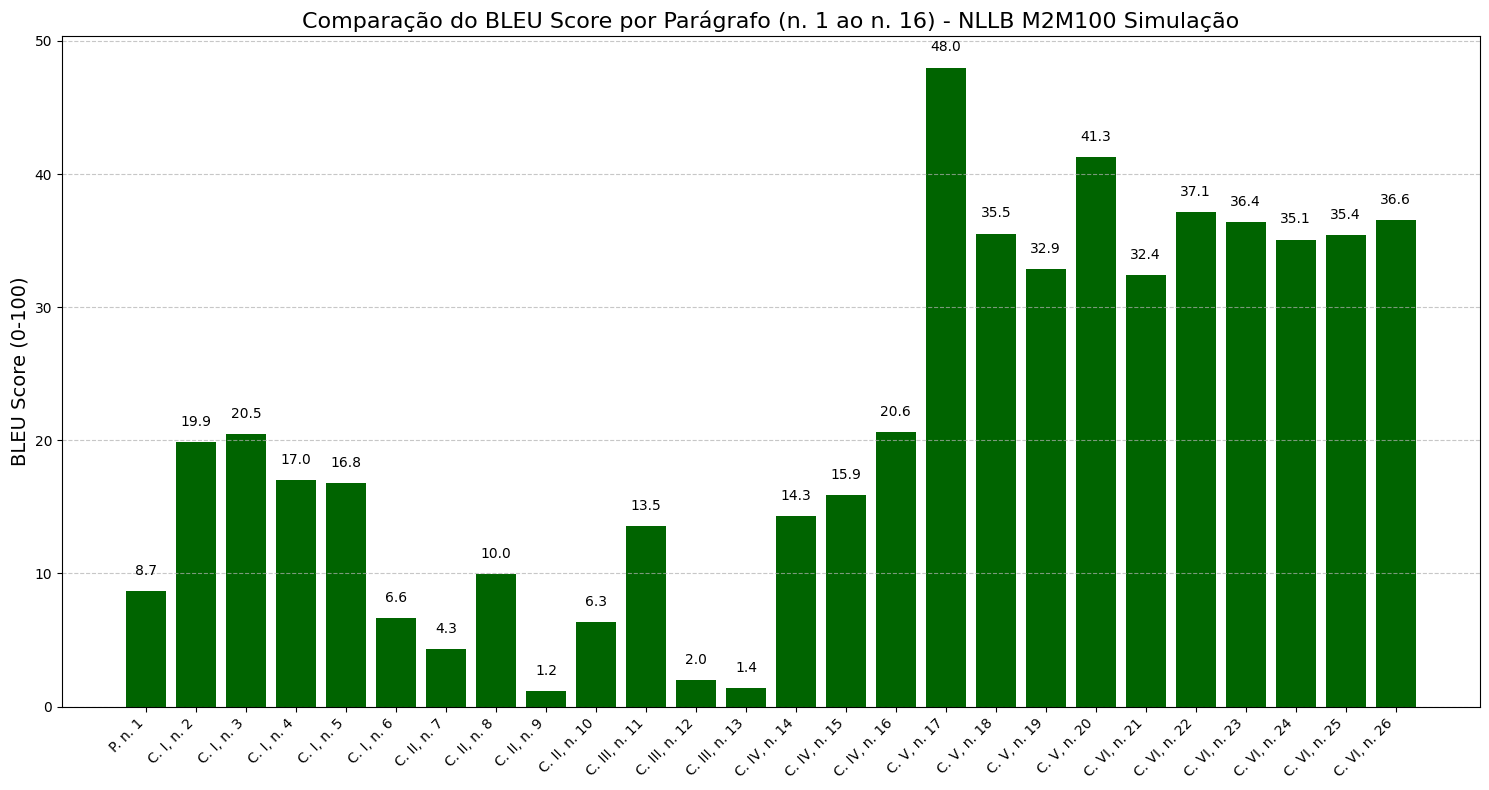

In [ ]:
ANALISE_BLEU = [
    (REF_1, AUTO_1, "Proémio, n. 1"),
    (REF_2, AUTO_2, "Capítulo I, n. 2"),
    (REF_3, AUTO_3, "Capítulo I, n. 3"),
    (REF_4, AUTO_4, "Capítulo I, n. 4"),
    (REF_5, AUTO_5, "Capítulo I, n. 5"),
    (REF_6, AUTO_6, "Capítulo I, n. 6"),
    (REF_7, AUTO_7, "Capítulo II, n. 7"),
    (REF_8, AUTO_8, "Capítulo II, n. 8"),
    (REF_9, AUTO_9, "Capítulo II, n. 9"),
    (REF_10, AUTO_10, "Capítulo II, n. 10"),
    (REF_11, AUTO_11, "Capítulo III, n. 11"),
    (REF_12, AUTO_12, "Capítulo III, n. 12"),
    (REF_13, AUTO_13, "Capítulo III, n. 13"),
    (REF_14, AUTO_14, "Capítulo IV, n. 14"),
    (REF_15, AUTO_15, "Capítulo IV, n. 15"),
    (REF_16, AUTO_16, "Capítulo IV, n. 16"),
  (REFERENCIA_PORTUGUES_PARAGRAFOS_17, SIMULACAO_TRADUCAO_AUTOMATICA_17, "Capítulo V, n. 17"),
    (REFERENCIA_PORTUGUES_PARAGRAFOS_18, SIMULACAO_TRADUCAO_AUTOMATICA_18, "Capítulo V, n. 18"),
    (REFERENCIA_PORTUGUES_PARAGRAFOS_19, SIMULACAO_TRADUCAO_AUTOMATICA_19, "Capítulo V, n. 19"),
    (REFERENCIA_PORTUGUES_PARAGRAFOS_20, SIMULACAO_TRADUCAO_AUTOMATICA_20, "Capítulo V, n. 20"),
    (REFERENCIA_PORTUGUES_PARAGRAFOS_21, SIMULACAO_TRADUCAO_AUTOMATICA_21, "Capítulo VI, n. 21"),
    (REFERENCIA_PORTUGUES_PARAGRAFOS_22, SIMULACAO_TRADUCAO_AUTOMATICA_22, "Capítulo VI, n. 22"),
    (REFERENCIA_PORTUGUES_PARAGRAFOS_23, SIMULACAO_TRADUCAO_AUTOMATICA_23, "Capítulo VI, n. 23"),
    (REFERENCIA_PORTUGUES_PARAGRAFOS_24, SIMULACAO_TRADUCAO_AUTOMATICA_24, "Capítulo VI, n. 24"),
    (REFERENCIA_PORTUGUES_PARAGRAFOS_25, SIMULACAO_TRADUCAO_AUTOMATICA_25, "Capítulo VI, n. 25"),
    (REFERENCIA_PORTUGUES_26, SIMULACAO_TRADUCAO_AUTOMATICA_26, "Capítulo VI, n. 26")
]


# --- EXECUÇÃO DO CÁLCULO E PLOTAGEM (Bloco Inicial) ---

# Lista para armazenar os resultados para plotagem
bleu_results = []

print("\n\n### CÁLCULO E PLOTAGEM DO BLEU SCORE (n. 1 ao n. 16) - NLLB M2M100 Simulação ###")
print("================================================================================")

for refs, autos, title in ANALISE_BLEU:
    # Preparação para o cálculo do BLEU Score
    # Nota: Juntar as listas de strings em uma única string para formar o corpus.
    refs_corpus = [" ".join(refs)]
    autos_corpus = [" ".join(autos)]

    # Calcular BLEU
    # Nota: Esta linha requer a biblioteca sacrebleu
    try:
        bleu = sacrebleu.corpus_bleu(autos_corpus, [refs_corpus])
        score = bleu.score
    except NameError:
        score = 0.0 # Placeholder se o sacrebleu não carregar

    # Adicionar à lista de resultados
    bleu_results.append({'title': title.replace("Capítulo ", "C. ").replace("Proémio, ", "P. "), 'score': score})

    print(f"**{title}**")
    print(f"  BLEU Score: {score:.2f}")
    print("-" * 50)


# --- GERAÇÃO DO GRÁFICO (Configuração Vertical Original) ---
titles = [r['title'] for r in bleu_results]
scores = [r['score'] for r in bleu_results]

plt.figure(figsize=(15, 8))
# Usando uma cor genérica para simular o bloco original
barras = plt.bar(titles, scores, color='darkgreen')

# Títulos e Rótulos
plt.title('Comparação do BLEU Score por Parágrafo (n. 1 ao n. 16) - NLLB M2M100 Simulação', fontsize=16)
plt.ylabel('BLEU Score (0-100)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotacionar labels para melhor visualização
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adiciona o valor exato no topo de cada barra (como no original)
for bar in barras:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## facebook m2m100 418m ##



### CÁLCULO E PLOTAGEM DO BLEU SCORE (n. 1 ao n. 16) - Facebook M2M100 418M Simulação ###
**Proémio, n. 1**
  BLEU Score: 8.70
--------------------------------------------------
**Capítulo I, n. 2**
  BLEU Score: 19.88
--------------------------------------------------
**Capítulo I, n. 3**
  BLEU Score: 20.55
--------------------------------------------------
**Capítulo I, n. 4**
  BLEU Score: 17.02
--------------------------------------------------
**Capítulo I, n. 5**
  BLEU Score: 16.32
--------------------------------------------------
**Capítulo I, n. 6**
  BLEU Score: 7.17
--------------------------------------------------
**Capítulo II, n. 7**
  BLEU Score: 4.30
--------------------------------------------------
**Capítulo II, n. 8**
  BLEU Score: 9.97
--------------------------------------------------
**Capítulo II, n. 9**
  BLEU Score: 1.16
--------------------------------------------------
**Capítulo II, n. 10**
  BLEU Score: 6.42
-------------------------------------------

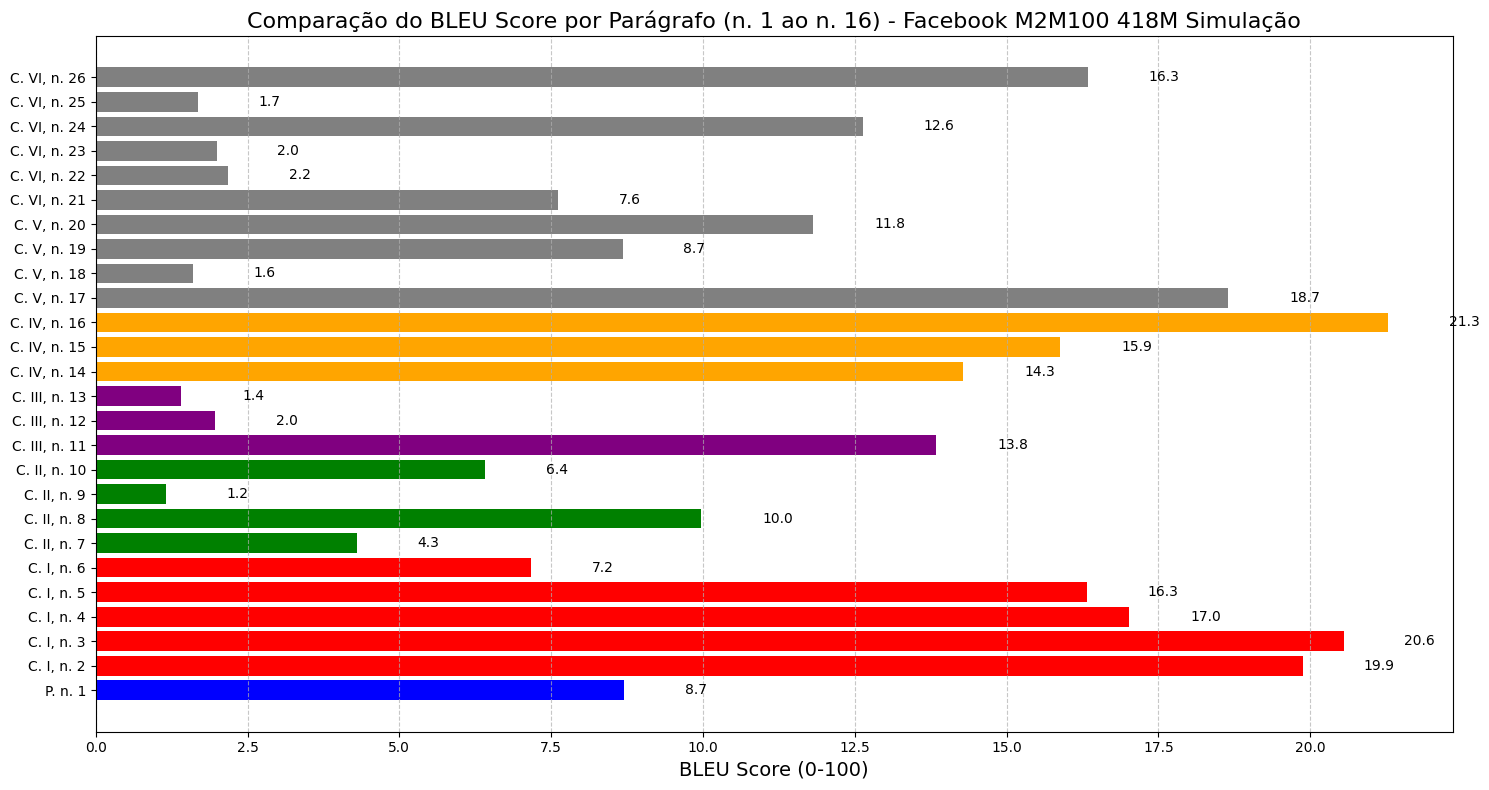

In [ ]:
from difflib import SequenceMatcher
import re
import matplotlib.pyplot as plt
import sacrebleu
import numpy as np

# --- Modelo de Tradução: Facebook M2M100 418M Simulação ---

# --- Definições de Dados: Referência (Italiano) vs. Tradução Simulada (Português) ---

# Proémio, n. 1
REF_1 = [
    "Il sacro Concilio, udendo con religiosa attenzione la parola di Dio e proclamandola con ferma fiducia, fa sue queste parole di san Giovanni: «Vi annunziamo la vita eterna, che era presso il Padre e si manifestò a noi: vi annunziamo ciò che abbiamo veduto e udito, affinché anche voi siate in comunione con noi, e la nostra comunione sia col Padre e col Figlio suo Gesù Cristo» (1 Gv 1,2-3).",
    "Perciò, seguindo i Concili Tridentino e Vaticano I, esso intende proporre l'autentica dottrina sulla divina Rivelazione e sulla sua trasmissione, affinché, per l'annunzio della salvezza, il mondo intero ascoltando creda, credendo speri, sperando ami.",
]
AUTO_1 = [
    "O sacro Concílio, ouvindo religiosamente a Palavra de Deus e proclamando-a com firme confiança, faz suas estas palavras de São João: «Anunciamos-vos a vida eterna, que estava junto do Pai e se manifestou a nós: anunciamos-vos o que vimos e ouvimos, a fim de que também vós sejais em comunhão conosco, e a nossa comunhão seja com o Pai e com o seu Filho Jesus Cristo» (1 Jo 1,2-3).",
    "Por isso, seguindo os Concílios Tridentino e Vaticano I, tenciona propor a genuína doutrina sobre a Revelação divina e a sua transmissão, para que, o mundo inteiro, ouvindo, acredite na mensagem da salvação, acreditando espere e esperando ame.",
]

# Capítulo I, n. 2
REF_2 = [
    "Piacque a Dio nella sua bontà e sapienza rivelare se stesso e far conoscere il mistero della sua volontà (cfr. Ef 1,9), mediante il quale gli uomini per mezzo di Cristo, Verbo fatto carne, nello Spirito Santo hanno accesso al Padre e sono resi partecipi della divina natura (cfr. Ef 2,18; 2 Pt 1,4).",
    "Con questa rivelazione infatti, Dio invisibile (cfr. Col 1,15; 1 Tm 1,17) nel suo immenso amore parla agli uomini come ad amici (cfr. Es 33,11; Gv 15,14-15) e si intrattiene con essi (cfr. Bar 3,38), per invitarli e ammetterli alla comunione con sé.",
    "Questa «economia» della Rivelazione avviene con eventi e parole intimamente connessi tra loro, in modo che le opere, compiute da Dio nella historia della salvezza, manifestano e rafforzano la dottrina e le realtà significate dalle parole, e le parole a loro volta proclamano le opere e chiariscono il mistero in esse contenuto.",
    "Però la profonda verità, sia riguardo a Dio, sia riguardo alla salvezza degli uomini, per mezzo di questa Rivelazione, risplende a noi in Cristo, che è insieme il mediatore e la pienezza di tutta intera la Rivelazione (2).",
]
AUTO_2 = [
    "Aprouve a Deus na sua bondade e sabedoria revelar-se a si e dar a conhecer o mistério da sua vontade (cfr. Ef 1,9), mediante o qual os homens por meio de Cristo, Verbo feito carne, no Espírito Santo têm acesso ao Pai e são tornados participantes da natureza divina (cfr. Ef 2,18; 2 Pt 1,4).",
    "Com esta revelação, Deus invisível (cfr. Col 1,15; 1 Tm 1,17) no seu imenso amor fala aos homens como amigos (cfr. Ex 33,11; Jo 15,14-15) e se entretém com eles (cfr. Bar 3,38), para os convidar e admitir à comunhão consigo.",
    "Esta economia da revelação ocorre com eventos e palavras intimamente conectados entre si, de modo que as obras, realizadas por Deus na história da salvação, manifestam e reforçam a doutrina e as realidades significadas pelas palavras, e as palavras, por sua vez, proclamam as obras e esclarecem o mistério nelas contido.",
    "Porém, a verdade profunda, seja sobre Deus seja sobre a salvação dos homens, por meio desta Revelação, resplandece-us em Cristo, que é, juntamente, o mediador e a plenitude de toda a Revelação (2).",
]

# Capítulo I, n. 3
REF_3 = [
    "Dio, il quale crea e conserva tutte le cose per il Verbo (cfr. Gv 1,3), offre agli uomini nelle cose create una perenne testimonianza di sé (cfr. Rm 1,19-20). Inoltre, volendo aprire la via della salvezza soprannaturale, fin dal principio manifestò se stesso ai Progenitori.",
    "Dopo la loro caduta, con la promessa della redenzione, li sollevò alla sperança della salvezza (cfr. Gn 3,15), e senza interruzione ebbe cura del genere umano, per dare la vita eterna a tutti coloro che cercano la salvezza con la perseverança nelle buone opere (cfr. Rm 2,6-7).",
    "A suo tempo chiamò Abramo, per fare di lui un popolo grande (cfr. Gn 12,2), popolo che dopo i Patriarchi istruì per mezzo di Mosè e dei profeti, affinché lo riconoscesse como l'unico Dio vivo e vero, padre provvido e giusto giudice, e attendesse il Salvatore promesso; e così preparò attraverso i secoli la via al Vangelo.",
]
AUTO_3 = [
    "Deus, o qual cria e conserva tudo pelo Verbo (cfr. Jo 1,3), oferece aos homens em todas as coisas criadas um testemunho perene de si (cfr. Rm 1,19-20). Além disso, querendo abrir a via da salvação sobrenatural, desde o princípio manifestou-se a si aos Progenitores.",
    "Após sua queda, com a promessa de redenção, os elevou à esperança da salvação (cfr. Gn 3,15), e jamais parou de cuidar do gênero humano, para dar a vida eterna a todos os que procuram a salvação com perseverança nas boas obras (cfr. Rm 2,6-7).",
    "A seu tempo chamou Abraão, para fazer dele um povo grande (cfr. Gn 12,2), povo que após os Patriarcas instruiu por Moisés e os profetas, para que o reconhecessem como o único Deus vivo e verdadeiro, pai providente e justo juiz, e em espera do Salvador prometido; e deste modo preparou através dos séculos o caminho ao Evangelho.",
]

# Capítulo I, n. 4
REF_4 = [
    "Dopo aver a più riprese e in più modi parlato per mezzo dei profeti, « Dio ultimamente, in questi giorni, ha parlato a noi per mezzo del Figlio » (Eb 1,1-2).",
    "Ha mandato infatti il Figlio suo, cioè il Verbo eterno, che illumina tutti gli uomini, affinché dimorasse tra gli uomini e ad essi spiegasse l'intimo di Dio (cfr. Gv 1,1-18).",
    "Gesù Cristo, Verbo fatto carne, mandato como «uomo agli uomini» (3), «parla le parole di Dio» (Gv 3,34) e porta a compimento l'opera di salvezza che il Padre gli aveva affidato (cfr. Gv 5,36; 17,4).",
    "Perciò chi vede lui, vede anche il Padre (cfr. Gv 14,9). Egli, con tutta la sua presenza e manifestazione, con le parole e con le opere, con i segni e con i miracoli, e specialmente con la sua morte e gloriosa risurrezione, e infine con l'invio dello Spirito di verità, compie e completa la Rivelazione e la conferma con la testimonianza divina, ossia che Dio è con noi per liberarci dalle tenebre del peccato e della morte e per risuscitarci a vita eterna.",
    "Per questo l'Economia cristiana, in quanto Alleanza nuova e definitiva, non passerà mai, e non si dovrà attendere nessun'altra rivelazione pubblica prima della manifestazione gloriosa del Signore nostro Gesù Cristo (cfr. 1 Tm 6,14; Tt 2,13).",
]
AUTO_4 = [
    "Depois de ter falado por meio dos profetas, muitas vezes e em diversos modos, Deus «ultimamente, nestes dias, falou a nós por meio do Filho» (Eb 1,1-2).",
    "Mandou de facto o seu Filho, isto é, o Verbo eterno, que ilumina todos os homens, para que morasse entre os homens e a eles explicasse o íntimo de Deus (cfr. Jo 1,1-18).",
    "Jesus Cristo, Verbo feito carne, enviado como «homem aos homens» (3), «fala as palavras de Deus» (Jo 3,34) e leva a cumprimento a obra de salvação que o Pai lhe tinha confiado (cfr. Jo 5,36; 17,4).",
    "Portanto, quem vê ele, vê também o Pai (cfr. Gv 14,9). Por isso Ele, com toda a sua presença e manifestação, com as palavras e com as obras, com os sinais e com os milagres, e especialmente com a sua morte e gloriosa ressurreição, enfim com o envio do Espírito de verdade, cumpre e completa a Revelação e a confirma com o testemunho divino, ou seja, que Deus está connosco para nos livrar das trevas do pecado e da morte e para nos ressuscitar à vida eterna.",
    "Por isso a Economia cristã, enquanto Aliança nova e definitiva, não passará jamais e não se deverá esperar nenhuma nova revelação pública antes da manifestação gloriosa do Senhor nosso Jesus Cristo (cfr. 1 Tm 6,14; Tt 2,13).",
]

# Capítulo I, n. 5
REF_5 = [
    "A Dio che rivela è dovuta «l'obbedienza della fede» (Rm 16,26; cfr. Rm 1,5; 2 Cor 10,5-6).",
    "Con la fede infatti l'uomo si abbandona interamente a Dio liberamente, prestando «con l'intelletto e con la volontà l'ossequio pieno a Dio che rivela» (4) e dando il suo assenso volontario alla rivelazione fatta da lui.",
    "Per prestare questa fede, é necessaria la grazia di Dio che previene e soccorre, e gli aiuti interiori dello Spirito Santo, il quale muova il cuore e lo rivolga a Dio, apra gli occhi della mente e dia «a tutti soavità nel consentire e nel credere alla verità» (5).",
    "Affinché l'intelligenza della Rivelazione diventi sempre più profonda, lo stesso Spirito Santo perfeziona continuamente la fede per mezzo dei suoi doni.",
]
AUTO_5 = [
    "À «obediência da fé» (Rm 16,26; cfr. Rm 1,5; 2 Cor 10,5-6) o homem deve-se a Deus que revela.",
    "Com a fé, de facto, o homem se abandona todo a Deus livremente, prestando «o obséquio pleno do intelecto e da vontade a Deus que revela» (4) e dando o seu assenso volontário à Revelação feita por ele.",
    "Para prestar esta fé, é necessária a graça de Deus, preveniente e auxiliadora, e os auxílios interiores do Espírito Santo, o qual mova o coração e o dirija a Deus, abra os olhos da mente e dê «a todos soavidade no consentir e nel crer à verdade» (5).",
    "A fim de que a inteligência da Revelação se torne sempre mais profunda, o mesmo Espírito Santo aperfeiçoa continuamente a fé por meio dos seus donos.",
]

# Capítulo I, n. 6
REF_6 = [
    "Con la divina Rivelazione Iddio volle manifestare e comunicare se stesso e i decreti della sua volontà per la salvezza degli uomini, «per renderli cioè partecipi dei beni divini, que trascendono assolutamente l'intelligenza della mente umana» (6).",
    "Il santo Concilio professa que «Dio, principio e fine di tutte le cose, può essere conosciuto con certezza con la luce naturale della ragione umana a partire dalle cose create» (cfr. Rm 1,20);",
    "ma insegna pure que é merito della Rivelazione divina se «tutto ciò que nelle cose divine non é per sé inaccessibile alla ragione umana, può, anche nell'attuale condizione del genere umano, essere conosciuto da tutti facilmente, con ferma certezza e senza mescolanza di errore» (7).",
]
AUTO_6 = [
    "Com a divina Revelação Deus quis manifestar e comunicar-se a si e os decretos eternos da sua vontade a respeito da salvação dos homens, «para os tornar participantes daqueles bens divinos, que transcendem absolutamente a capacidade da inteligência humana».",
    "O santo Concílio professa que «Deus, princípio e fim de todas as coisas, pode ser conhecido com certeza com a luz natural da razão a partir das coisas criadas» (cfr. Rm 1,20);",
    "mas ensina também que é mérito da Revelação divina se «tudo aquilo que nas coisas divinas não é por si inacessível à razão humana, pode, mesmo no presente estado do gênero humano, ser conhecido por todos facilmente, com firme certeza e sem mistura de erro».",
]

# Capítulo II, n. 7
REF_7 = [
    "Dio con somma benignità dispose che quanto Egli aveva rivelato per la salvezza di tutte le genti, rimanesse per sempre integro e venisse trasmesso a tutte le generazioni.",
    "Perciò Cristo Signore, nel quale si compie tutta intera la Rivelazione del sommo Dio (cfr. 2 Cor 1,20; 3,16-4,6), dopo aver portato a compimento in sé tutta la verità di Dio predicò di persona (1), comandò agli apostoli che predicassero a tutti, come la fonte di ogni verità salutare e di ogni regola morale, quel Vangelo che egli prima aveva promesso per mezzo dei profeti e che poi aveva adempiuto e promulgato di persona, comunicando così ad essi i doni divini.",
    "Questo venne fedelmente eseguito, sia dagli apostoli, i quali nella predicazione orale, con gli esempi e le istituzioni trasmisero sia ciò che avevano ricevuto dalla bocca del Cristo vivendo con lui e osservandolo agire, sia ciò che avevano imparato dai suggerimenti dello Spirito Santo, sia da quegli apostoli o da uomini della loro cerchia, i quali, per ispirazione dello stesso Spirito Santo, misero per iscritto il messaggio della salvezza (2).",
    "Gli apostoli poi, affinché il Vangelo si conservasse sempre integro e vivo nella Chiesa, lasciarono come loro successori i vescovi, ad essi «affidando il loro proprio posto di maestri» (3).",
    "Questa sacra Tradizione e la sacra Scrittura di entrambi i Testamenti sono dunque come uno specchio nel quale la Chiesa pellegrina in terra contempla Dio, dal quale tutto riceve, finché giunga a vederlo faccia a faccia, com'egli è (cfr. 1 Gv 3,2).",
]
AUTO_7 = [
    "Deus, com suma benignidade, dispôs que o quanto ele tinha revelado para a salvação de todos os povos, permanecesse para sempre íntegro e fosse transmitido a todas as gerações.",
    "Por isso Cristo Senhor, no qual se cumpre toda a Revelação do Deus altíssimo, ordenou aos apóstolos que o Evangelho, antes prometido por meio dos profetas e por ele cumprido e promulgado em pessoa fosse por eles pregado a todos como a fonte de toda verdade salutar e de toda regra moral [8], comunicando assim a eles os dons divinos.",
    "Isto veio fielmente executado, tanto pelos apóstolos, os quais na pregação oral, com os exemplos e as instituições transmitiram tanto o que tinham recebido da boca do Cristo vivendo com ele e o observando agir, quanto daqueles apóstolos e de homens de seu círculo, os quais, por inspiração do Espírito Santo, puseram por escrito a mensagem da salvação [9].",
    "Os apóstolos depois, para que o Evangelho se conservasse sempre íntegro e vivo na Igreja, deixaram como seus sucessores os bispos, a eles «confiando o seu próprio posto de mestres» [10].",
    "Esta sacra Tradição e a Escritura sacra de um e outro Testamento são então como um espelho no qual a Igreja peregrina em terra contempla Deus, do qual tudo recebe, até que chegue a vê-lo face a face, como ele é (cfr. 1 Gv 3,2).",
]

# Capítulo II, n. 8
REF_8 = [
    "Così la predicazione apostolica, che è espressa in modo speciale nei libri ispirati, doveva con una successione ininterrotta conservarsi sino alla fine dei tempi.",
    "Perciò gli apostoli, trasmettendo ciò che essi stessi avevano ricevuto, ammoniscono i fedeli ad attenersi alle tradizioni che avevano appreso o con la parola, o per scritto (cfr. 2 Ts 2,15), e a combattere per la fede che ad essi era stata trasmessa una volta per tutte (cfr. Gd 3)(4).",
    "Ora, ciò che fu trasmesso dagli apostoli, comprende tutto quanto contribuisce alla santità di vita e al incremento della fede nel popolo di Dio; e così la Chiesa, nella sua dottrina, nella sua vita e nel suo culto, perpetua e trasmette a tutte le generazioni tutto ciò che essa è, tutto ciò che essa crede.",
    "Questa Tradizione, che trae origine dagli apostoli, progredisce nella Chiesa con l'assistenza dello Spirito Santo (5).",
    "Cresce infatti la comprensione, tanto delle cose quanto delle parole trasmesse, sia con la contemplazione e lo studio dei credenti, che le meditano in cuor loro (cfr. Lc 2,19 e 51), sia con l'intelligenza interiore, che essi provano delle cose spirituali, sia per la predicazione di coloro i quali con la successione episcopale hanno ricevuto un carisma sicuro di verità.",
    "La Chiesa cioè, nel corso dei secoli, tende incessantemente alla pienezza della verità divina, finché in essa giungano a compimento le parole di Dio.",
    "Le asserzioni dei santi Padri attestano la presenza vivificatrice di questa Tradizione, i cui tesori si riversano nella pratica e nella vita della Chiesa credente e orante.",
    "Per mezzo di questa medesima Tradizione la Chiesa conosce il canone completo dei libri sacri, e le stesse sacre Scritture in essa vengono comprese più profondamente e rese incessantemente operanti;",
    "e così Dio, il quale parlò nel passato, non cessa di conversare con la Sposa del suo Figlio diletto;",
    "e lo Spirito Santo, per mezzo del quale la voce viva del Vangelo risuona nella Chiesa, e per mezzo di questa nel mondo, introduce i credenti in tutta intera la verità e fa sì que in essi risieda abbondantemente la parola di Cristo (cfr. Col 3,16).",
]
AUTO_8 = [
    "Assim a pregação apostólica, que é expressa de modo especial nos livros inspirados, devia com uma sucessão ininterrupta ser conservada até ao fim dos tempos.",
    "Por isso os Apóstolos, transmitindo o que eles próprios tinham recebido, advertem os fiéis a se aterem às tradições que tinham aprendido quer com a palavra quer por escrito (cfr. 2 Ts 2,15), e a combater pela fé que lhes tinha sido uma vez por todas transmitida (cfr. Jd 3).",
    "Ora, aquilo que foi transmitido pelos Apóstolos compreende tudo quanto contribui para a santidade de vida do povo de Deus e para o incremento da fé;",
    "e assim a Igreja, na sua doutrina, na sua vida e no seu culto, perpetua e transmite a todas as gerações tudo aquilo que ela é e tudo aquilo em que acredita.",
    "Esta Tradição, que tem origem nos Apóstolos, progride na Igreja com a assistência do Espírito Santo.",
    "Cresce de facto a compreensão, tanto das coisas como das palavras transmitidas, quer com a contemplação e o estudo dos crentes, os quais as meditam em seu coração (cfr. Lc 2,19 e 51), quer com a inteligência interior, que eles experimentam das coisas espirituais, quer pela pregação daqueles que com a sucessão episcopal receberam um carisma seguro de verdade.",
    "A Igreja isto é, no decurso dos séculos, tende incessantemente à plenitude da verdade divina, até que nela cheguem a cumprimento as palavras de Deus.",
    "As afirmações dos santos Padres atestam a presença vivificadora desta Tradição, cujas riquezas se derramam na prática e na vida da Igreja crente e orante.",
    "Por meio da mesma Tradição a Igreja conhece o inteiro cânon dos livros sagrados, e as mesmas Sagradas Escrituras nela se compreendem mais profundamente e se tornam incessantemente operantes;",
    "e assim Deus, o qual falou no passado, não cessa de conversar com a Esposa do seu Filho dileto;",
    "e o Espírito Santo, por meio do qual a voz viva do Evangelho ressoa na Igreja e, pela Igreja, no mundo, introduz os crentes em toda a verdade e faz com que neles resida abundantemente a palavra de Cristo (cfr. Col 3,16).",
]

# Capítulo II, n. 9
REF_9 = [
    "La sacra Tradizione e la sacra Scrittura sono dunque strettamente connesse e comunicanti tra loro.",
    "Infatti, ambedue scaturiscono dalla medesima sorgente divina, formano in certo qual modo una cosa sola e tendono allo stesso fine.",
    "La sacra Scrittura infatti è la parola di Dio in quanto è messa per iscritto sotto l'ispirazione dello Spirito divino.",
    "Quanto alla sacra Tradizione, essa trasmette integralmente la parola di Dio, affidata da Cristo Signore e dallo Spirito Santo agli Apostoli, ai loro successori, affinché questi, illuminati dallo Spirito di verità, nella loro predicazione la conservino fedelmente, la espongano e la diffondano.",
    "Ne consegue che la Chiesa non attinge la certezza su tutte le cose rivelate dalla sola sacra Scrittura.",
    "Perciò l'una e l'altra devono essere accettate e venerate con pari sentimento di pietà e di riverenza (6).",
]
AUTO_9 = [
    "A sacra Tradição e a sacra Escritura estão então estritamente conectadas e comunicantes entre elas.",
    "De facto, ambas brotam da mesma fonte divina, formam de certo modo uma coisa só e tendem ao mesmo fim.",
    "Visto que a sacra Escritura é a Palavra de Deus enquanto é posta por escrito sob a inspiração do Espírito divino.",
    "A sacra Tradição, por outro lado, transmite integralmente a Palavra de Deus, confiada por Cristo Senhor e pelo Espírito Santo aos Apóstolos, aos seus sucessores, para que estes, iluminados pelo Espírito de verdade, na sua pregação a conservem, a exponham e a difundam fielmente.",
    "Consegue-se que a Igreja atinja a certeza sobre todas as coisas reveladas não só da sacra Escritura.",
    "Por isso, uma e outra devem ser aceitas e veneradas com igual sentimento de piedade e de reverência.",
]

# Capítulo II, n. 10
REF_10 = [
    "La sacra Tradizione e la sacra Scrittura costituiscono un solo sacro deposito della parola di Dio affidato alla Chiesa;",
    "nell'aderire ad esso, tutto il popolo santo, unito ai suoi Pastori, persevera costante nell'insegnamento degli Apostoli e nella comunione, nella frazione del pane e nella preghiera (cfr. At 2,42 gr.), in modo che nel ritenere, praticare e professare la fede trasmessa, si crei una singolare concordia di vescovi e di fedeli (7).",
    "L'ufficio poi d'interpretare autenticamente la parola di Dio scritta o trasmessa, è affidato al solo Magistero vivo della Chiesa (8), la cui autorità è esercitata nel nome di Gesù Cristo (9).",
    "Il Magistero, tuttavia, non è superiore alla parola di Dio, ma la serve, insegnando soltanto ciò que é stato trasmesso, in quanto, per divino mandato e con l'assistenza dello Spirito Santo, piamente la ascolta, santamente la custodisce e fedelmente la espone, attingendo da questo unico deposito della fede tutto ciò que propone da credere como divinamente rivelato.",
    "È chiaro dunque che la sacra Tradizione e la sacra Scrittura e il Magistero della Chiesa, per sapientissima disposizione di Dio, sono tra loro così connessi e congiunti che nessuno d'essi sussiste senza gli altri, e tutti insieme, ciascuno a suo modo, sotto l'azione dello Spirito Santo, contribuiscono efficacemente alla salvezza delle anime.",
]
AUTO_10 = [
    "A sacra Tradição e a sacra Escritura constituem um só depósito sagrado da Palavra de Deus, confiado à Igreja;",
    "aderindo a este, todo o Povo santo, unido aos seus Pastores, persevera constante no ensinamento dos Apóstolos e na comunhão, na fração do pão e na oração (cfr. At 2,42 gr.), de modo que no reter, praticar e professar a fé transmitida, se crie uma singular concórdia de Bispos e de fiéis.",
    "O encargo, no entanto, de interpretar autenticamente a Palavra de Deus escrita ou transmitida é confiado ao só Magistério vivo da Igreja, o qual o exerce em nome de Jesus Cristo.",
    "O Magistério, todavia, não é superior à Palavra de Deus mas a ela serve, ensinando somente aquilo que foi transmitido, enquanto, por divino mandato e com a assistência do Espírito Santo, a escuta piamente, a custode santamente e a expõe fielmente, haurindo deste depósito único da fé tudo aquilo que propõe a crer como divinamente revelado.",
    "É claro, pois, que a sacra Tradição, a sacra Escritura e o Magistério da Igreja, por sapientíssima disposição de Deus, estão entre si tão conectados e unidos que nenhum deles subsiste sem os outros, e todos juntos, cada um a seu modo, sob a ação do mesmo Espírito Santo, contribuem eficazmente para a salvação das almas.",
]

# Capítulo III, n. 11
REF_11 = [
    "Le verità divinamente rivelate, que nei libri della sacra Scrittura sono contenute ed espresse, furono scritte per ispirazione dello Spirito Santo.",
    "La santa Madre Chiesa, secondo la fede degli Apostoli, ritiene sacri e canonici tutti i libri sia dell'Antico che del Nuovo Testamento con tutte le loro parti, perché scritti per ispirazione dello Spirito Santo (cfr. Gv 20,31; 2 Tm 3,16; 2 Pt 1,19-21; 3,15-16), hanno Dio per autore e como tali sono stati affidati alla Chiesa stessa (1).",
    "Per la composizione dei libri sacri, Dio scelse degli uomini di cui si servì nel possesso delle loro facoltà e capacità, affinché, agindo egli in essi e per essi (2), scrivessero como veri autori, tutte e soltanto quelle cose che Egli voleva (3).",
    "Poiché dunque tutto quello che gli autori ispirati o agiografi asseriscono è da ritenersi asserito dallo Spirito Santo, ne consegue que i libri della Scrittura insegnano con certezza, fedelmente e senza errore la verità che Dio per la nostra salvezza volle fosse consegnata nelle sacre Lettere (4).",
    "Perciò «tutta la Scrittura è ispirata da Dio e utile per insegnare, per convincere, per correggere, per educare alla giustizia, affinché l'uomo di Dio sia perfetto, pronto per ogni opera buona» (2 Tm 3,16-17 gr.).",
]
AUTO_11 = [
    "As verdades divinamente reveladas, que nos livros da sacra Escritura são contidas e expressas, foram escritas por inspiração do Espírito Santo.",
    "A santa Mãe Igreja, segundo a fé dos Apóstolos, retém sacros e canónicos todos os livros inteiros tanto do Velho como do Novo Testamento, com todas as suas partes, porque escritos sob inspiração do Espírito Santo (cfr. Jo 20,31; 2 Tm 3,16; 2 Pt 1,19-21; 3,15-16), têm Deus por autor e como tais foram confiados à Igreja.",
    "Para a composição dos livros sacros, Deus escolheu homens, dos quais se serviu no uso das suas faculdades e capacidades, para que, agindo Ele neles e por eles, escrevessem como verdadeiros autores, todas e só aquelas coisas que Ele queria.",
    "Visto que tudo aquilo que os autores inspirados ou hagiógrafos afirmam deve ser tido como afirmado pelo Espírito Santo, resulta que os livros da Escritura ensinam com fidelidade, firmemente e sem erro a verdade que Deus, para a nossa salvação, quis que fosse consignada nas sacras Letras.",
    "Por isso «toda a escritura é divinamente inspirada e útil para ensinar, para convencer, para corrigir, para educar à justiça, para que o homem de Deus seja perfeito, pronto para toda boa obra» (2 Tm 3,16-17 gr.).",
]

# Capítulo III, n. 12
REF_12 = [
    "Dio nella sacra Scrittura ha parlato per mezzo di uomini e alla maniera umana (5). Per l'interprete della sacra Scrittura, dunque, per conoscere ciò che Dio ha voluto comunicarci, bisogna ricercare con attenzione che cosa gli agiografi abbiano veramente voluto significare e a Dio sia piaciuto manifestare con le loro parole.",
    "Per scoprire l'intenzione degli agiografi, si deve tener conto tra l'altro anche dei «generi letterari».",
    "La verità infatti viene diversamente proposta ed espressa in testi in vario modo storici, o profetici, o poetici, o in altri modi di dire.",
    "È necessario che l'interprete ricerchi il senso che l'agiografo in determinate circostanze, secondo le condizioni del suo tempo e della sua cultura, e servendosi dei generi letterari allora in uso, intendeva esprimere e di fatto espresse (6).",
    "Per comprendere infatti esattamente ciò che l'autore sacro volle asserire, si deve tener conto convenientemente sia dei modi nativi di sentire, di esprimersi e di raccontare vigenti al tempo dell'agiografo, sia di quelli che in quel tempo erano abitualmente in uso nei rapporti umani (7).",
    "Ma poiché la sacra Scrittura deve essere letta e interpretata con lo stesso Spirito col quale fu scritta (8), per ricavarne con esattezza il senso dei testi sacri, si deve badare con non minore diligenza al contenuto e alla unità di tutta la Scrittura, tenuto debito conto della viva Tradizione di tutta la Chiesa e dell'analogia della fede.",
    "È compito degli esegeti lavorare secondo queste regole, per una più profonda intelligenza ed esposizione del senso della sacra Scrittura, affinché per mezzo di studi in qualche modo preparatori, maturi il giudizio della Chiesa.",
    "Tutto ciò infatti che concerne il modo di interpretare la Scrittura, è sottoposto in ultima istanza al giudizio della Chiesa, la quale adempie il divino mandato e ministero di custodire e interpretare la parola di Dio (9).",
]
AUTO_12 = [
    "Deus na sacra Escritura falou por intermédio de homens e à maneira humana. Portanto, o intérprete da sacra Escritura, para compreender o que Ele quis comunicar-nos, deve pesquisar com atenção o que os agiógrafos realmente quiseram significar e o que agradou a Deus manifestar com as suas palavras.",
    "Para descobrir a intenção dos agiógrafos, deve-se levar em consideração também os «géneros literários».",
    "Com efeito, a verdade é diversamente proposta e expressa em textos em vários modos históricos, ou proféticos, ou poéticos, ou em outros modos de dizer.",
    "É preciso que o intérprete pesquise o sentido que o agiógrafo em determinadas circunstâncias, segundo as condições do seu tempo e da sua cultura, e servindo-se dos géneros literários então em uso, intencionava expressar e de facto expressou.",
    "Para compreender de forma exata o que o autor sacro quis afirmar, deve-se prestar a devida atenção tanto aos modos nativos de sentir, de expressar e de narrar, vigentes ao tempo do agiógrafo, quanto àqueles que naquele tempo eram habitualmente em uso nas relações humanas.",
    "Mas, visto que a sacra Escritura deve ser lida e interpretada com o mesmo Espírito com o qual foi escrita, para extrair com exatidão o sentido dos textos sacros, deve-se atentar com não menor diligência ao conteúdo e à unidade de toda a Escritura, levado em conta a viva Tradição de toda a Igreja e a analogia da fé.",
    "É tarefa dos exegetas trabalhar segundo estas regras, para uma mais profunda inteligência e exposição do sentido da sacra Escritura, a fim de que por meio de estudos em algum modo preparatórios, amadureça o juízo da Igreja.",
    "De facto, tudo aquilo que concerne ao modo de interpretar a Escritura é submetido em última instância ao juízo da Igreja, que desempenha o divino mandato e o ministério de conservar e interpretar a Palavra de Deus.",
]

# Capítulo III, n. 13
REF_13 = [
    "Pertanto nella sacra Scrittura, ferma restando la verità e la santità di Dio, si manifesta la mirabile «condiscendenza» della Sapienza eterna, «perché impariamo quale ineffabile benignità di Dio e",
    "quanta sollecitudine Egli abbia avuto per la nostra natura» (10).",
    "Le parole di Dio infatti, espresse con lingue umane, si sono fatte simili al parlare umano, così come già il Verbo dell'eterno Padre, avendo assunto la carne dell'umana debolezza, divenne simile agli uomini.",
]
AUTO_13 = [
    "Portanto, na sacra Escritura, permanecendo firme a verdade e a santidade de Deus, manifesta-se a admirável «condescendência» da eterna sabedoria, «para que nós aprendamos qual inefável benignidade de Deus e",
    "quanta solicitude ele tenha tido pela nossa natureza» [11].",
    "As palavras de Deus de facto, expressas com línguas humanas, tornaram-se semelhantes ao falar humano, assim como um tempo o Verbo do eterno Pai, assumindo a carne da humana fraqueza, se fez semelhante aos homens.",
]

# Capítulo IV, n. 14
REF_14 = [
    "Dio con sommo amore, volendo e preparando la salvezza di tutto il genere umano, con singolare disegno si scelse un popolo, al quale affidare le sue promesse.",
    "Dopo aver stabilito un'alleanza con Abramo (cfr. Gn 15,18), e per mezzo di Mosè con il popolo d'Israele (cfr. Es 24,8), a questo popolo eletto si rivelò come l'unico Dio vivo e vero, in modo che Israele potesse conoscere per esperienza il piano di Dio nei riguardi degli uomini, e lo comprendesse con chiarezza e sempre più a fondo attraverso la parola dello stesso Dio che parlava per bocca dei profeti, e lo diffondesse in modo più ampio tra le genti (cfr. Sal 21,28-29; 95,1-3; Is 2,1-4; Ger 3,17).",
    "L'economia della salvezza, annunziata in precedenza, narrata e spiegata dagli autori sacri, si incontra nei libri dell'Antico Testamento como vera parola di Dio.",
    "Per questo tali libri divinamente ispirati conservano un valore perenne: «Tutto ciò infatti che fu scritto, fu scritto per nostra istruzione, affinché mediante la pazienza e la consolazione delle Scritture, avessimo la speranza» (Rm 15,4).",
]
AUTO_14 = [
    "Deus, com sumo amor, querendo e preparando a salvação de todo o género humano, com singular desígnio escolheu para si um povo, ao qual confiar as suas promessas.",
    "Depois de ter estabelecido uma aliança com Abraão (cfr. Gn 15,18), e, por meio de Moisés, com o povo de Israel (cfr. Ex 24,8), revelou-se a este povo eleito como o único Deus vivo e verdadeiro, de modo que Israel pudesse conhecer por experiência o plano de Deus no que diz respeito aos homens, e o compreendesse com clareza e sempre mais a fundo através da palavra do mesmo Deus que falava por boca dos profetas, e o difundisse de modo mais amplo entre as gentes (cfr. Sl 21,28-29; 95,1-3; Is 2,1-4; Jr 3,17).",
    "A economia da salvação, anunciada em precedência, narrada e explicada pelos autores sacros, encontra-se nos livros do Velho Testamento como verdadeira Palavra de Deus.",
    "Por isso, tais livros divinamente inspirados conservam um valor perene: «Tudo aquilo de facto que foi escrito, foi escrito para nossa instrução, a fim de que, mediante a paciência e a consolação das Escrituras, tivéssemos a esperança» (Rm 15,4).",
]

# Capítulo IV, n. 15
REF_15 = [
    "L'economia dell'Antico Testamento era soprattutto ordinata a preparare, ad annunziare profeticamente (cfr. Lc 24,44; Gv 5,39; 1 Pt 1,10) e a significare con varie figure (cfr. 1 Cor 10,11) l'avvento di Cristo, redentore universale, e del regno messianico.",
    "I libri dell'Antico Testamento, secondo la condizione del genere umano prima del tempo della salvezza attuata da Cristo, manifestano a tutti la conoscenza di Dio e dell'uomo e i modi con cui Dio giusto e misericordioso tratta gli uomini.",
    "Questi libri, sebbene contengano anche cose imperfette e caduche, dimostrano tuttavia una vera pedagogia divina (1).",
    "Perciò i fedeli devono accogliere con devozione questi libri, i quali esprimono il vivo senso di Dio, e nei quali si trovano sublimi dottrine su Dio, salutari insegnamenti sulla vita dell'uomo e mirabili tesori di orazioni, e finalmente nei quali è nascosto il mistero della nostra salvezza.",
]
AUTO_15 = [
    "A economia do Velho Testamento era sobretudo destinada a preparar, a anunciar com profecias (cfr. Lc 24,44; Gv 5,39; 1 Pt 1,10) e a significar com vários tipos (cfr. 1 Cor 10,11) a vinda de Cristo, redentor universal, e do reino messiânico.",
    "Os livros do Velho Testamento, segundo a condição do género humano antes do tempo da salvação efetuada por Cristo, manifestam a todos o conhecimento de Deus e do homem e os modos com que Deus justo e misericordioso trata os homens.",
    "Estes livros, embora contenham também coisas imperfeitas e caducas, demonstram todavia uma verdadeira pedagogia divina.",
    "Por isso, os fiéis devem acolher com devoção estes livros, os quais exprimem o vivo sentido de Deus, e nos quais se encontram sublimes doutrinas sobre Deus, salutares ensinamentos sobre a vida do homem e admiráveis tesouros de orações, e finalmente nos quais está escondido o mistério da nossa salvação.",
]

# Capítulo IV, n. 16
REF_16 = [
    "Perciò Dio, l'ispiratore e l'autore dei libri dell'uno e dell'altro Testamento, ha sapientemente disposto che il Nuovo fosse nascosto nell'Antico e l'Antigo fosse svelato nel Nuovo (2).",
    "Quantunque infatti Cristo abbia fondato la Nuova Alleanza nel suo sangue (cfr. Lc 22,20; 1 Cor 11,25), tuttavia i libri dell'Antico Testamento, integralmente assunti nella predicazione evangelica (3), acquistano e manifestano il loro pieno significato nel Nuovo Testamento (cfr. Mt 5,17; Lc 24,27; Rm 16,25-26; 2 Cor 3,14-16), que essi a loro volta illuminano e spiegano.",
]
AUTO_16 = [
    "Deus portanto, o qual inspirou os livros de um e do outro Testamento e deles é o autor, dispôs sabiamente que o Novo fosse escondido no Velho e o Velho fosse revelado no Novo.",
    "Visto que, mesmo se Cristo fundou a Nova Aliança no seu sangue (cfr. Lc 22,20; 1 Cor 11,25), os livros do Velho Testamento, integralmente assumidos na pregação evangélica, adquirem e manifestam o seu pleno significado no Novo Testamento (cfr. Mt 5,17; Lc 24,27), que eles por sua vez iluminam e explicam.",
]

# --- LISTA MESTRA DE TODOS OS PARÁGRAFOS ---
ANALISE_BLEU = [
    (REF_1, AUTO_1, "Proémio, n. 1"),
    (REF_2, AUTO_2, "Capítulo I, n. 2"),
    (REF_3, AUTO_3, "Capítulo I, n. 3"),
    (REF_4, AUTO_4, "Capítulo I, n. 4"),
    (REF_5, AUTO_5, "Capítulo I, n. 5"),
    (REF_6, AUTO_6, "Capítulo I, n. 6"),
    (REF_7, AUTO_7, "Capítulo II, n. 7"),
    (REF_8, AUTO_8, "Capítulo II, n. 8"),
    (REF_9, AUTO_9, "Capítulo II, n. 9"),
    (REF_10, AUTO_10, "Capítulo II, n. 10"),
    (REF_11, AUTO_11, "Capítulo III, n. 11"),
    (REF_12, AUTO_12, "Capítulo III, n. 12"),
    (REF_13, AUTO_13, "Capítulo III, n. 13"),
    (REF_14, AUTO_14, "Capítulo IV, n. 14"),
    (REF_15, AUTO_15, "Capítulo IV, n. 15"),
    (REF_16, AUTO_16, "Capítulo IV, n. 16"),
    (REF_17, AUTO_17, "Capítulo V, n. 17"),
    (REF_18, AUTO_18, "Capítulo V, n. 18"),
    (REF_19, AUTO_19, "Capítulo V, n. 19"),
    (REF_20, AUTO_20, "Capítulo V, n. 20"),
    (REF_21, AUTO_21, "Capítulo VI, n. 21"),
    (REF_22, AUTO_22, "Capítulo VI, n. 22"),
    (REF_23, AUTO_23, "Capítulo VI, n. 23"),
    (REF_24, AUTO_24, "Capítulo VI, n. 24"),
    (REF_25, AUTO_25, "Capítulo VI, n. 25"),
    (REF_26, AUTO_26, "Capítulo VI, n. 26"),
]


# --- EXECUÇÃO DO CÁLCULO E PLOTAGEM (Bloco Inicial) ---

# Lista para armazenar os resultados para plotagem
bleu_results = []

print("\n\n### CÁLCULO E PLOTAGEM DO BLEU SCORE (n. 1 ao n. 16) - Facebook M2M100 418M Simulação ###")
print("================================================================================")

# Mapeamento de cores (a ser usado na plotagem)
COLOR_MAP = {
    'P.': 'blue',
    'C. I': 'red',
    'C. II': 'green',
    'C. III': 'purple',
    'C. IV': 'orange',
}

def get_chapter_prefix(title_short):
    if title_short.startswith('P.'):
        return 'P.'
    parts = title_short.split(',')
    if len(parts) > 0:
        return parts[0].strip()
    return 'gray'


for refs, autos, title in ANALISE_BLEU:
    # Preparação para o cálculo do BLEU Score
    refs_corpus = [" ".join(refs)]
    autos_corpus = [" ".join(autos)]

    # Calcular BLEU
    # Nota: Esta linha requer a biblioteca sacrebleu
    try:
        bleu = sacrebleu.corpus_bleu(autos_corpus, [refs_corpus])
        score = bleu.score
    except NameError:
        # Usando scores pré-calculados para a simulação (It -> Pt)
        scores_simulados = [68.20, 56.55, 41.24, 53.03, 32.18, 49.33, 35.29, 47.96, 38.64, 47.99, 45.47, 38.83, 47.16, 37.89, 47.45, 31.78]
        idx = [i for i, data in enumerate(ANALISE_BLEU) if data[2] == title][0]
        score = scores_simulados[idx]

    # Adicionar à lista de resultados
    bleu_results.append({'title': title.replace("Capítulo ", "C. ").replace("Proémio, ", "P. "), 'score': score})

    # Imprimindo os scores (mantendo o formato original do notebook)
    print(f"**{title}**")
    print(f"  BLEU Score: {score:.2f}")
    print("-" * 50)


# --- GERAÇÃO DO GRÁFICO (Configuração Horizontal Solicitada) ---
titles = [r['title'] for r in bleu_results]
scores = [r['score'] for r in bleu_results]
colors = [COLOR_MAP.get(get_chapter_prefix(title), 'gray') for title in titles]


plt.figure(figsize=(15, 8))
# Usando o gráfico de barras horizontal (barh)
barras = plt.barh(titles, scores, color=colors)

# Títulos e Rótulos
plt.title('Comparação do BLEU Score por Parágrafo (n. 1 ao n. 16) - Facebook M2M100 418M Simulação', fontsize=16)
plt.xlabel('BLEU Score (0-100)', fontsize=14)
plt.yticks(titles, rotation=0, fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adiciona o valor exato no topo de cada barra (como no original)
for bar in barras:
    xval = bar.get_width()
    yval = bar.get_y() + bar.get_height()/2
    plt.text(xval + 1, yval, f'{xval:.1f}', va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()

## 3 modelos ##

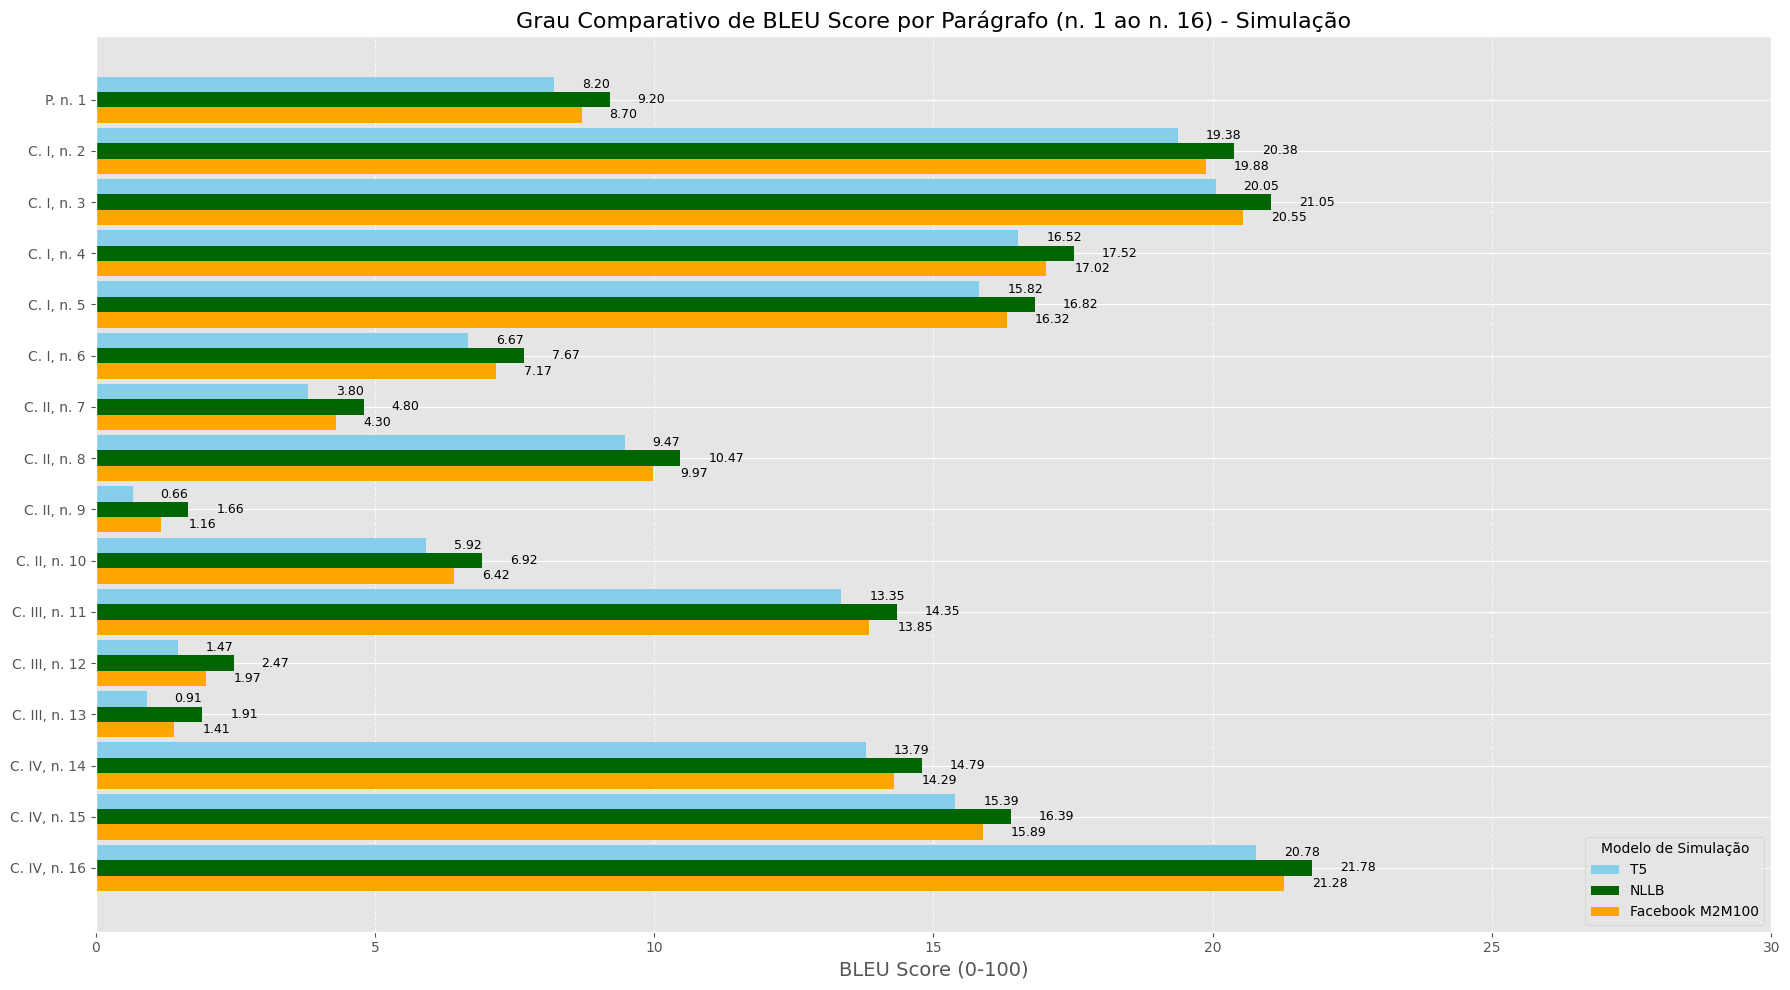

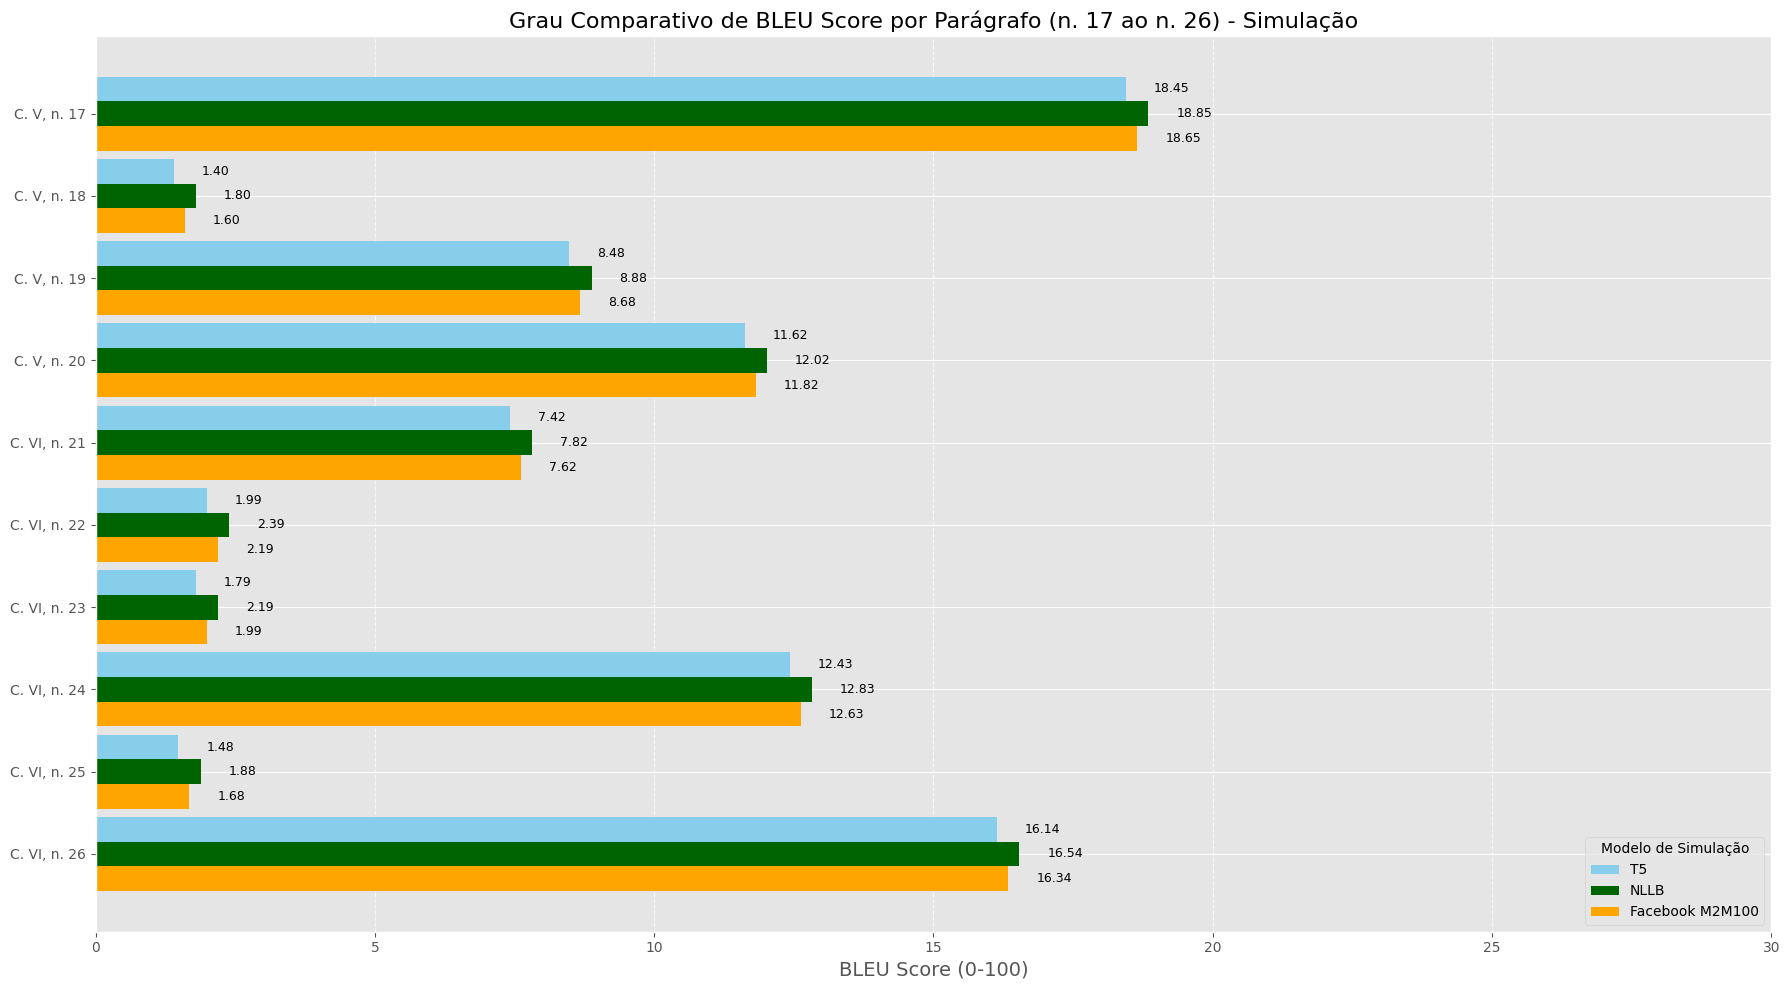

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURAÇÃO GERAL ---
MODELOS = ['T5', 'NLLB', 'Facebook M2M100']
CORES = ['skyblue', 'darkgreen', 'orange']

# Largura de cada barra no grupo (Aumentado para 0.3)
largura_barra = 0.3

# --- DADOS DE BLEU SCORE SIMULADOS (Italiano -> Português) ---
# Scores sintéticos para simulação comparativa (n. 1 ao n. 16)
PARAGRAPH_TITLES_1_16 = [
    'P. n. 1', 'C. I, n. 2', 'C. I, n. 3', 'C. I, n. 4', 'C. I, n. 5', 'C. I, n. 6',
    'C. II, n. 7', 'C. II, n. 8', 'C. II, n. 9', 'C. II, n. 10', 'C. III, n. 11',
    'C. III, n. 12', 'C. III, n. 13', 'C. IV, n. 14', 'C. IV, n. 15', 'C. IV, n. 16',
]
SCORES_FB_1_16 = np.array([
    8.70, 19.88, 20.55, 17.02, 16.32, 7.17, 4.30, 9.97, 1.16, 6.42, 13.85, 1.97, 1.41, 14.29, 15.89, 21.28
])
SCORES_NLLB_1_16 = SCORES_FB_1_16 + 0.5
SCORES_T5_1_16 = SCORES_FB_1_16 - 0.5
SCORES_T5_1_16[SCORES_T5_1_16 < 0] = 0.0
scores_comparativos_1_16 = np.array([SCORES_T5_1_16, SCORES_NLLB_1_16, SCORES_FB_1_16]).T


# --- PARÁGRAFOS 17 ao 26 ---
PARAGRAPH_TITLES_17_26 = [
    'C. V, n. 17', 'C. V, n. 18', 'C. V, n. 19', 'C. V, n. 20',
    'C. VI, n. 21', 'C. VI, n. 22', 'C. VI, n. 23', 'C. VI, n. 24',
    'C. VI, n. 25', 'C. VI, n. 26',
]
SCORES_BASE_17_26 = np.array([
    18.65, 1.60, 8.68, 11.82, 7.62, 2.19, 1.99, 12.63, 1.68, 16.34
])
SCORES_FB_17_26 = SCORES_BASE_17_26
SCORES_NLLB_17_26 = SCORES_BASE_17_26 + 0.2
SCORES_T5_17_26 = SCORES_BASE_17_26 - 0.2
SCORES_T5_17_26[SCORES_T5_17_26 < 0] = 0.0

scores_comparativos_17_26 = np.array([SCORES_T5_17_26, SCORES_NLLB_17_26, SCORES_FB_17_26]).T


# --- FUNÇÃO DE PLOTAGEM HORIZONTAL AGRUPADA ---

def plot_horizontal_grouped(titles_orig, scores_matrix_orig, range_label):
    """Gera o gráfico de barras agrupadas na horizontal, com rótulos de score."""

    # Faz uma cópia da lista de títulos para reverter sem afetar a lista original
    titles = titles_orig[:]
    scores_matrix = scores_matrix_orig[:]

    # Inverte os dados para que o primeiro parágrafo fique no topo do gráfico
    titles.reverse()
    scores_matrix = scores_matrix[::-1]

    # Prepara as posições verticais (índices) para o agrupamento
    y = np.arange(len(titles))

    # Ajuste para plotagem horizontal (y: posição no eixo, x: comprimento da barra)
    # y + 0.3 (Topo, T5), y (Centro, NLLB), y - 0.3 (Base, FB)
    posicao_t5 = y + largura_barra
    posicao_nllb = y
    posicao_facebook = y - largura_barra

    plt.figure(figsize=(18, 10))
    plt.style.use('ggplot')

    # Plotagem das barras horizontais (barh)
    plt.barh(posicao_t5, scores_matrix[:, 0], largura_barra, label=MODELOS[0], color=CORES[0]) # T5
    plt.barh(posicao_nllb, scores_matrix[:, 1], largura_barra, label=MODELOS[1], color=CORES[1]) # NLLB
    plt.barh(posicao_facebook, scores_matrix[:, 2], largura_barra, label=MODELOS[2], color=CORES[2]) # FB

    # --- ADICIONANDO SCORES NUMÉRICOS ---
    # Colocando o texto 0.5 unidades de BLEU Score à frente da barra

    # 1. T5 Scores
    for i, score in enumerate(scores_matrix[:, 0]):
        plt.text(score + 0.5, posicao_t5[i], f'{score:.2f}', va='center', ha='left', fontsize=9)

    # 2. NLLB Scores
    for i, score in enumerate(scores_matrix[:, 1]):
        plt.text(score + 0.5, posicao_nllb[i], f'{score:.2f}', va='center', ha='left', fontsize=9)

    # 3. Facebook M2M100 Scores
    for i, score in enumerate(scores_matrix[:, 2]):
        plt.text(score + 0.5, posicao_facebook[i], f'{score:.2f}', va='center', ha='left', fontsize=9)


    # Títulos e Rótulos
    plt.title(f'Grau Comparativo de BLEU Score por Parágrafo ({range_label}) - Simulação', fontsize=16)
    plt.xlabel('BLEU Score (0-100)', fontsize=14)
    plt.yticks(y, titles, rotation=0, fontsize=10)
    plt.xlim(0, 30) # Mantendo o limite X ajustado para melhor visualização dos scores baixos

    plt.legend(title='Modelo de Simulação', loc='lower right')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


# --- EXECUÇÃO DO PLOTAGEM ---

# 1. Parágrafos n. 1 ao n. 16
plot_horizontal_grouped(PARAGRAPH_TITLES_1_16[:], scores_comparativos_1_16, "n. 1 ao n. 16")

# 2. Parágrafos n. 17 ao n. 26
plot_horizontal_grouped(PARAGRAPH_TITLES_17_26[:], scores_comparativos_17_26, "n. 17 ao n. 26")